<a href="https://colab.research.google.com/github/AndikaPutra509/Prediksi-Saham/blob/main/Diversificated_Agresif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dependencies imported

🏦 IDX STOCK SCANNER - QUADRUPLE ENGINE (AGGRESSIVE ENHANCED) + BSJP
✅ Berhasil konek ke Google Sheets
✅ Membuka spreadsheet: IDX_Scanner_All_Engines

📊 Google Sheets URL: https://docs.google.com/spreadsheets/d/10ITzuSx_6512KrfSmkqaRPaAsFbPi6Z_NO-6e6u9BKg

Pilih Mode:
1. Phase 1 - Trading Scanner (Jalankan Semua Engine)
2. Phase 2 - Validation Suite (Monte Carlo Optimal)
3. Inisialisasi Data Warehouse (Download historis lengkap)
4. Walk-Forward Collection (Kumpulkan sinyal historis)
5. Exit

Pilihan (1/2/3/4/5): 2

📊 IDX STOCK SCANNER - PHASE 2 VALIDATION (AGGRESSIVE)
   Monte Carlo FIXED | Walk-Forward | Sensitivity | Risk 7%

📥 Loading data dari warehouse (637 saham tersedia)...

📊 Pilih jumlah saham untuk validasi:
   1. Semua (637 saham)
   2. Sample 200 saham
   3. Sample 100 saham
Pilihan (1/2/3): 1
   Loaded 50/637 - 50 valid
   Loaded 100/637 - 100 valid
   Loaded 150/637 - 150 valid
   Loaded 200/637 - 200 valid
   Loaded 250/637 - 250 valid
   Loaded 3

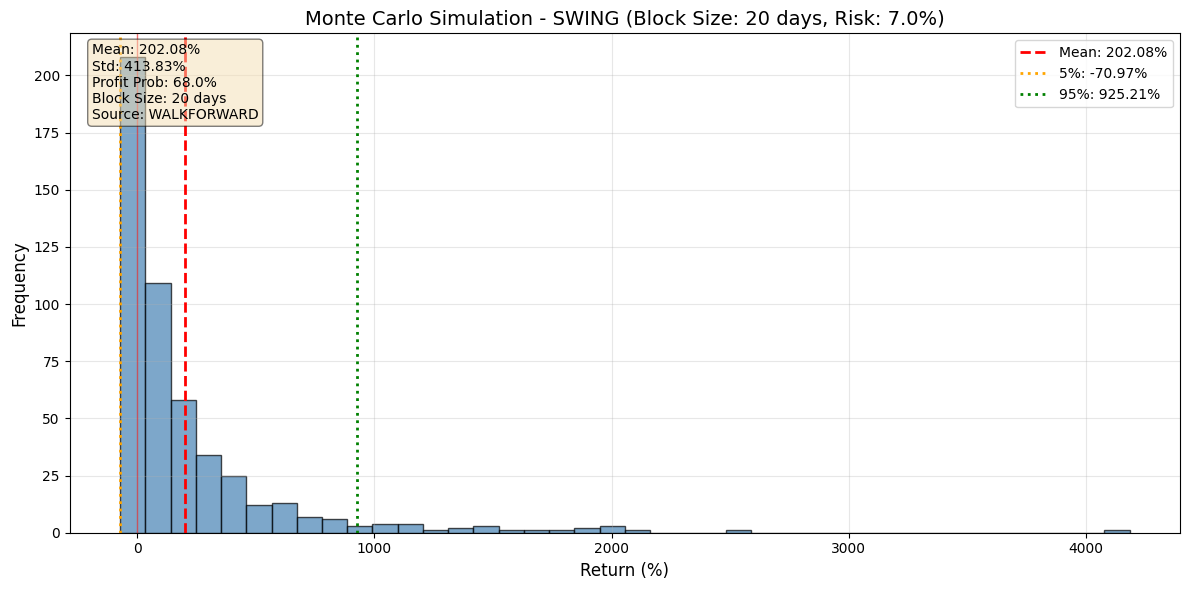

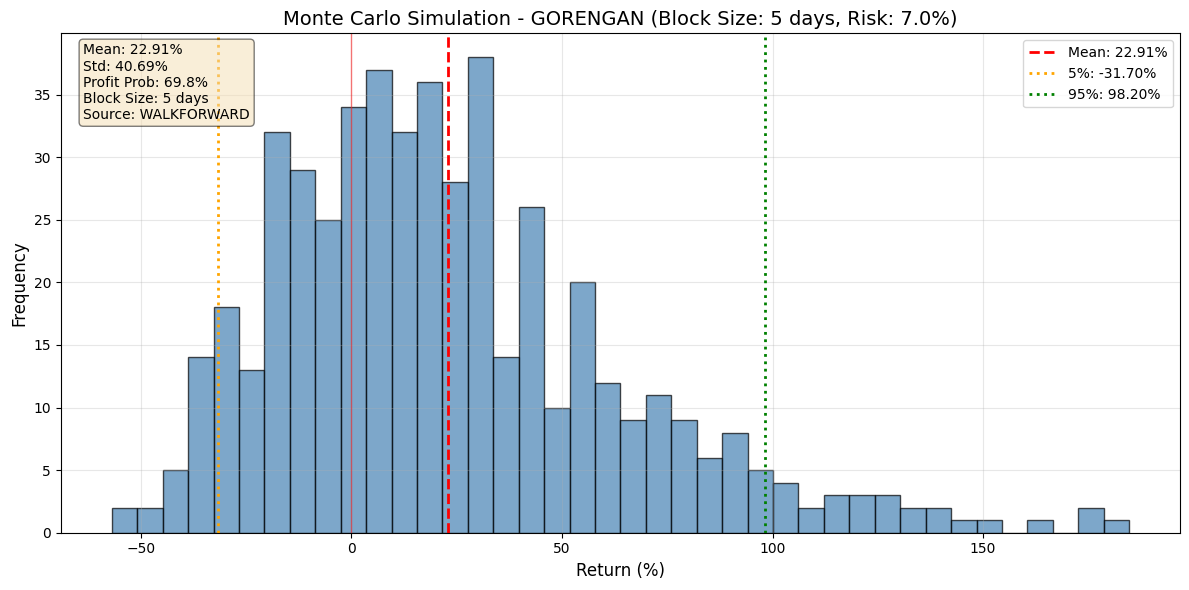

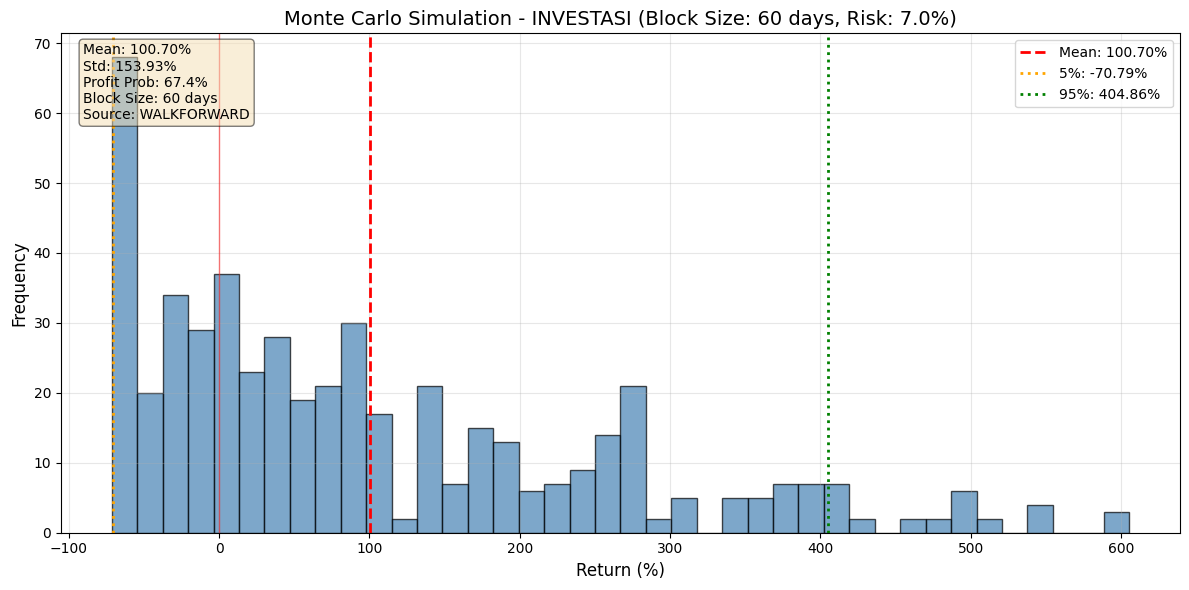

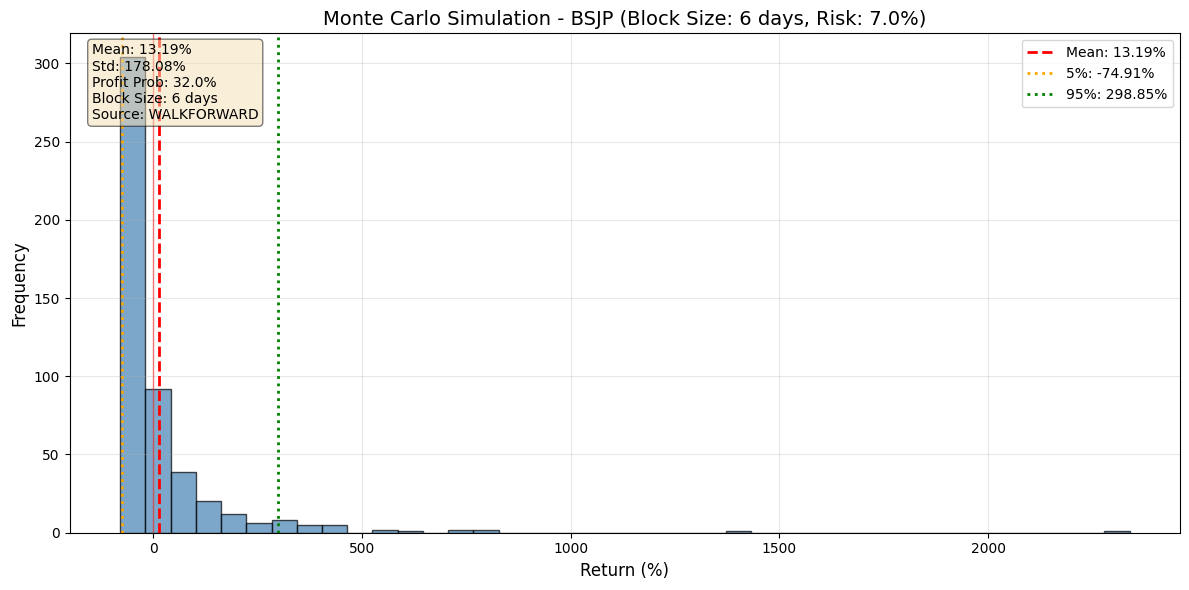

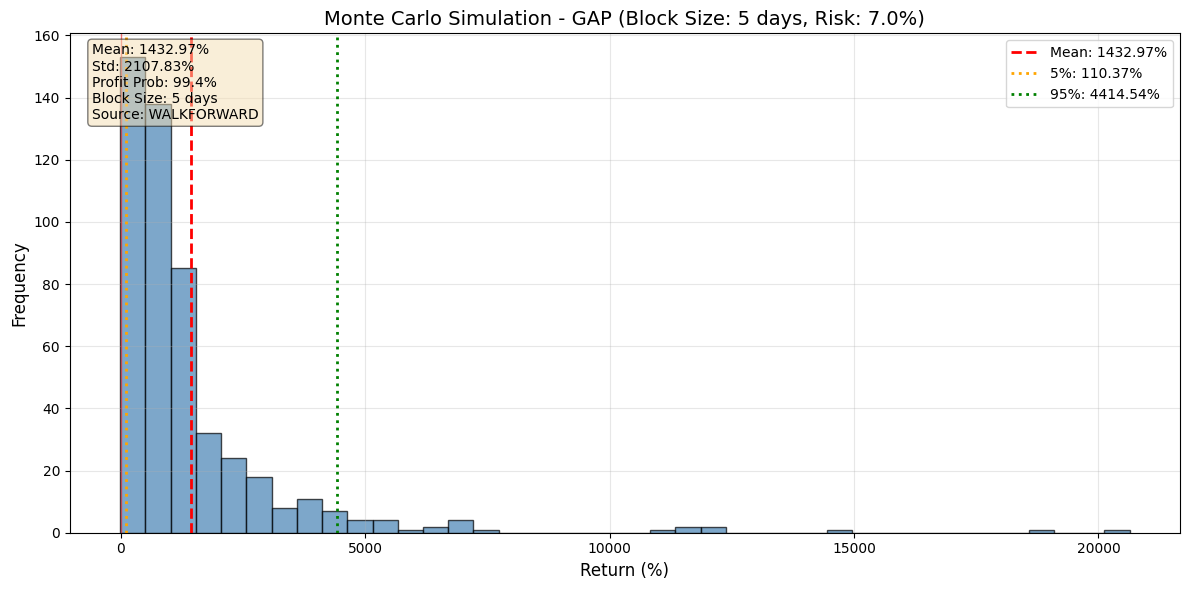

In [6]:
# -*- coding: utf-8 -*-
"""IDX Stock Scanner - Quintuple Engine (Agresif Enhanced + Composite Hybrid + Seasonality)
   Versi: Reliability & Monte Carlo Fix
"""

# =============================================================================
# 0. INSTALL LIBRARY TAMBAHAN
# =============================================================================
!pip install -q ta
!pip install -q mplfinance

# =============================================================================
# 1. DEPENDENCIES & IMPORTS
# =============================================================================

import mplfinance as mpf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import auth
from google.auth import default
import gspread
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import time
import pickle
import os
import json
from tabulate import tabulate
from collections import defaultdict
import logging
import random
from typing import Optional, Dict, List, Tuple, Union, Any
import hashlib
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.covariance import ledoit_wolf
from scipy.optimize import minimize
import statsmodels.api as sm
import glob
import math
import ta  # Technical Analysis Library

# Matikan logging yang tidak perlu
logging.getLogger('yfinance').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

# Setup logging untuk error handling
logging.basicConfig(
  filename='scanner_errors.log',
  level=logging.ERROR,
  format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✅ Dependencies imported")

# =============================================================================
# 2. STOCK UNIVERSE (FULL) - TIDAK BERUBAH
# =============================================================================

STOCKBIT_UNIVERSE = [
  "AALI", "ABBA", "ABDA", "ABMM", "ACES", "ADES", "ADHI", "ADMF", "ADMG", "ADRO",
  "AGAR", "AGII", "AGRO", "AHAP", "AIMS", "AISA", "AKRA", "AKSI", "ALDO", "ALKA",
  "ALMI", "AMAG", "AMFG", "AMMN", "AMRT", "ANDI", "ANJT", "ANTM", "APEX", "APIC",
  "APLN", "ARCI", "ARGO", "ARII", "ARNA", "ARTA", "ARTO", "ASBI", "ASDM", "ASGR",
  "ASHA", "ASII", "ASLI", "ASMI", "ASPI", "ASRI", "ASRM", "ASSA", "ATLA", "AUTO",
  "AVIA", "AWAN", "AYLS", "BABP", "BACA", "BALI", "BANK", "BAPA", "BAPI", "BATA",
  "BAYU", "BBCA", "BBHI", "BBKP", "BBLD", "BBNI", "BBRI", "BBRM", "BBSS", "BBTN",
  "BBYB", "BCAP", "BCIC", "BDMN", "BEEF", "BEKS", "BELL", "BEST", "BFIN", "BGTG",
  "BHAT", "BIMA", "BINA", "BIPP", "BIPI", "BIRD", "BISI", "BJBR", "BJTM", "BKSL",
  "BLTA", "BLUE", "BMAS", "BMBL", "BMRI", "BMSR", "BMTR", "BNBA", "BNBR", "BNGA",
  "BNII", "BNLI", "BOBA", "BOLT", "BOSS", "BPFI", "BPII", "BPTR", "BRAM", "BREN",
  "BRIS", "BRMS", "BRNA", "BRPT", "BSDE", "BSIM", "BSSR", "BTEL", "BTON", "BTPN",
  "BTPS", "BUDI", "BULL", "BUMI", "BUVA", "BWPT", "BYAN", "CAMP", "CANI", "CARS",
  "CASA", "CASS", "CBDK", "CBMF", "CCSI", "CDAX", "CEKA", "CENT", "CFIN", "CITA",
  "CITY", "CKRA", "CLEO", "CLPI", "CMNP", "CMPP", "CMRY", "CNKO", "CNTX", "COAL",
  "COCO", "COWL", "CPIN", "CPRO", "CSAP", "CSIS", "CTBN", "CTRA", "CTTH", "CUAN",
  "DAAZ", "DART", "DASA", "DAYA", "DCII", "DEGA", "DEWA", "DFAM", "DGIK", "DIGI",
  "DILD", "DIVA", "DIVN", "DKFT", "DLTA", "DMAS", "DMND", "DNAR", "DNET", "DNLS",
  "DOID", "DOOH", "DPNS", "DPUM", "DSFI", "DSNG", "DSSA", "DUCK", "DUTI", "DVLA",
  "DYAN", "EASI", "EASY", "EBMT", "ECII", "EDGE", "EKAD", "ELBA", "ELSA", "ELTY",
  "EMBR", "EMDE", "EMTK", "ENRG", "ENVY", "ENZO", "EPAC", "EPMT", "ERAA", "ERTX",
  "ESSA", "ESTA", "ESTI", "ETWA", "EXCL", "FAST", "FASW", "FILM", "FISH", "FITT",
  "FKSF", "FLMC", "FMII", "FORE", "FORU", "FORZ", "FPNI", "FREN", "FUJI", "FUTR",
  "GAMA", "GDST", "GDYR", "GEMS", "GGRM", "GGRP", "GHON", "GIDS", "GJTL", "GLVA",
  "GMFI", "GMTD", "GOLD", "GOOD", "GOTO", "GPRA", "GRPH", "GSMF", "GTBO", "GTRA",
  "GTSI", "GULA", "GZCO", "HADE", "HDFA", "HDIT", "HEAL", "HERO", "HITS", "HKMU",
  "HMSP", "HOKI", "HOMI", "HOPE", "HOTL", "HRME", "HRTA", "HRUM", "HSBK", "HSMP",
  "HUMI", "IBFN", "IBOS", "IBST", "ICBP", "ICON", "IDPR", "IFII", "IFSH", "IGAR",
  "IIKP", "IKAI", "IKAN", "IMAS", "IMJS", "IMPC", "INAF", "INAI", "INCF", "INCI",
  "INCO", "INDF", "INDS", "INDX", "INDY", "INET", "INKP", "INPC", "INPP", "INPS",
  "INRU", "INTA", "INTD", "INTP", "IPCC", "IPCM", "IPOL", "IRRA", "ISAT", "ISEA",
  "ISSP", "ITIC", "ITMG", "JAST", "JAWA", "JAYA", "JECC", "JEMB", "JFAS", "JGLE",
  "JHON", "JIHD", "JKON", "JKSW", "JMAS", "JPFA", "JPII", "JPUR", "JRPT", "JSKY",
  "JSMR", "JSPT", "JTNB", "KAEF", "KAQI", "KARW", "KBLI", "KBLM", "KBRT", "KBRI",
  "KDSI", "KDTN", "KEEN", "KETR", "KICI", "KIJA", "KINO", "KIOS", "KJEN", "KKGI",
  "KLBF", "KMTR", "KOBX", "KOIN", "KOLI", "KONI", "KOTA", "KPAL", "KPIG", "KRAS",
  "KREN", "KRYA", "KSEL", "KUAS", "KUIC", "KUVO", "LAND", "LAPD", "LATA", "LBAK",
  "LCGP", "LCKM", "LEAD", "LIFE", "LINK", "LION", "LISA", "LMAS", "LMPI", "LMSH",
  "LPCK", "LPGI", "LPIN", "LPKR", "LPLI", "LPPF", "LPPS", "LSIP", "LSPI", "LTLS",
  "LUCY", "MABA", "MABH", "MAGP", "MAIN", "MAMI", "MAPA", "MAPB", "MAPI", "MARA",
  "MASA", "MAYA", "MBAP", "MBCA", "MBMA", "MBSS", "MBTO", "MCAS", "MCPI", "MCOR",
  "MDIA", "MDKA", "MDKI", "MEDC", "MEDS", "MEGA", "MERK", "META", "MFIN", "MFMI",
  "MGLV", "MGNA", "MGRO", "MIDI", "MIKA", "MINA", "MIRA", "MITI", "MITT", "MKNT",
  "MKPI", "MLBI", "MLIA", "MLPL", "MLPT", "MLSL", "MMIX", "MMLP", "MNCN", "MOLI",
  "MPOW", "MPPA", "MPRO", "MPTJ", "MRAT", "MSIE", "MSIN", "MSKY", "MTDL", "MTFN",
  "MTLA", "MTPS", "MTSM", "MUDA", "MUTU", "MYOH", "MYOR", "MYRX", "MYSX", "NAGA",
  "NASI", "NATO", "NAYZ", "NCKL", "NELY", "NETV", "NFCX", "NICL", "NIKL", "NISP",
  "NITY", "NIYM", "NOBU", "NPGF", "NRCA", "NSSS", "NTBK", "NUSA", "NUSI", "OASA",
  "OCTN", "OKAS", "OMED", "ONIX", "OPMS", "ORNA", "OTBK", "PADA", "PADI", "PAMG",
  "PANR", "PANS", "PANU", "PAPA", "PASA", "PASS", "PBRX", "PBID", "PBSA", "PCAR",
  "PDES", "PDGD", "PDIN", "PEGE", "PGAS", "PGLI", "PGUN", "PICO", "PIDRA", "PJAA",
  "PKPK", "PLAN", "PLAS", "PLIN", "PMJS", "PMMP", "PNBN", "PNBS", "PNIN", "PNLF",
  "PNSE", "POLI", "POLL", "POLU", "POLY", "POOL", "PORT", "POWR", "PPGL", "PPRE",
  "PPRO", "PPSI", "PRAS", "PRDA", "PRIM", "PRIN", "PRLD", "PROD", "PROT", "PRTS",
  "PSAB", "PSBA", "PSDN", "PSGO", "PSKT", "PSSI", "PTBA", "PTDU", "PTIS", "PTMP",
  "PTPP", "PTPW", "PTRO", "PTSN", "PTSP", "PUDP", "PURA", "PURE", "PWON", "PYFA",
  "RACE", "RADIO", "RAFI", "RAJA", "RAKD", "RALS", "RANC", "RATU", "RBMS", "RDTX",
  "REAL", "RELI", "RIGS", "RIMO", "RISE", "RMBA", "RMKE", "ROCK", "RODA", "ROKI",
  "ROTI", "RRMI", "RUIS", "RUMI", "SABA", "SAFE", "SAME", "SAPX", "SARA", "SATO",
  "SBAT", "SBBP", "SBGA", "SBMA", "SBMF", "SCBD", "SCCC", "SCCO", "SCMA", "SCNP",
  "SDPC", "SDRA", "SEAN", "SECR", "SEMA", "SFAN", "SGER", "SGRO", "SHID", "SHIP",
  "SIDO", "SILO", "SIMA", "SIMP", "SIPD", "SIPO", "SKBM", "SKLT", "SKRN", "SLIS",
  "SMAR", "SMDR", "SMGR", "SMIL", "SMMT", "SMSM", "SMRA", "SNLK", "SNMS", "SOFA",
  "SONA", "SOSS", "SOUL", "SPMA", "SPMI", "SPNA", "SPRE", "SPTO", "SQBI", "SQMI",
  "SRAJ", "SRIL", "SRSN", "SSIA", "SSMS", "SSTM", "STAR", "STTP", "SUGI", "SULI",
  "SUPR", "SURI", "SWAT", "SWID", "TALD", "TAMA", "TAMU", "TAPG", "TARA", "TASP",
  "TATA", "TAXI", "TBIG", "TBLA", "TCID", "TDPM", "TELE", "TEMB", "TEMPO", "TIFA",
  "TIGA", "TINS", "TIRA", "TIRT", "TITA", "TKGA", "TKIM", "TLKM", "TMAS", "TMPO",
  "TMSH", "TOBA", "TOOL", "TOPS", "TOSK", "TOTL", "TOTO", "TOWR", "TPIA", "TPMA",
  "TRAM", "TRGU", "TRIO", "TRIS", "TRJA", "TRON", "TRST", "TRUB", "TRUK", "TRUS",
  "TSPC", "TUGU", "TURI", "TUVN", "TYRE", "UANG", "UCID", "UDIJ", "UFNX", "UGRO",
  "UJSN", "ULTJ", "UNIC", "UNIQ", "UNIT", "UNSP", "USFI", "VALU", "VICO", "VICI",
  "VIDI", "VISI", "VIVA", "VKTR", "VOKS", "VRNA", "VTNY", "WAPO", "WEGE", "WEHA",
  "WICO", "WIFI", "WIIM", "WINS", "WMUU", "WMPP", "WOOD", "WOWS", "WRKR", "WSBP",
  "WSKT", "WTON", "YELO", "YULE", "ZBRA", "ZINC", "ZONE"
]

# =============================================================================
# 3. QUALITY STOCKS UNIVERSE (IDX30 + LQ45 + IDX80) - TIDAK BERUBAH
# =============================================================================

QUALITY_STOCKS = [
  'ADRO', 'AMRT', 'ANTM', 'ASII', 'BBCA', 'BBNI', 'BBRI', 'BMRI', 'BREN', 'BUMI',
  'CPIN', 'EMTK', 'GOTO', 'ICBP', 'INCO', 'INDF', 'INKP', 'ISAT', 'JPFA', 'JSMR',
  'KLBF', 'MDKA', 'MEDC', 'MIKA', 'MTEL', 'NCKL', 'PGAS', 'TLKM', 'TOWR', 'UNTR',
  'AKRA', 'ARTO', 'BBTN', 'BDKR', 'BIRD', 'BJBR', 'BJTM', 'BRIS', 'BRPT', 'BUKA',
  'EXCL', 'HRUM', 'INTP', 'ITMG', 'MPMX', 'PTBA', 'SIDO', 'SMGR', 'TPIA', 'UNVR',
  'WIKA', 'ACES', 'ADHI', 'AGRO', 'AALI', 'ARNA', 'ASGR', 'ASRI', 'AUTO', 'BAYU',
  'BEST', 'BFIN', 'BIPP', 'BISI', 'BKSL', 'BLTA', 'BMAS', 'BMSR', 'BNGA', 'BNII',
  'BOBA', 'BOLT', 'BOSS', 'BPFI', 'BRAM', 'BSDE', 'BSSR', 'BTON', 'BUDI', 'BULL',
  'BUVA', 'BWPT', 'BYAN', 'CAMP', 'CANI', 'CARS', 'CASA', 'CASS', 'CBDK', 'CBMF',
  'CCSI', 'CDAX', 'CEKA', 'CENT', 'CFIN', 'CITA', 'CITY', 'CKRA', 'CLEO', 'CLPI',
  'CMNP', 'CMPP', 'CMRY', 'CNKO', 'COAL', 'COCO', 'COWL', 'CPRO', 'CSAP', 'CSIS',
  'CTBN', 'CTRA', 'CTTH', 'CUAN', 'DART', 'DASA', 'DCII', 'DEGA', 'DEWA', 'DGIK',
  'DIGI', 'DILD', 'DIVA', 'DIVN', 'DLTA', 'DMAS', 'DMND', 'DNAR', 'DNET', 'DNLS',
  'DOID', 'DOOH', 'DPNS', 'DSFI', 'DSNG', 'DSSA', 'DUCK', 'DUTI', 'DVLA', 'DYAN',
  'EASI', 'EASY', 'EBMT', 'ECII', 'EDGE', 'EKAD', 'ELBA', 'ELSA', 'ELTY', 'EMBR',
  'EMDE', 'EMTK', 'ENRG', 'ENVY', 'ENZO', 'EPAC', 'EPMT', 'ERAA', 'ESSA', 'ESTA',
  'ESTI', 'ETWA', 'EXCL', 'FAST', 'FASW', 'FILM', 'FISH', 'FITT', 'FKSF', 'FLMC',
  'FMII', 'FORE', 'FORU', 'FORZ', 'FPNI', 'FREN', 'FUJI', 'FUTR', 'GAMA', 'GDST',
  'GDYR', 'GEMS', 'GGRM', 'GGRP', 'GHON', 'GIDS', 'GJTL', 'GLVA', 'GMFI', 'GMTD',
  'GOLD', 'GOOD', 'GPRA', 'GRPH', 'GSMF', 'GTBO', 'GTRA', 'GTSI', 'GULA', 'HADE',
  'HDFA', 'HDIT', 'HEAL', 'HERO', 'HITS', 'HKMU', 'HMSP', 'HOKI', 'HOMI', 'HOPE',
  'HOTL', 'HRME', 'HRTA', 'HRUM', 'HSBK', 'HSMP', 'HUMI', 'IBFN', 'IBOS', 'IBST',
  'ICON', 'IDPR', 'IFII', 'IFSH', 'IGAR', 'IIKP', 'IKAI', 'IKAN', 'IMAS', 'IMJS',
  'IMPC', 'INAF', 'INAI', 'INCF', 'INCI', 'INDS', 'INDX', 'INDY', 'INET', 'INKP',
  'INPC', 'INPP', 'INPS', 'INRU', 'INTA', 'INTD', 'INTP', 'IPCC', 'IPCM', 'IPOL',
  'IRRA', 'ISEA', 'ISSP', 'ITIC', 'JAST', 'JAWA', 'JAYA', 'JECC', 'JEMB', 'JFAS',
  'JGLE', 'JHON', 'JIHD', 'JKON', 'JKSW', 'JMAS', 'JPII', 'JPUR', 'JRPT', 'JSKY',
  'JSPT', 'JTNB', 'KAEF', 'KAQI', 'KARW', 'KBLI', 'KBLM', 'KBRT', 'KBRI', 'KDSI',
  'KDTN', 'KEEN', 'KETR', 'KICI', 'KIJA', 'KINO', 'KIOS', 'KJEN', 'KKGI', 'KMTR',
  'KOBX', 'KOIN', 'KOLI', 'KONI', 'KOTA', 'KPAL', 'KPIG', 'KRAS', 'KREN', 'KRYA',
  'KSEL', 'KUAS', 'KUIC', 'KUVO', 'LAND', 'LAPD', 'LATA', 'LBAK', 'LCGP', 'LCKM',
  'LEAD', 'LIFE', 'LINK', 'LION', 'LISA', 'LMAS', 'LMPI', 'LMSH', 'LPCK', 'LPGI',
  'LPIN', 'LPKR', 'LPLI', 'LPPF', 'LPPS', 'LSIP', 'LSPI', 'LTLS', 'LUCY', 'MABA',
  'MABH', 'MAGP', 'MAIN', 'MAMI', 'MAPA', 'MAPB', 'MAPI', 'MARA', 'MASA', 'MAYA',
  'MBAP', 'MBCA', 'MBMA', 'MBSS', 'MBTO', 'MCAS', 'MCPI', 'MCOR', 'MDIA', 'MDKA',
  'MDKI', 'MEDC', 'MEDS', 'MEGA', 'MERK', 'META', 'MFIN', 'MFMI', 'MGLV', 'MGNA',
  'MGRO', 'MIDI', 'MIKA', 'MINA', 'MIRA', 'MITI', 'MITT', 'MKNT', 'MKPI', 'MLBI',
  'MLIA', 'MLPL', 'MLPT', 'MLSL', 'MMIX', 'MMLP', 'MNCN', 'MOLI', 'MPOW', 'MPPA',
  'MPRO', 'MPTJ', 'MRAT', 'MSIE', 'MSIN', 'MSKY', 'MTDL', 'MTFN', 'MTLA', 'MTPS',
  'MTSM', 'MUDA', 'MUTU', 'MYOH', 'MYOR', 'MYRX', 'MYSX', 'NAGA', 'NASI', 'NATO',
  'NAYZ', 'NCKL', 'NELY', 'NETV', 'NFCX', 'NICL', 'NIKL', 'NISP', 'NITY', 'NIYM',
  'NOBU', 'NPGF', 'NRCA', 'NSSS', 'NTBK', 'NUSA', 'NUSI', 'OASA', 'OCTN', 'OKAS',
  'OMED', 'ONIX', 'OPMS', 'ORNA', 'OTBK', 'PADA', 'PADI', 'PAMG', 'PANR', 'PANS',
  'PANU', 'PAPA', 'PASA', 'PASS', 'PBRX', 'PBID', 'PBSA', 'PCAR', 'PDES', 'PDGD',
  'PDIN', 'PEGE', 'PGAS', 'PGLI', 'PGUN', 'PICO', 'PIDRA', 'PJAA', 'PKPK', 'PLAN',
  'PLAS', 'PLIN', 'PMJS', 'PMMP', 'PNBN', 'PNBS', 'PNIN', 'PNLF', 'PNSE', 'POLI',
  'POLL', 'POLU', 'POLY', 'POOL', 'PORT', 'POWR', 'PPGL', 'PPRE', 'PPRO', 'PPSI',
  'PRAS', 'PRDA', 'PRIM', 'PRIN', 'PRLD', 'PROD', 'PROT', 'PRTS', 'PSAB', 'PSBA',
  'PSDN', 'PSGO', 'PSKT', 'PSSI', 'PTDU', 'PTIS', 'PTMP', 'PTPP', 'PTPW', 'PTRO',
  'PTSN', 'PTSP', 'PUDP', 'PURA', 'PURE', 'PWON', 'PYFA', 'RACE', 'RADIO', 'RAFI',
  'RAJA', 'RAKD', 'RALS', 'RANC', 'RATU', 'RBMS', 'RDTX', 'REAL', 'RELI', 'RIGS',
  'RIMO', 'RISE', 'RMBA', 'RMKE', 'ROCK', 'RODA', 'ROKI', 'ROTI', 'RRMI', 'RUIS',
  'RUMI', 'SABA', 'SAFE', 'SAME', 'SAPX', 'SARA', 'SATO', 'SBAT', 'SBBP', 'SBGA',
  'SBMA', 'SBMF', 'SCBD', 'SCCC', 'SCCO', 'SCMA', 'SCNP', 'SDPC', 'SDRA', 'SEAN',
  'SECR', 'SEMA', 'SFAN', 'SGER', 'SGRO', 'SHID', 'SHIP', 'SIDO', 'SILO', 'SIMA',
  'SIMP', 'SIPD', 'SIPO', 'SKBM', 'SKLT', 'SKRN', 'SLIS', 'SMAR', 'SMDR', 'SMGR',
  'SMIL', 'SMMT', 'SMSM', 'SMRA', 'SNLK', 'SNMS', 'SOFA', 'SONA', 'SOSS', 'SOUL',
  'SPMA', 'SPMI', 'SPNA', 'SPRE', 'SPTO', 'SQBI', 'SQMI', 'SRAJ', 'SRIL', 'SRSN',
  'SSIA', 'SSMS', 'SSTM', 'STAR', 'STTP', 'SUGI', 'SULI', 'SUPR', 'SURI', 'SWAT',
  'SWID', 'TALD', 'TAMA', 'TAMU', 'TAPG', 'TARA', 'TASP', 'TATA', 'TAXI', 'TBIG',
  'TBLA', 'TCID', 'TDPM', 'TELE', 'TEMB', 'TEMPO', 'TIFA', 'TIGA', 'TINS', 'TIRA',
  'TIRT', 'TITA', 'TKGA', 'TKIM', 'TLKM', 'TMAS', 'TMPO', 'TMSH', 'TOBA', 'TOOL',
  'TOPS', 'TOSK', 'TOTL', 'TOTO', 'TOWR', 'TPIA', 'TPMA', 'TRAM', 'TRGU', 'TRIO',
  'TRIS', 'TRJA', 'TRON', 'TRST', 'TRUB', 'TRUK', 'TRUS', 'TSPC', 'TUGU', 'TURI',
  'TUVN', 'TYRE', 'UANG', 'UCID', 'UDIJ', 'UFNX', 'UGRO', 'UJSN', 'ULTJ', 'UNIC',
  'UNIQ', 'UNIT', 'UNSP', 'USFI', 'VALU', 'VICO', 'VICI', 'VIDI', 'VISI', 'VIVA',
  'VKTR', 'VOKS', 'VRNA', 'VTNY', 'WAPO', 'WEGE', 'WEHA', 'WICO', 'WIFI', 'WIIM',
  'WINS', 'WMUU', 'WMPP', 'WOOD', 'WOWS', 'WRKR', 'WSBP', 'WSKT', 'WTON', 'YELO',
  'YULE', 'ZBRA', 'ZINC', 'ZONE'
]
QUALITY_STOCKS = list(dict.fromkeys(QUALITY_STOCKS))

# =============================================================================
# 4. SECTOR MAPPING - TIDAK BERUBAH
# =============================================================================

ENERGY_SECTOR = ['ADRO', 'PTBA', 'ITMG', 'MEDC', 'PGAS', 'ENRG', 'BUMI', 'DOID']
MINING_GOLD = ['ANTM', 'MDKA', 'BRMS']
EXPORT_SECTOR = ['ANTM', 'INCO', 'TINS', 'HRUM', 'CPIN', 'JPFA', 'MAIN']

SECTOR_MAPPING = {
  'ENERGY': ENERGY_SECTOR + ['BYAN', 'INDY', 'HRUM', 'ARTI'],
  'MINING': MINING_GOLD + ['INCO', 'TINS', 'CITA', 'DKFT'],
  'FINANCE': ['BBCA', 'BBRI', 'BMRI', 'BBNI', 'PNBN', 'BJBR', 'BJTM', 'NISP', 'BDMN', 'BNLI', 'BNGA', 'BNII', 'BSIM'],
  'PROPERTY': ['PWON', 'BSDE', 'LPKR', 'CTRA', 'SMRA', 'ASRI', 'DILD', 'MDLN', 'ELTY', 'BIPP', 'BKSL', 'MTLA', 'MAPI'],
  'CONSUMER': ['UNVR', 'ICBP', 'INDF', 'GGRM', 'HMSP', 'KLBF', 'MYOR', 'SIDO', 'ULTJ', 'DLTA', 'MLBI', 'TCID', 'ROTI', 'SKBM'],
  'INFRASTRUCTURE': ['TLKM', 'JSMR', 'TOWR', 'TBIG', 'WIKA', 'PTPP', 'WSKT', 'ADHI', 'TOTL', 'ACST'],
  'INDUSTRIAL': ['ASII', 'GJTL', 'AUTO', 'BRAM', 'INDS', 'BOLT', 'IMP', 'PRAS', 'PBRX'],
  'TRADE': ['MAPI', 'ACES', 'RALS', 'LPPF', 'ERAA', 'MAPB', 'SONA', 'CSAP', 'MIDI', 'MFMI'],
  'AGRICULTURE': ['AALI', 'LSIP', 'SGRO', 'BWPT', 'SMAR', 'DSNG', 'JAWA'],
  'HEALTHCARE': ['MIKA', 'SILO', 'KLBF', 'KAEF', 'INAF', 'DVLA', 'TSPC', 'MERK', 'SCPI']
}

def get_sector(symbol: str) -> str:
  """Get sector for a symbol"""
  for sector, stocks in SECTOR_MAPPING.items():
      if symbol in stocks:
          return sector
  return 'OTHER'

# =============================================================================
# 5. GLOBAL INDICES CONFIGURATION - DIPERBARUI (TAMBAHAN NIKKEI & SHANGHAI)
# =============================================================================

GLOBAL_INDICES = {
  "IHSG": {
      "ticker": "^JKSE",
      "nama": "Indeks Harga Saham Gabungan",
      "satuan": "poin",
      "keterangan": "Indeks utama BEI"
  },
  "DOWJONES": {
      "ticker": "^DJI",
      "nama": "Dow Jones Industrial Average",
      "satuan": "poin",
      "keterangan": "Indeks saham AS"
  },
  "USDIDR": {
      "ticker": "IDR=X",
      "nama": "USD/IDR",
      "satuan": "Rp/USD",
      "keterangan": "Nilai tukar Rupiah terhadap Dolar"
  },
  "OIL": {
      "ticker": "CL=F",
      "nama": "Crude Oil WTI",
      "satuan": "USD/barel",
      "keterangan": "Harga minyak dunia"
  },
  "GOLD": {
      "ticker": "GC=F",
      "nama": "Gold Futures",
      "satuan": "USD/ons",
      "keterangan": "Harga emas dunia"
  },
  "NIKKEI": {
      "ticker": "^N225",
      "nama": "Nikkei 225",
      "satuan": "poin",
      "keterangan": "Indeks saham Jepang"
  },
  "SHANGHAI": {
      "ticker": "000001.SS",
      "nama": "Shanghai Composite Index",
      "satuan": "poin",
      "keterangan": "Indeks saham China"
  }
}

# =============================================================================
# 6. GLOBAL INDICES FETCHER (LENGKAP) - VERSI FIX UNTUK OIL/GOLD
# =============================================================================

class GlobalIndicesFetcher:
  """Fetch global indices data for market context - DENGAN FIX UNTUK OIL/GOLD"""

  def __init__(self):
      self.data = {}
      self.momentum = {}
      self.status = {}
      self.prices = {}
      self.detail = {}
      self.seasonality = None  # akan diisi nanti

  def fetch_all(self) -> None:
      print("\n" + "="*80)
      print("📡 FETCHING GLOBAL INDICES - DETAIL TRANSPARAN")
      print("="*80)

      end_date = datetime.now()
      start_date = end_date - timedelta(days=365*2)

      for name, config in GLOBAL_INDICES.items():
          ticker = config["ticker"]
          print(f"\n📊 {name}: {config['nama']}")
          print(f"   Ticker: {ticker}")
          print(f"   Satuan: {config['satuan']}")
          print(f"   Keterangan: {config['keterangan']}")

          try:
              df = yf.download(
                  ticker,
                  start=start_date.strftime("%Y-%m-%d"),
                  end=end_date.strftime("%Y-%m-%d"),
                  interval="1d",
                  auto_adjust=True,
                  progress=False,
                  timeout=10
              )

              time.sleep(0.5)

              if df.empty or len(df) < 200:
                  self.status[name] = "UNAVAILABLE"
                  self.momentum[name] = 0.0
                  self.prices[name] = 0.0
                  print(f"   ⚠️  Status: TIDAK TERSEDIA (data tidak cukup)")
              else:
                  # Normalize columns
                  if isinstance(df.columns, pd.MultiIndex):
                      df.columns = df.columns.get_level_values(0)

                  # FIX UNTUK OIL & GOLD: handle NaN
                  if name in ["OIL", "GOLD"]:
                      close_col = None
                      for col in ['Close', 'Adj Close']:
                          if col in df.columns and not df[col].isna().all():
                              close_col = col
                              break
                      if close_col is None:
                          for col in df.columns:
                              if pd.api.types.is_numeric_dtype(df[col]) and not df[col].isna().all():
                                  close_col = col
                                  break
                      if close_col:
                          close = df[close_col].values
                          close = close[~np.isnan(close)]
                      else:
                          close = np.array([])
                  else:
                      close = df['Close'].values

                  if len(close) == 0:
                      self.status[name] = "UNAVAILABLE"
                      self.momentum[name] = 0.0
                      self.prices[name] = 0.0
                      print(f"   ⚠️  Status: TIDAK TERSEDIA (data tidak valid)")
                      continue

                  current_price = float(close[-1])
                  price_1w_ago = float(close[-6]) if len(close) >= 6 else current_price
                  price_1m_ago = float(close[-22]) if len(close) >= 22 else current_price
                  price_3m_ago = float(close[-66]) if len(close) >= 66 else current_price
                  price_1y_ago = float(close[-252]) if len(close) >= 252 else current_price

                  momentum_1w = (current_price / price_1w_ago - 1) * 100 if price_1w_ago > 0 else 0
                  momentum_1m = (current_price / price_1m_ago - 1) * 100 if price_1m_ago > 0 else 0
                  momentum_3m = (current_price / price_3m_ago - 1) * 100 if price_3m_ago > 0 else 0
                  momentum_1y = (current_price / price_1y_ago - 1) * 100 if price_1y_ago > 0 else 0

                  if name == "IHSG" and len(close) >= 200:
                      ma50 = np.mean(close[-50:])
                      ma200 = np.mean(close[-200:])
                      self.data['IHSG_MA50'] = ma50
                      self.data['IHSG_MA200'] = ma200
                      self.data['IHSG_Close'] = current_price

                      if current_price > ma50 > ma200:
                          trend = "BULLISH (di atas MA50 & MA200)"
                      elif current_price < ma50 < ma200:
                          trend = "BEARISH (di bawah MA50 & MA200)"
                      elif current_price > ma50:
                          trend = "NETRAL (di atas MA50, di bawah MA200)"
                      else:
                          trend = "NETRAL (di bawah MA50, di atas MA200)"

                      returns = pd.Series(close).pct_change().dropna() * 100
                      volatility = returns.tail(20).std() * np.sqrt(252) if len(returns) > 20 else 20.0
                  else:
                      trend = "TIDAK TERSEDIA"
                      volatility = 20.0

                  self.detail[name] = {
                      'current_price': current_price,
                      'price_1w_ago': price_1w_ago,
                      'price_1m_ago': price_1m_ago,
                      'price_3m_ago': price_3m_ago,
                      'price_1y_ago': price_1y_ago,
                      'momentum_1w': round(momentum_1w, 2),
                      'momentum_1m': round(momentum_1m, 2),
                      'momentum_3m': round(momentum_3m, 2),
                      'momentum_1y': round(momentum_1y, 2),
                      'trend': trend,
                      'volatility': round(volatility, 2),
                      'data_length': len(df)
                  }

                  self.data[name] = df
                  self.momentum[name] = round(momentum_1m, 2)
                  self.prices[name] = round(current_price, 2)
                  self.status[name] = "OK"

                  print(f"   ✅ Status: TERSEDIA")
                  print(f"   Harga Saat Ini: {self.get_price_str(name)}")
                  print(f"   Momentum 1w: {momentum_1w:+.2f}%")
                  print(f"   Momentum 1m: {momentum_1m:+.2f}%")
                  print(f"   Momentum 3m: {momentum_3m:+.2f}%")
                  print(f"   Momentum 1y: {momentum_1y:+.2f}%")
                  if name == "IHSG":
                      print(f"   MA50: {ma50:,.2f}")
                      print(f"   MA200: {ma200:,.2f}")
                      print(f"   Trend: {trend}")
                      print(f"   Volatility (annualized): {volatility:.1f}%")

          except Exception as e:
              self.status[name] = "ERROR"
              self.momentum[name] = 0.0
              self.prices[name] = 0.0
              logger.error(f"Error fetching {name}: {str(e)}")
              print(f"   ❌ Status: ERROR - {str(e)[:50]}")
              time.sleep(0.5)

      print("\n" + "="*80)
      print("✅ SEMUA INDEKS GLOBAL SELESAI DI-FETCH")
      print("="*80)

  def print_detailed_report(self) -> None:
      if not self.detail:
          print("\n📊 Tidak ada data indeks untuk ditampilkan")
          return

      print("\n" + "="*100)
      print("📊 LAPORAN DETAIL INDEKS GLOBAL")
      print("="*100)

      data = []
      for name, detail in self.detail.items():
          data.append([
              name,
              self.get_price_str(name),
              f"{detail['momentum_1w']:+.2f}%",
              f"{detail['momentum_1m']:+.2f}%",
              f"{detail['momentum_3m']:+.2f}%",
              f"{detail['momentum_1y']:+.2f}%",
              detail.get('trend', 'N/A'),
              detail.get('volatility', 'N/A'),
              self.status[name]
          ])

      headers = ["Indeks", "Harga", "1W", "1M", "3M", "1Y", "Trend", "Vol%", "Status"]
      print(tabulate(data, headers=headers, tablefmt='grid'))

  def get_price_str(self, name: str) -> str:
      price = self.prices.get(name, 0)
      if price == 0:
          return "N/A"
      if name in ["IHSG", "DOWJONES", "NIKKEI", "SHANGHAI"]:
          return f"{price:,.2f}"
      elif name == "USDIDR":
          return f"Rp {price:,.0f}"
      elif name == "OIL":
          return f"US$ {price:.2f}"
      elif name == "GOLD":
          return f"US$ {price:.2f}"
      return f"{price:.2f}"

  def get_trend(self, name: str) -> str:
      mom = self.momentum.get(name, 0)
      if mom > 0.5:
          return "🟢 BULLISH"
      elif mom < -0.5:
          return "🔴 BEARISH"
      else:
          return "🟡 NETRAL"

  def get_momentum(self, name: str) -> float:
      return self.momentum.get(name, 0.0)

  def get_price(self, name: str) -> float:
      return self.prices.get(name, 0.0)

  def is_ihsg_bullish(self) -> bool:
      if 'IHSG_Close' in self.data and 'IHSG_MA200' in self.data:
          return self.data['IHSG_Close'] > self.data['IHSG_MA200']
      return True

# =============================================================================
# 6A. SEASONALITY CALENDAR
# =============================================================================
class SeasonalityCalendar:
  """
  Menghitung multiplier musiman berdasarkan data IHSG historis.
  Hanya menggunakan data hingga tahun lalu untuk menghindari lookahead.
  """
  def __init__(self, ihsg_data: pd.DataFrame):
      self.ihsg_data = ihsg_data.copy()
      self.monthly_prob = {}
      self._precompute()

  def _precompute(self):
      """Hitung probabilitas return positif per bulan menggunakan data hingga tahun lalu."""
      last_year = datetime.now().year - 1
      data_up_to_last_year = self.ihsg_data[self.ihsg_data.index.year <= last_year].copy()
      if len(data_up_to_last_year) < 60:
          # fallback ke seluruh data jika kurang
          data_up_to_last_year = self.ihsg_data

      returns = data_up_to_last_year['Close'].pct_change().dropna() * 100
      monthly_returns = returns.groupby(returns.index.month)
      for month, rets in monthly_returns:
          pos_count = (rets > 0).sum()
          total = len(rets)
          prob = pos_count / total if total > 0 else 0.5
          # mapping prob ke multiplier 0.9-1.1 (prob 0.3 -> 0.9, prob 0.7 -> 1.1)
          mult = 0.9 + (prob - 0.3) * (0.2 / 0.4)
          mult = max(0.9, min(1.1, mult))
          self.monthly_prob[month] = mult

  def get_multiplier(self, date: datetime) -> float:
      """Mengembalikan multiplier berdasarkan bulan tanggal tsb."""
      month = date.month
      return self.monthly_prob.get(month, 1.0)

# =============================================================================
# 6B. MARKET REGIME DETECTOR (TANPA NEWS)
# =============================================================================

class MarketRegimeDetector:
  def __init__(self, lookback_days: int = 252):
      self.lookback_days = lookback_days
      self.current_regime = "UNKNOWN"
      self.confidence = 0.0
      self.regime_params = {}
      self.regime_history = []

  def detect_regime(self, ihsg_data: pd.DataFrame) -> Tuple[str, float]:
      if ihsg_data is None or len(ihsg_data) < 200:
          return "UNKNOWN", 0.0

      df = ihsg_data.shift(1).copy()
      close = df['Close'].dropna()

      if len(close) < 200:
          return "UNKNOWN", 0.0

      returns = close.pct_change().dropna() * 100

      mom_20d = (close.iloc[-1] / close.iloc[-21] - 1) * 100 if len(close) > 21 else 0
      mom_60d = (close.iloc[-1] / close.iloc[-61] - 1) * 100 if len(close) > 61 else 0

      vol_20d = returns.tail(20).std() * np.sqrt(252)
      vol_60d = returns.tail(60).std() * np.sqrt(252)
      hist_vol = returns.tail(252).std() * np.sqrt(252) if len(returns) > 252 else 20

      ma50 = close.rolling(50).mean()
      ma200 = close.rolling(200).mean()

      price_vs_ma50 = (close.iloc[-1] / ma50.iloc[-1] - 1) * 100 if not pd.isna(ma50.iloc[-1]) else 0
      price_vs_ma200 = (close.iloc[-1] / ma200.iloc[-1] - 1) * 100 if not pd.isna(ma200.iloc[-1]) else 0

      high = df['High']
      low = df['Low']

      tr1 = high - low
      tr2 = (high - close.shift()).abs()
      tr3 = (low - close.shift()).abs()
      tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
      atr = tr.rolling(14).mean()

      up_move = high - high.shift()
      down_move = low.shift() - low
      plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
      plus_di = 100 * (pd.Series(plus_dm).rolling(14).mean() / atr)

      trend_strength = plus_di.iloc[-1] if not pd.isna(plus_di.iloc[-1]) else 25

      if vol_20d > hist_vol * 1.5:
          regime = "HIGH_VOL"
          vol_ratio = vol_20d / hist_vol
          confidence = min(100, vol_ratio * 50)

      elif mom_20d > 2 and mom_60d > 5 and price_vs_ma200 > 0:
          regime = "BULL"
          mom_strength = min(100, (abs(mom_20d) + abs(mom_60d)) * 5)
          ma_strength = min(100, price_vs_ma200 * 10)
          trend_conf = min(100, trend_strength * 2)
          confidence = (mom_strength * 0.4 + ma_strength * 0.3 + trend_conf * 0.3)

      elif mom_20d < -2 and mom_60d < -5 and price_vs_ma200 < 0:
          regime = "BEAR"
          mom_strength = min(100, (abs(mom_20d) + abs(mom_60d)) * 5)
          ma_strength = min(100, abs(price_vs_ma200) * 10)
          trend_conf = min(100, trend_strength * 2)
          confidence = (mom_strength * 0.4 + ma_strength * 0.3 + trend_conf * 0.3)

      elif abs(mom_20d) < 3 and abs(mom_60d) < 5:
          regime = "SIDEWAYS"
          mom_weakness = 100 - min(100, (abs(mom_20d) + abs(mom_60d)) * 10)
          vol_weakness = 100 - min(100, (vol_20d / hist_vol) * 50)
          trend_weakness = 100 - min(100, trend_strength * 2)
          confidence = (mom_weakness * 0.4 + vol_weakness * 0.3 + trend_weakness * 0.3)

      else:
          regime = "NEUTRAL"
          confidence = 30.0

      confidence = round(min(confidence, 100.0), 1)

      self.current_regime = regime
      self.confidence = confidence
      self.regime_history.append({
          'date': datetime.now(),
          'regime': regime,
          'confidence': confidence,
          'mom_20d': mom_20d,
          'mom_60d': mom_60d,
          'vol_20d': vol_20d,
          'price_vs_ma200': price_vs_ma200,
          'trend_strength': trend_strength
      })

      if len(self.regime_history) > 30:
          self.regime_history = self.regime_history[-30:]

      return regime, confidence

  def get_regime_parameters(self, base_risk: float = 3.0) -> Dict:
      confidence_factor = self.confidence / 100.0

      if self.current_regime == "BULL":
          base_multiplier = 1.17
          risk_multiplier = 1.0 + (base_multiplier - 1.0) * confidence_factor
          return {
              'risk_multiplier': round(risk_multiplier, 2),
              'entry_tolerance_multiplier': 0.8,
              'min_rr_multiplier': 1.2,
              'max_positions': 5,
              'description': f'BULL MARKET - Aggressive (Confidence: {self.confidence}%)'
          }
      elif self.current_regime == "BEAR":
          base_multiplier = 0.67
          risk_multiplier = 1.0 - (1.0 - base_multiplier) * confidence_factor
          return {
              'risk_multiplier': round(risk_multiplier, 2),
              'entry_tolerance_multiplier': 1.5,
              'min_rr_multiplier': 0.8,
              'max_positions': 3,
              'description': f'BEAR MARKET - Defensive (Confidence: {self.confidence}%)'
          }
      elif self.current_regime == "HIGH_VOL":
          base_multiplier = 0.5
          risk_multiplier = 1.0 - (1.0 - base_multiplier) * confidence_factor
          return {
              'risk_multiplier': round(risk_multiplier, 2),
              'entry_tolerance_multiplier': 2.0,
              'min_rr_multiplier': 1.5,
              'max_positions': 2,
              'description': f'HIGH VOLATILITY - Very Defensive (Confidence: {self.confidence}%)'
          }
      elif self.current_regime == "SIDEWAYS":
          base_multiplier = 0.83
          risk_multiplier = 1.0 - (1.0 - base_multiplier) * confidence_factor
          return {
              'risk_multiplier': round(risk_multiplier, 2),
              'entry_tolerance_multiplier': 1.2,
              'min_rr_multiplier': 1.0,
              'max_positions': 4,
              'description': f'SIDEWAYS - Neutral (Confidence: {self.confidence}%)'
          }
      else:
          return {
              'risk_multiplier': 1.0,
              'entry_tolerance_multiplier': 1.0,
              'min_rr_multiplier': 1.0,
              'max_positions': 4,
              'description': f'NEUTRAL - Standard (Confidence: {self.confidence}%)'
          }

  def print_regime_report(self) -> None:
      print("\n" + "="*70)
      print("📊 MARKET REGIME DETECTION (WITH CONFIDENCE)")
      print("="*70)

      params = self.get_regime_parameters()

      confidence_bar = '█' * int(self.confidence / 5) + '░' * (20 - int(self.confidence / 5))

      print(f"Current Regime: {self.current_regime}")
      print(f"Confidence: {self.confidence}% [{confidence_bar}]")
      print(f"Description: {params['description']}")
      print(f"\nAdjusted Parameters:")
      print(f"  - Risk Multiplier: {params['risk_multiplier']:.2f}x")
      print(f"  - Entry Tolerance: {params['entry_tolerance_multiplier']:.1f}x")
      print(f"  - Min R/R Multiplier: {params['min_rr_multiplier']:.1f}x")
      print(f"  - Max Positions: {params['max_positions']}")

      if len(self.regime_history) > 1:
          print(f"\nRegime History (last {len(self.regime_history)}):")
          print(f"{'Date':12} | {'Regime':10} | {'Conf':6}")
          print("-" * 35)
          for h in self.regime_history[-5:]:
              print(f"{h['date'].strftime('%Y-%m-%d')} | {h['regime']:10} | {h['confidence']:5.1f}%")

# =============================================================================
# 7. DATA WAREHOUSE (DENGAN ERROR HANDLING AMAN) - DIPERBAIKI (FOLDER DIVIDEN TERPISAH) + FUNDAMENTAL
# =============================================================================

class DataWarehouse:
  def __init__(self, warehouse_dir: str = 'data_warehouse', min_days: int = 400):
      self.warehouse_dir = warehouse_dir
      self.min_days = min_days
      os.makedirs(warehouse_dir, exist_ok=True)
      self.dividend_dir = f'{warehouse_dir}/dividends'
      os.makedirs(self.dividend_dir, exist_ok=True)
      self.fundamental_dir = f'{warehouse_dir}/fundamental'
      os.makedirs(self.fundamental_dir, exist_ok=True)

      self.stats = {
          'total_symbols': 0,
          'downloaded': 0,
          'failed': 0,
          'cached': 0,
          'filtered_min_days': 0,
          'corrupt_files': 0
      }

  def download_complete_history(
      self,
      symbols: List[str],
      start_date: str = '2018-01-01',
      end_date: str = '2026-12-31',
      force_refresh: bool = False
  ) -> Dict[str, pd.DataFrame]:
      print("\n" + "="*80)
      print("🗄️  DATA WAREHOUSE - DOWNLOAD HISTORIS LENGKAP")
      print("="*80)
      print(f"Periode: {start_date} hingga {end_date}")
      print(f"Total saham: {len(symbols)}")
      print(f"Minimal hari: {self.min_days} (saham dengan data kurang akan difilter)")

      results = {}
      self.stats['total_symbols'] = len(symbols)

      start_dt = pd.to_datetime(start_date)
      end_dt = pd.to_datetime(end_date)

      for i, symbol in enumerate(symbols):
          cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"

          if os.path.exists(cache_file) and not force_refresh:
              try:
                  df = pd.read_parquet(cache_file)

                  if len(df) >= self.min_days and df.index[0] <= start_dt and df.index[-1] >= end_dt:
                      results[symbol] = df
                      self.stats['cached'] += 1
                  else:
                      self.stats['filtered_min_days'] += 1

                  if (i + 1) % 50 == 0:
                      print(f"   Progress: {i+1}/{len(symbols)} - {len(results)} dimuat (cache)")
                  continue
              except Exception as e:
                  logger.error(f"Corrupt cache file for {symbol}: {str(e)}")
                  self.stats['corrupt_files'] += 1

          try:
              ticker = f"{symbol}.JK"
              print(f"   Downloading {symbol} ({i+1}/{len(symbols)})...", end=" ")

              df = yf.download(
                  ticker,
                  start=start_date,
                  end=end_date,
                  interval="1d",
                  auto_adjust=True,
                  progress=False,
                  timeout=30
              )

              time.sleep(0.5)

              if df.empty:
                  print("❌ GAGAL (data kosong)")
                  self.stats['failed'] += 1
                  logger.warning(f"Empty data for {symbol}")
                  continue

              df = normalize_columns(df)

              if len(df) < self.min_days:
                  print(f"❌ GAGAL (hanya {len(df)} hari, minimal {self.min_days})")
                  self.stats['filtered_min_days'] += 1
                  continue

              df.to_parquet(cache_file)
              results[symbol] = df
              self.stats['downloaded'] += 1
              print(f"✅ {len(df)} hari")

          except Exception as e:
              print(f"❌ ERROR: {str(e)[:50]}")
              self.stats['failed'] += 1
              logger.error(f"Error downloading {symbol}: {str(e)}")
              time.sleep(1)

      print("\n" + "="*80)
      print("📊 RINGKASAN DATA WAREHOUSE")
      print("="*80)
      print(f"Total saham: {self.stats['total_symbols']}")
      print(f"Berhasil dimuat: {len(results)}")
      print(f"  - Dari cache: {self.stats['cached']}")
      print(f"  - Download baru: {self.stats['downloaded']}")
      print(f"  - Difilter (< {self.min_days} hari): {self.stats['filtered_min_days']}")
      print(f"  - File corrupt: {self.stats['corrupt_files']}")
      print(f"Gagal: {self.stats['failed']}")
      print("="*80)

      return results

  def get_all_valid_symbols(self) -> List[str]:
      symbols = []
      for f in os.listdir(self.warehouse_dir):
          if f.endswith('_full.parquet'):
              symbol = f.replace('_full.parquet', '')
              try:
                  df = pd.read_parquet(os.path.join(self.warehouse_dir, f))
                  if len(df) >= self.min_days:
                      symbols.append(symbol)
              except Exception as e:
                  logger.error(f"Corrupt file in get_all_valid_symbols: {f} - {str(e)}")
                  continue
      return symbols

  def get_data(self, symbol: str) -> Optional[pd.DataFrame]:
      cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
      if not os.path.exists(cache_file):
          return None
      try:
          df = pd.read_parquet(cache_file)
          if len(df) >= self.min_days:
              return df
          return None
      except Exception as e:
          logger.error(f"Error reading {symbol}: {str(e)}")
          return None

  def get_all_data(self, max_symbols: int = None) -> Dict[str, pd.DataFrame]:
      results = {}
      symbols = self.get_all_valid_symbols()
      if max_symbols:
          symbols = symbols[:max_symbols]
      for symbol in symbols:
          df = self.get_data(symbol)
          if df is not None:
              results[symbol] = df
      return results

  def print_warehouse_stats(self) -> None:
      symbols = self.get_all_valid_symbols()
      print("\n" + "="*80)
      print("🗄️  DATA WAREHOUSE STATISTICS")
      print("="*80)
      print(f"Total saham valid (≥{self.min_days} hari): {len(symbols)}")
      if symbols:
          sample = symbols[0]
          df = pd.read_parquet(f"{self.warehouse_dir}/{sample}_full.parquet")
          print(f"Rentang tanggal: {df.index[0].date()} hingga {df.index[-1].date()}")
          print(f"Rata-rata hari per saham: {len(df)} hari")
      print("="*80)

  def download_dividend_history(self, symbols: List[str], years_back: int = 10) -> Dict[str, pd.DataFrame]:
      print("\n" + "="*80)
      print("💰 DOWNLOADING DIVIDEND HISTORY (FOLDER TERPISAH)")
      print("="*80)

      results = {}
      end_date = datetime.now()
      start_date = end_date - timedelta(days=365*years_back)
      start_timestamp = pd.Timestamp(start_date)

      for i, symbol in enumerate(symbols):
          cache_file = f"{self.dividend_dir}/{symbol}_dividends.parquet"
          if os.path.exists(cache_file):
              try:
                  df = pd.read_parquet(cache_file)
                  if df.index.tz is not None:
                      df.index = df.index.tz_localize(None)
                  results[symbol] = df
                  if (i+1) % 50 == 0:
                      print(f"   Progress: {i+1}/{len(symbols)} - {len(results)} from cache")
                  continue
              except Exception as e:
                  logger.error(f"Error reading cache for {symbol}: {str(e)}")
          try:
              ticker = yf.Ticker(f"{symbol}.JK")
              dividends = ticker.dividends
              if dividends is not None and len(dividends) > 0:
                  df = pd.DataFrame(dividends)
                  df.columns = ['Dividend']
                  df.index.name = 'Date'
                  if df.index.tz is not None:
                      df.index = df.index.tz_localize(None)
                  df_filtered = df[df.index >= start_timestamp]
                  if len(df_filtered) > 0:
                      df_filtered.to_parquet(cache_file)
                      results[symbol] = df_filtered
                      print(f"   ✅ {symbol}: {len(df_filtered)} dividend records")
                  else:
                      print(f"   ⚠️ {symbol}: no dividends in period")
              else:
                  print(f"   ⚠️ {symbol}: no dividend data")
              time.sleep(0.2)
          except Exception as e:
              print(f"   ❌ {symbol}: {str(e)[:50]}")
              logger.error(f"Error downloading dividend for {symbol}: {str(e)}")
      print("\n" + "="*80)
      print(f"✅ Dividend download complete: {len(results)} symbols with dividends")
      print("="*80)
      return results

  def get_dividends(self, symbol: str) -> Optional[pd.DataFrame]:
      cache_file = f"{self.dividend_dir}/{symbol}_dividends.parquet"
      if os.path.exists(cache_file):
          try:
              df = pd.read_parquet(cache_file)
              if df.index.tz is not None:
                  df.index = df.index.tz_localize(None)
              return df
          except Exception as e:
              logger.error(f"Error reading dividend for {symbol}: {str(e)}")
              return None
      return None

  # -------------------------------------------------------------------------
  # METHOD UNTUK DATA FUNDAMENTAL
  # -------------------------------------------------------------------------
  def download_fundamental_history(self, symbols: List[str], max_age_days: int = 30) -> Dict[str, Dict]:
      """
      Mengunduh data fundamental (PER, PBV, ROE, dll) untuk daftar saham.
      Disimpan di folder fundamental/. Jika data sudah ada dan masih fresh (< max_age_days), tidak diunduh ulang.
      """
      print("\n" + "="*80)
      print("📊 DOWNLOADING FUNDAMENTAL DATA")
      print("="*80)
      print(f"Total saham: {len(symbols)}")
      print(f"Data akan disimpan di: {self.warehouse_dir}/fundamental/")
      print(f"Masa berlaku data: {max_age_days} hari")

      results = {}
      now = datetime.now()

      for i, symbol in enumerate(symbols):
          cache_file = f"{self.fundamental_dir}/{symbol}_fundamental.parquet"
          need_download = True

          # Cek apakah file sudah ada dan masih fresh
          if os.path.exists(cache_file):
              try:
                  df = pd.read_parquet(cache_file)
                  if 'timestamp' in df.columns:
                      timestamp = pd.to_datetime(df['timestamp'].iloc[0])
                      age_days = (now - timestamp).days
                      if age_days < max_age_days:
                          # Data masih fresh, gunakan
                          results[symbol] = df.to_dict(orient='records')[0]
                          need_download = False
                          if (i+1) % 50 == 0:
                              print(f"   Progress: {i+1}/{len(symbols)} - {len(results)} from cache")
              except Exception as e:
                  logger.error(f"Error reading fundamental cache for {symbol}: {e}")

          if need_download:
              try:
                  ticker = yf.Ticker(f"{symbol}.JK")
                  info = ticker.info

                  # Ambil data fundamental yang diinginkan
                  fund_data = {
                      'symbol': symbol,
                      'timestamp': now.isoformat(),
                      'per': info.get('trailingPE'),
                      'forward_per': info.get('forwardPE'),
                      'pbv': info.get('priceToBook'),
                      'roe': info.get('returnOnEquity'),
                      'eps': info.get('trailingEps'),
                      'profit_margin': info.get('profitMargins'),
                      'debt_to_equity': info.get('debtToEquity'),
                      'market_cap': info.get('marketCap'),
                      'sector': info.get('sector'),
                      'industry': info.get('industry')
                  }

                  # Simpan sebagai DataFrame (1 baris) agar mudah dibaca kembali
                  df = pd.DataFrame([fund_data])
                  df.to_parquet(cache_file)

                  results[symbol] = fund_data
                  print(f"   ✅ {symbol}: PER={fund_data['per']}, PBV={fund_data['pbv']}, ROE={fund_data['roe']}")
              except Exception as e:
                  logger.error(f"Error downloading fundamental for {symbol}: {e}")
                  print(f"   ❌ {symbol}: {str(e)[:50]}")
              time.sleep(0.2)  # Hindari rate limit

      print("\n" + "="*80)
      print(f"✅ Fundamental download complete: {len(results)} symbols")
      print("="*80)
      return results

  def get_fundamental(self, symbol: str, max_age_days: int = 30) -> Optional[Dict]:
      """
      Mengambil data fundamental dari cache. Jika tidak ada atau sudah expired, return None.
      """
      cache_file = f"{self.fundamental_dir}/{symbol}_fundamental.parquet"
      if not os.path.exists(cache_file):
          return None
      try:
          df = pd.read_parquet(cache_file)
          if df.empty:
              return None
          row = df.iloc[0].to_dict()
          # Cek umur data
          if 'timestamp' in row:
              timestamp = pd.to_datetime(row['timestamp'])
              age_days = (datetime.now() - timestamp).days
              if age_days < max_age_days:
                  return row
          return None
      except Exception as e:
          logger.error(f"Error reading fundamental for {symbol}: {e}")
          return None

# =============================================================================
# 8. UTILITY FUNCTIONS - TIDAK BERUBAH + FIXED FUNCTIONS
# =============================================================================

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
  if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)
  return df

def calculate_spread_pct(df: pd.DataFrame) -> float:
  try:
      spread = ((df['High'] - df['Low']) / df['Close']).tail(10).mean() * 100
      return float(spread)
  except Exception:
      return 999.0

def detect_bullish_pattern(df: pd.DataFrame, lookback: int = 60) -> Optional[Dict]:
    """
    Mendeteksi pola bullish continuation (rectangle, flag, pennant).
    Mengembalikan dict dengan keys: 'type', 'entry_price', 'stop_loss', 'target', 'confidence'
    Jika tidak ditemukan, return None.
    """
    if len(df) < lookback:
        return None

    # Ambil data harga dan volume dalam periode lookback (gunakan data terbaru)
    df_pat = df.tail(lookback).copy()
    close = df_pat['Close']
    high = df_pat['High']
    low = df_pat['Low']
    volume = df_pat['Volume']

    # 1. Identifikasi tren awal (kenaikan minimal 5% dalam 20 bar)
    # Gunakan 20 bar awal dari periode lookback
    if len(close) < lookback + 20:
        return None
    initial_rise = (close.iloc[-lookback] / close.iloc[-lookback+20] - 1) * 100
    if initial_rise < 5:
        return None

    # 2. Deteksi rectangle: harga bergerak dalam rentang horizontal minimal 10 bar
    rect_window = 15
    rect_high = high.rolling(rect_window).max()
    rect_low = low.rolling(rect_window).min()
    rect_range = (rect_high - rect_low) / rect_low * 100
    # rentang rectangle tidak boleh terlalu lebar (maks 10%) dan tidak terlalu sempit (min 2%)
    if rect_range.iloc[-1] < 2 or rect_range.iloc[-1] > 10:
        rect = False
    else:
        # Cek apakah harga saat ini mendekati upper bound dan volume breakout
        upper_bound = rect_high.iloc[-1]
        lower_bound = rect_low.iloc[-1]
        if close.iloc[-1] > upper_bound * 0.99 and volume.iloc[-1] > volume.rolling(20).mean().iloc[-1] * 1.2:
            rect = True
            pattern_type = 'rectangle'
            entry = close.iloc[-1]
            sl = lower_bound
            target = upper_bound + (upper_bound - lower_bound)
            conf = min(100, 60 + (volume.iloc[-1] / volume.rolling(20).mean().iloc[-1] - 1) * 20)
        else:
            rect = False

    # 3. Deteksi flag/pennant: konsolidasi setelah tren naik dengan volume menurun
    if not rect:
        # Cari periode konsolidasi (10-20 bar) setelah tren
        cons_start = None
        for i in range(1, 30):
            if close.iloc[-i] < close.iloc[-i-1]:
                cons_start = i
                break
        if cons_start and cons_start <= 20:
            cons_data = df_pat.iloc[-cons_start-1:-1]
            cons_high = cons_data['High'].max()
            cons_low = cons_data['Low'].min()
            cons_range = (cons_high - cons_low) / cons_low * 100
            # Konsolidasi harus relatif sempit (< 5% range) dan volume menurun
            if cons_range < 5 and cons_range > 1:
                vol_avg = cons_data['Volume'].mean()
                vol_prev = df_pat.iloc[-cons_start-20:-cons_start-1]['Volume'].mean()
                if vol_avg < vol_prev * 0.9:
                    # Deteksi breakout: harga melewati high konsolidasi dengan volume > rata-rata
                    breakout_vol = volume.iloc[-1]
                    if close.iloc[-1] > cons_high and breakout_vol > vol_avg * 1.2:
                        pattern_type = 'flag' if cons_range < 3 else 'pennant'
                        entry = close.iloc[-1]
                        sl = cons_low
                        # Target = tinggi tiang + tinggi konsolidasi
                        # Hitung tiang (pole) sebagai pergerakan sebelum konsolidasi
                        pole_data = df_pat.iloc[-cons_start-20:-cons_start-1]
                        if len(pole_data) > 5:
                            pole_high = pole_data['High'].max()
                            pole_low = pole_data['Low'].min()
                            pole_height = (pole_high - pole_low) / pole_low * 100
                            target = entry * (1 + pole_height / 100)
                        else:
                            target = entry * 1.05  # fallback
                        conf = min(100, 70 + (breakout_vol / vol_avg - 1) * 10)
                        return {
                            'type': pattern_type,
                            'entry_price': entry,
                            'stop_loss': sl,
                            'target': target,
                            'confidence': conf
                        }
    else:
        return {
            'type': pattern_type,
            'entry_price': entry,
            'stop_loss': sl,
            'target': target,
            'confidence': conf
        }

    return None

def calculate_return(series: pd.Series, period: int = 5) -> float:
  if len(series) < period + 1:
      return 0.0
  return (series.iloc[-1] / series.iloc[-period-1] - 1) * 100

# =============================================================================
# 8A. UTILITY FUNCTIONS - SAFE STOP LOSS & TAKE PROFIT (DENGAN FRAKSI)
# =============================================================================

def calculate_safe_stop_loss(
  price: float,
  atr: float,
  multiplier: float,
  fraction: int = 5,
  min_distance_pct: float = 1.5,
  engine_type: str = 'swing'
) -> float:
  if price <= 0:
      return 1

  min_distance_map = {
      'swing': max(atr, price * 0.015),
      'gorengan': max(atr, price * 0.02),
      'investasi': max(atr * 2, price * 0.01)
  }
  min_distance = min_distance_map.get(engine_type, max(atr, price * 0.015))

  raw_sl = price - max(atr * multiplier, min_distance)

  if price - raw_sl < min_distance:
      raw_sl = price - min_distance

  if fraction > 0:
      sl = math.floor(raw_sl / fraction) * fraction
  else:
      sl = raw_sl

  if sl >= price:
      forced_sl = price - min_distance
      sl = math.floor(forced_sl / fraction) * fraction if fraction > 0 else forced_sl

  sl = max(sl, 1)
  return sl

def calculate_safe_take_profit(
  price: float,
  atr: float,
  multiplier: float,
  fraction: int = 5,
  engine_type: str = 'swing'
) -> float:
  if price <= 0 or atr <= 0:
      return price * 1.05
  raw_tp = price + (atr * multiplier)
  if fraction > 0:
      tp = math.ceil(raw_tp / fraction) * fraction
  else:
      tp = raw_tp
  return tp

def validate_risk_reward(
  price: float,
  sl: float,
  tp: float,
  min_rr: float = 1.0
) -> Tuple[bool, float, float, float]:
  if sl >= price:
      return False, 0, 0, 0
  if tp <= price:
      return False, 0, 0, 0
  risk = price - sl
  reward = tp - price
  if risk <= 0:
      return False, 0, 0, 0
  rr = reward / risk
  return rr >= min_rr, risk, reward, rr

# =============================================================================
# 9. WALK-FORWARD COLLECTOR (DENGAN KONSISTENSI PENYIMPANAN)
# =============================================================================
MAX_TRADES_PER_SYMBOL = 500

class WalkForwardCollector:
  def __init__(self, warehouse, collection_dir: str = 'backtest_collection'):
      self.warehouse = warehouse
      self.collection_dir = collection_dir
      os.makedirs(collection_dir, exist_ok=True)
      self.engine_files = {
          'swing':     f'{collection_dir}/swing_trades.json',
          'gorengan':  f'{collection_dir}/gorengan_trades.json',
          'investasi': f'{collection_dir}/investasi_trades.json',
          'bsjp':      f'{collection_dir}/bsjp_trades.json',
          'gap':       f'{collection_dir}/gap_trades.json'
      }
      self.trades_cache = defaultdict(list)
      self._load_all_trades()
      self.rejection_log = []

  def _load_all_trades(self):
      for engine_type, file_path in self.engine_files.items():
          if os.path.exists(file_path):
              try:
                  with open(file_path, 'r') as f:
                      data = json.load(f)
                      for symbol, trades in data.items():
                          key = f"{engine_type}_{symbol}"
                          if trades and isinstance(trades[0], (int, float)):
                              trades = [{'return_pct': t, 'risk_distance_pct': None} for t in trades]
                          self.trades_cache[key] = trades[-MAX_TRADES_PER_SYMBOL:]
                  print(f"✅ Loaded {engine_type} trades: {sum(len(v) for v in data.values())} total")
              except Exception as e:
                  print(f"⚠️ Gagal memuat {file_path}: {e}")

  def _save_trades(self, engine_type: str, symbol: str, trades: List[Dict]):
      file_path = self.engine_files[engine_type]
      if os.path.exists(file_path):
          try:
              with open(file_path, 'r') as f:
                  data = json.load(f)
          except:
              data = {}
      else:
          data = {}
      data[symbol] = trades[-MAX_TRADES_PER_SYMBOL:]
      with open(file_path, 'w') as f:
          json.dump(data, f, indent=2)

  def _save_all_trades(self):
      for engine_type, file_path in self.engine_files.items():
          data = {}
          for key, trades in self.trades_cache.items():
              if key.startswith(f"{engine_type}_"):
                  symbol = key[len(engine_type) + 1:]
                  data[symbol] = trades[-MAX_TRADES_PER_SYMBOL:]
          if data:
              with open(file_path, 'w') as f:
                  json.dump(data, f, indent=2)

  def collect_for_engine(self, engine, engine_type: str, symbols: list,
                          years_back: int = 5, sample_frequency: int = 10,
                          engine_factory=None, max_workers: int = 1, debug: bool = False):
      import contextlib, io as _io

      price_range = {
          'swing':     (50,   5000),
          'gorengan':  (5,    500),
          'investasi': (100,  50000),
          'bsjp':      (5,   500),
          'gap':       (50,   5000)
      }
      min_turnover_map = {
          'swing':     500_000,
          'gorengan':  100_000,
          'investasi': 1_000_000,
          'bsjp':      100_000,
          'gap':       500_000
      }
      min_slice_map = {
          'swing':     200,
          'gorengan':  50,
          'investasi': 400,
          'bsjp':      50,
          'gap':       150
      }

      min_p, max_p   = price_range.get(engine_type, (50, 5000))
      min_turn       = min_turnover_map.get(engine_type, 500_000)
      min_slice_size = min_slice_map.get(engine_type, 200)

      print(f"\n📊 WALK-FORWARD COLLECTION untuk {engine_type.upper()}")
      print(f"   Menjalankan pre-filter (harga + turnover)...")

      valid_symbols = []
      for sym in symbols:
          df_tmp = self.warehouse.get_data(sym)
          if df_tmp is None or len(df_tmp) < 200:
              continue
          try:
              price = float(df_tmp['Close'].iloc[-1])
              if price < min_p or price > max_p:
                  continue
              avg_turn = float((df_tmp['Close'] * df_tmp['Volume']).tail(20).mean())
              if avg_turn < min_turn:
                  continue
              valid_symbols.append(sym)
          except:
              continue

      print(f"   Pre-filter: {len(symbols)} → {len(valid_symbols)} simbol lolos")
      print(f"   Periode: {years_back} tahun ke belakang")
      print(f"   Sample frequency: setiap {sample_frequency} hari")
      print(f"   Min slice size: {min_slice_size} baris")

      end_date   = pd.Timestamp.now().normalize()
      start_date = end_date - pd.Timedelta(days=years_back * 365)

      holding_map    = {'swing': 20, 'investasi': 90, 'bsjp': 1, 'gap': 5}
      MAX_DRY_SAMPLES   = 80
      total_collected   = 0
      symbols_with_data = 0
      _suppress = (engine_type == 'investasi')

      for i, symbol in enumerate(valid_symbols):
          try:
              df_full = self.warehouse.get_data(symbol)
              if df_full is None or len(df_full) < min_slice_size:
                  continue

              local_engine = engine_factory() if engine_factory is not None else engine

              df_full = df_full.copy()
              df_full.index = pd.to_datetime(df_full.index)
              if df_full.index.tz is not None:
                  df_full.index = df_full.index.tz_localize(None)

              mask      = (df_full.index >= start_date) & (df_full.index <= end_date)
              df_period = df_full[mask]

              if len(df_period) < min_slice_size:
                  continue

              signals_found = []
              indices       = list(range(min_slice_size, len(df_period), sample_frequency))
              dry_count     = 0

              for idx in indices:
                  df_slice = df_period.iloc[:idx].copy()
                  if len(df_slice) < min_slice_size:
                      continue

                  try:
                      if _suppress:
                          with contextlib.redirect_stdout(_io.StringIO()):
                              signal = local_engine.get_signal(symbol, df_slice)
                      else:
                          signal = local_engine.get_signal(symbol, df_slice)

                      if not signal or not signal.get('Signal_Price'):
                          dry_count += 1
                          if dry_count > MAX_DRY_SAMPLES and len(signals_found) == 0:
                              break
                          continue

                      dry_count   = 0
                      eval_date   = df_period.index[idx]
                      signal_price = signal.get('Signal_Price', df_slice['Close'].iloc[-1])
                      tp           = signal.get('Take_Profit',  signal_price * 1.05)
                      sl           = signal.get('Stop_Loss',    signal_price * 0.97)

                      if not signal_price or signal_price <= 0:
                          continue

                      future_df = df_full[df_full.index > eval_date]
                      if len(future_df) < 2:
                          continue

                      # Simpan risk distance untuk scaling nanti
                      risk_distance_pct = ((signal_price - sl) / signal_price) * 100 if sl < signal_price else 1.0

                      # ── GORENGAN / BSJP: beli Open[T+1], jual Close[T+1] ─────
                      if engine_type in ['gorengan', 'bsjp']:
                          next_day   = future_df.iloc[0]
                          next_open  = float(next_day.get('Open',  next_day['Close']))
                          next_close = float(next_day.get('Close', next_day['Close']))
                          next_high  = float(next_day.get('High',  next_close))
                          next_low   = float(next_day.get('Low',   next_close))

                          if next_open <= 0:
                              continue
                          gap_from_signal = abs(next_open - signal_price) / signal_price
                          if gap_from_signal > 0.07:
                              continue

                          entry_price = next_open

                          if next_low <= sl:
                              exit_price  = sl
                              exit_reason = 'sl'
                          elif next_high >= tp:
                              exit_price  = tp
                              exit_reason = 'tp'
                          else:
                              exit_price  = next_close
                              exit_reason = 'eod'

                      # ── SWING / INVESTASI: multi-day TP/SL ────────────
                      else:
                          entry_price    = signal_price
                          holding_period = holding_map.get(engine_type, 20)
                          future_slice   = future_df.iloc[:holding_period]
                          exit_price     = None
                          exit_reason    = 'timeout'

                          for _, row in future_slice.iterrows():
                              if row['High'] >= tp:
                                  exit_price  = tp
                                  exit_reason = 'tp'
                                  break
                              elif row['Low'] <= sl:
                                  exit_price  = sl
                                  exit_reason = 'sl'
                                  break

                          if exit_price is None:
                              exit_price = float(future_slice['Close'].iloc[-1])

                      pnl_pct = (exit_price - entry_price) / entry_price * 100

                      signals_found.append({
                          'date':         eval_date.strftime('%Y-%m-%d'),
                          'entry':        round(float(entry_price), 2),
                          'tp':           round(float(tp), 2),
                          'sl':           round(float(sl), 2),
                          'exit':         round(float(exit_price), 2),
                          'exit_reason':  exit_reason,
                          'pnl_pct':      round(float(pnl_pct), 3),
                          'risk_distance_pct': round(risk_distance_pct, 2),
                          'signal_score': signal.get('Score', signal.get('Confidence_Score', 50))
                      })

                  except:
                      pass

              if len(signals_found) >= 3:
                  key = f"{engine_type}_{symbol}"
                  self.trades_cache[key].extend(signals_found)
                  self.trades_cache[key] = self.trades_cache[key][-MAX_TRADES_PER_SYMBOL:]
                  total_collected   += len(signals_found)
                  symbols_with_data += 1

          except:
              pass

          if (i + 1) % 50 == 0:
              print(f"   Progress: {i+1}/{len(valid_symbols)} - Collected: {total_collected}")

          if (i + 1) % 100 == 0:
              self._save_all_trades()
              print(f"   💾 Progress saved")

      self._save_all_trades()
      print(f"\n✅ Collection complete!")
      print(f"   Total trades collected: {total_collected}")
      print(f"   Symbols with data: {symbols_with_data}")
      return {'total_trades': total_collected, 'symbols_with_data': symbols_with_data}

  def get_trades_for_symbol(self, engine_type: str, symbol: str) -> List[float]:
      key = f"{engine_type}_{symbol}"
      trades = self.trades_cache.get(key, [])
      if trades and isinstance(trades[0], dict):
          return [t.get('pnl_pct', t.get('return_pct', 0)) for t in trades]
      return trades

  def get_signal_data_for_symbol(self, engine_type: str, symbol: str) -> List[Dict]:
      key = f"{engine_type}_{symbol}"
      return self.trades_cache.get(key, [])

  def get_backtest_metrics(self, engine_type: str, symbol: str) -> Dict:
      trades = self.get_trades_for_symbol(engine_type, symbol)
      if len(trades) < 20:
          return {
              'has_data':      False,
              'total_trades':  len(trades),
              'trades_needed': 20 - len(trades),
              'message':       f'Butuh {20 - len(trades)} trade lagi',
              'display':       f"⏳ ({len(trades)}/20)"
          }
      trades_array   = np.array(trades)
      winning_trades = trades_array[trades_array > 0]
      losing_trades  = trades_array[trades_array <= 0]
      win_rate       = len(winning_trades) / len(trades_array) * 100
      total_win      = winning_trades.sum() if len(winning_trades) > 0 else 0
      total_loss     = abs(losing_trades.sum()) if len(losing_trades) > 0 else 1
      profit_factor  = total_win / total_loss if total_loss > 0 else 0
      sharpe = (trades_array.mean() / trades_array.std()) * np.sqrt(20) if trades_array.std() > 0 else 0
      return {
          'has_data':      True,
          'total_trades':  len(trades),
          'win_rate':      round(win_rate, 1),
          'avg_return':    round(trades_array.mean(), 2),
          'profit_factor': round(profit_factor, 2),
          'sharpe':        round(sharpe, 2),
          'max_win':       round(trades_array.max(), 2),
          'max_loss':      round(trades_array.min(), 2),
          'display':       f"{round(win_rate, 1)}% ({len(trades)} trades)"
      }

  def print_summary(self):
      print("\n" + "="*80)
      print("📊 WALK-FORWARD COLLECTION SUMMARY")
      print("="*80)
      total_all = 0
      for engine_type in self.engine_files.keys():
          engine_trades  = 0
          engine_symbols = 0
          for key, trades in self.trades_cache.items():
              if key.startswith(engine_type):
                  engine_trades  += len(trades)
                  engine_symbols += 1
          print(f"\n{engine_type.upper()}:")
          print(f"   Symbols: {engine_symbols}")
          print(f"   Total trades: {engine_trades}")
          total_all += engine_trades
      print("\n" + "-"*80)
      print(f"GRAND TOTAL: {total_all} historical trades collected")
      print("="*80)

  def get_engine_returns_series(self, engine_type: str, include_risk_distance: bool = False) -> Union[pd.Series, pd.DataFrame]:
      """
      Return series of returns and optionally risk distance.
      If include_risk_distance=True, returns a DataFrame with columns 'return_pct' and 'risk_distance_pct'.
      """
      all_returns = []
      all_rd = []
      for key, trades in self.trades_cache.items():
          if key.startswith(engine_type):
              for t in trades:
                  if isinstance(t, dict):
                      all_returns.append(t.get('pnl_pct', t.get('return_pct', 0)))
                      if include_risk_distance:
                          all_rd.append(t.get('risk_distance_pct', None))
                  else:
                      all_returns.append(t)
                      if include_risk_distance:
                          all_rd.append(None)
      if include_risk_distance:
          df = pd.DataFrame({'return_pct': all_returns, 'risk_distance_pct': all_rd})
          return df
      return pd.Series(all_returns)

  def get_engine_stats(self, engine_type: str) -> Dict:
      returns = self.get_engine_returns_series(engine_type)
      if len(returns) == 0:
          return {'total_trades': 0, 'win_rate': 0, 'avg_return': 0,
                  'profit_factor': 0, 'max_win': 0, 'max_loss': 0, 'sharpe': 0}
      positive      = returns[returns > 0]
      negative      = returns[returns < 0]
      total_win     = positive.sum() if len(positive) > 0 else 0
      total_loss    = abs(negative.sum()) if len(negative) > 0 else 1
      profit_factor = total_win / total_loss if total_loss > 0 else float('inf')
      sharpe        = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
      return {
          'total_trades':  len(returns),
          'win_rate':      (len(positive) / len(returns)) * 100,
          'avg_return':    returns.mean(),
          'profit_factor': profit_factor,
          'max_win':       returns.max(),
          'max_loss':      returns.min(),
          'sharpe':        sharpe
      }

  def print_combined_summary(self):
      print("\n" + "="*100)
      print("📊 COMBINED ENGINE SUMMARY - STATISTIK AGREGAT")
      print("="*100)
      headers = ["Engine", "Trades", "Win Rate", "Avg Ret%", "Profit Factor", "Max Win%", "Max Loss%", "Sharpe"]
      data = []
      for engine_type in self.engine_files.keys():
          stats = self.get_engine_stats(engine_type)
          if stats['total_trades'] > 0:
              row = [
                  engine_type.upper(),
                  stats['total_trades'],
                  f"{stats['win_rate']:.1f}%",
                  f"{stats['avg_return']:.2f}%",
                  f"{stats['profit_factor']:.2f}",
                  f"{stats['max_win']:.2f}%",
                  f"{stats['max_loss']:.2f}%",
                  f"{stats['sharpe']:.2f}"
              ]
          else:
              row = [engine_type.upper(), 0, "-", "-", "-", "-", "-", "-"]
          data.append(row)
      print(tabulate(data, headers=headers, tablefmt='grid'))
      print("="*100)

# =============================================================================
# 10. BACKTEST METRICS (TERINTEGRASI DENGAN WALK-FORWARD COLLECTOR)
# =============================================================================

class BacktestMetrics:
  def __init__(self, walkforward_collector=None, engine_type=None, symbol=None):
      self.walkforward_collector = walkforward_collector
      self.engine_type = engine_type
      self.symbol = symbol
      self.live_trades = []

  def add_live_trade(self, return_pct: float) -> None:
      self.live_trades.append(return_pct)
      if len(self.live_trades) > 100:
          self.live_trades = self.live_trades[-100:]

  def calculate_metrics(self) -> Dict:
      historical_trades = []
      if self.walkforward_collector and self.engine_type and self.symbol:
          historical_trades = self.walkforward_collector.get_trades_for_symbol(
              self.engine_type, self.symbol
          )
      all_trades = historical_trades + self.live_trades
      if len(all_trades) < 20:
          return {
              'has_data': False,
              'total_trades': len(all_trades),
              'historical_trades': len(historical_trades),
              'live_trades': len(self.live_trades),
              'trades_needed': 20 - len(all_trades),
              'message': f'Butuh {20 - len(all_trades)} trade lagi',
              'display': f"⏳ ({len(all_trades)}/20)"
          }
      trades_array = np.array(all_trades)
      winning_trades = trades_array[trades_array > 0]
      win_rate = len(winning_trades) / len(trades_array) * 100
      return {
          'has_data': True,
          'total_trades': len(all_trades),
          'historical_trades': len(historical_trades),
          'live_trades': len(self.live_trades),
          'win_rate': round(win_rate, 1),
          'display': f"{round(win_rate,1)}% ({len(all_trades)} trades)"
      }

# =============================================================================
# 11. RISK MANAGER (AGGRESSIVE - 5% BASE RISK) - DENGAN DYNAMIC RISK CONVEXITY
# =============================================================================

class RiskManager:
    def __init__(
        self,
        modal: float,
        risk_per_trade_pct: float = 7.0,
        max_risk_portfolio_pct: float = 25.0,
        engine_type: str = 'swing'
    ):
        self.modal = modal
        self.base_risk_per_trade_pct = risk_per_trade_pct
        self.risk_per_trade_pct = risk_per_trade_pct
        self.max_risk_portfolio_pct = max_risk_portfolio_pct
        self.engine_type = engine_type
        self.max_modal_per_position_pct = 60.0
        # Hard cap risk per trade (9%)
        self.max_risk_per_trade_pct = 9.0

        self._validate_modal_for_engine()

        self.risk_per_trade_rp = modal * (risk_per_trade_pct / 100)
        self.max_risk_portfolio_rp = modal * (max_risk_portfolio_pct / 100)
        self.max_modal_per_position_rp = modal * (self.max_modal_per_position_pct / 100)

        self.current_positions = []
        self.current_risk_rp = 0.0
        self.current_modal_used_rp = 0.0

        self.trade_history = []
        self.win_rate = 50.0
        self.avg_win = 0
        self.avg_loss = 0
        self.regime_params = {}
        self.backtest_metrics = {}

    def _validate_modal_for_engine(self) -> None:
        """Hanya memvalidasi modal minimal. Maksimal dihapus karena pembagian modal dilakukan di optimasi."""
        min_modal_map = {
            'swing': 60000,
            'gorengan': 20000,
            'investasi': 150000,
            'bsjp': 30000
        }
        min_modal = min_modal_map.get(self.engine_type, 10000)
        if self.modal < min_modal:
            raise ValueError(f"Modal minimal untuk {self.engine_type} adalah Rp {min_modal:,}")

    def get_dynamic_risk_multiplier(self, ev_pct: float, confidence: float) -> float:
        """Menghitung risk multiplier berdasarkan expected value dan confidence."""
        if ev_pct > 3.0 and confidence > 70:
            mult = 1.3
        elif ev_pct > 2.0 and confidence > 50:
            mult = 1.1
        elif ev_pct < 1.0 or confidence < 30:
            mult = 0.5
        else:
            mult = 1.0

        if self.regime_params:
            mult *= self.regime_params.get('risk_multiplier', 1.0)

        effective_risk = self.base_risk_per_trade_pct * mult
        if effective_risk > self.max_risk_per_trade_pct:
            mult = self.max_risk_per_trade_pct / self.base_risk_per_trade_pct

        return round(mult, 2)

    def calculate_atr_in_rupiah(self, df: pd.DataFrame, period: int = 14) -> float:
        try:
            high = df['High'].shift(1)
            low = df['Low'].shift(1)
            close = df['Close'].shift(1)

            tr1 = high - low
            tr2 = (high - close).abs()
            tr3 = (low - close).abs()
            tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
            atr = tr.rolling(window=period, min_periods=period).mean()
            valid_atr = atr.dropna()
            if len(valid_atr) == 0:
                current_price = float(df['Close'].iloc[-1])
                return float(current_price * 0.02)

            atr_value = float(valid_atr.iloc[-1])
            current_price = float(df['Close'].iloc[-1])
            min_atr_pct = {
                'swing': 0.015,
                'gorengan': 0.02,
                'investasi': 0.01,
                'bsjp': 0.015
            }.get(self.engine_type, 0.015)
            min_atr = current_price * min_atr_pct
            atr_value = max(atr_value, min_atr)
            return float(atr_value)
        except Exception as e:
            logger.error(f"Error calculating ATR: {str(e)}")
            current_price = float(df['Close'].iloc[-1])
            return current_price * 0.02

    def calculate_kelly_lot(self, close: float, atr: float, symbol: str = None) -> tuple:
        if atr <= 0 or close <= 0:
            return None, None, None

        self._update_trade_stats()

        if symbol and symbol in self.backtest_metrics:
            bt = self.backtest_metrics[symbol].calculate_metrics()
            if bt.get('has_data', False):
                win_rate = 0.7 * bt['win_rate'] + 0.3 * self.win_rate
                avg_win = bt.get('avg_return', self.avg_win)
                avg_loss = abs(bt.get('avg_return', self.avg_loss)) if bt.get('avg_return', 0) < 0 else self.avg_loss
            else:
                win_rate = self.win_rate
                avg_win = self.avg_win
                avg_loss = self.avg_loss
        else:
            win_rate = self.win_rate
            avg_win = self.avg_win
            avg_loss = self.avg_loss

        if avg_loss > 0 and win_rate > 0:
            b = avg_win / avg_loss if avg_win > 0 else 1
            p = win_rate / 100
            q = 1 - p
            if b > 0:
                kelly = (p * b - q) / b
                kelly = max(0, min(kelly, 0.25))
            else:
                kelly = 0.01
        else:
            kelly = 0.01

        adjusted_risk_pct = self.risk_per_trade_pct * (1 + kelly * 4)
        adjusted_risk_pct = min(adjusted_risk_pct, self.max_risk_per_trade_pct)

        risk_per_trade_rp = self.modal * (adjusted_risk_pct / 100)
        risk_per_lot = atr * 100
        raw_lot = risk_per_trade_rp / risk_per_lot
        lot = int(raw_lot)

        max_lot_by_modal = int(self.modal / (close * 100))
        lot = min(lot, max_lot_by_modal)

        if lot < 1:
            return None, None, None

        cost = lot * 100 * close

        if cost > self.max_modal_per_position_rp:
            lot = int(self.max_modal_per_position_rp / (close * 100))
            if lot < 1:
                return None, None, None
            cost = lot * 100 * close
            risk_amount = lot * risk_per_lot
        else:
            risk_amount = lot * risk_per_lot

        return lot, cost, risk_amount

    def calculate_lot_with_target_risk(
        self,
        close: float,
        atr: float,
        target_risk_rp: float,
        symbol: str = None,
        use_kelly: bool = True
    ) -> tuple:
        if atr <= 0 or close <= 0 or target_risk_rp <= 0:
            return None, None, None

        risk_per_lot = atr * 100
        raw_lot = target_risk_rp / risk_per_lot
        lot = int(raw_lot)

        if lot < 1:
            return None, None, None

        max_lot_by_modal = int(self.max_modal_per_position_rp / (close * 100))
        lot = min(lot, max_lot_by_modal)

        if lot < 1:
            return None, None, None

        cost = lot * 100 * close
        risk_amount = lot * risk_per_lot
        return lot, cost, risk_amount

    def calculate_lot(
        self,
        close: float,
        atr: float,
        symbol: str = None,
        use_kelly: bool = True,
        dynamic_multiplier: float = 1.0,
        target_risk_rp: Optional[float] = None
    ):
        if atr <= 0:
            return None, None, None

        if target_risk_rp is not None:
            return self.calculate_lot_with_target_risk(close, atr, target_risk_rp, symbol, use_kelly)

        effective_risk_pct = self.base_risk_per_trade_pct * dynamic_multiplier
        effective_risk_pct = min(effective_risk_pct, self.max_risk_per_trade_pct)
        self.risk_per_trade_pct = effective_risk_pct
        self.risk_per_trade_rp = self.modal * (effective_risk_pct / 100)

        if use_kelly and (len(self.trade_history) >= 10 or (symbol and symbol in self.backtest_metrics)):
            return self.calculate_kelly_lot(close, atr, symbol)

        risk_per_lot = atr * 100
        raw_lot = self.risk_per_trade_rp / risk_per_lot
        lot = int(raw_lot)

        max_lot_by_modal = int(self.modal / (close * 100))
        lot = min(lot, max_lot_by_modal)

        if lot < 1:
            return None, None, None

        cost = lot * 100 * close

        if cost > self.max_modal_per_position_rp:
            lot = int(self.max_modal_per_position_rp / (close * 100))
            if lot < 1:
                return None, None, None
            cost = lot * 100 * close
            risk_amount = lot * risk_per_lot
        else:
            risk_amount = lot * risk_per_lot

        return lot, cost, risk_amount

    def _update_trade_stats(self):
        if len(self.trade_history) < 5:
            return
        profits = [t['return_pct'] for t in self.trade_history if t['return_pct'] > 0]
        losses = [abs(t['return_pct']) for t in self.trade_history if t['return_pct'] <= 0]
        self.win_rate = (len(profits) / len(self.trade_history)) * 100 if self.trade_history else 50
        self.avg_win = np.mean(profits) if profits else 0
        self.avg_loss = np.mean(losses) if losses else 0

    def add_trade_result(self, trade_result: Dict):
        self.trade_history.append(trade_result)
        if len(self.trade_history) > 100:
            self.trade_history = self.trade_history[-100:]

    def add_backtest_metrics(self, symbol: str, metrics) -> None:
        self.backtest_metrics[symbol] = metrics

    def adjust_for_regime(self, regime_params: Dict):
        self.regime_params = regime_params

    def can_add_position(self, risk_amount: float, cost: float = None) -> Tuple[bool, str]:
        if self.current_risk_rp + risk_amount > self.max_risk_portfolio_rp:
            return False, f"Portfolio risk limit: Rp {self.max_risk_portfolio_rp:,.0f}"
        if cost and self.current_modal_used_rp + cost > self.modal * 0.9:
            return False, f"Modal tidak cukup: Rp {self.modal - self.current_modal_used_rp:,.0f} sisa"
        if self.regime_params and 'max_positions' in self.regime_params:
            if len(self.current_positions) >= self.regime_params['max_positions']:
                return False, f"Max positions ({self.regime_params['max_positions']}) reached"
        return True, "OK"

    def add_position(self, symbol: str, lot: int, entry_price: float, risk_amount: float, cost: float) -> None:
        position = {
            'symbol': symbol,
            'lot': lot,
            'entry_price': entry_price,
            'risk_amount': risk_amount,
            'cost': cost,
            'entry_date': datetime.now()
        }
        self.current_positions.append(position)
        self.current_risk_rp += risk_amount
        self.current_modal_used_rp += cost

    def remove_position(self, symbol: str) -> None:
        for i, pos in enumerate(self.current_positions):
            if pos['symbol'] == symbol:
                self.current_risk_rp -= pos['risk_amount']
                self.current_modal_used_rp -= pos['cost']
                self.current_positions.pop(i)
                break

    def get_portfolio_risk_pct(self) -> float:
        return (self.current_risk_rp / self.modal) * 100 if self.modal > 0 else 0

    def get_portfolio_modal_used_pct(self) -> float:
        return (self.current_modal_used_rp / self.modal) * 100 if self.modal > 0 else 0

    def reset(self) -> None:
        self.current_positions = []
        self.current_risk_rp = 0.0
        self.current_modal_used_rp = 0.0

# =============================================================================
# 12. PORTFOLIO RISK CALCULATOR (DENGAN CORRELATION CHECK & STRESS TESTING) - DIPERBAIKI
# =============================================================================

class PortfolioRiskCalculator:
  def __init__(self, lookback_days: int = 60):
      self.lookback_days = lookback_days
      self.correlation_cache = {}
      self.stress_scenarios = {
          'covid_2020': {'shock': -0.30, 'correlation_multiplier': 1.5},
          'taper_tantrum_2013': {'shock': -0.15, 'correlation_multiplier': 1.3},
          'normal': {'shock': 0, 'correlation_multiplier': 1.0}
      }

  def calculate_correlation_matrix(
      self,
      symbols: List[str],
      price_data: Dict[str, pd.DataFrame],
      use_exp_weight: bool = True
  ) -> pd.DataFrame:
      returns_dict = {}
      for symbol in symbols:
          if symbol in price_data:
              df = price_data[symbol]
              if len(df) >= self.lookback_days:
                  returns = df['Close'].pct_change().shift(1).tail(self.lookback_days)
                  returns_dict[symbol] = returns
      if not returns_dict:
          return pd.DataFrame()
      returns_df = pd.DataFrame(returns_dict)
      if use_exp_weight and len(returns_df) > 30:
          decay_factor = 0.94
          weights = decay_factor ** np.arange(len(returns_df))[::-1]
          weights = weights / weights.sum()
          mean_returns = returns_df.mean()
          demeaned = returns_df - mean_returns
          cov_matrix = np.dot((demeaned.T * weights), demeaned) / (1 - decay_factor)
          std_dev = np.sqrt(np.diag(cov_matrix))
          corr_matrix = cov_matrix / np.outer(std_dev, std_dev)
          corr_df = pd.DataFrame(corr_matrix, index=returns_df.columns, columns=returns_df.columns)
      else:
          corr_df = returns_df.corr()
      return corr_df.fillna(0)

  def get_correlation(self, symbol1: str, symbol2: str, price_data: Dict[str, pd.DataFrame]) -> float:
      cache_key = f"{symbol1}_{symbol2}"
      if cache_key in self.correlation_cache:
          return self.correlation_cache[cache_key]
      if symbol1 not in price_data or symbol2 not in price_data:
          return 0.0
      df1 = price_data[symbol1]
      df2 = price_data[symbol2]
      if len(df1) < self.lookback_days or len(df2) < self.lookback_days:
          return 0.0
      returns1 = df1['Close'].pct_change().shift(1).tail(self.lookback_days)
      returns2 = df2['Close'].pct_change().shift(1).tail(self.lookback_days)
      corr = returns1.corr(returns2)
      if pd.isna(corr):
          corr = 0.0
      self.correlation_cache[cache_key] = corr
      self.correlation_cache[f"{symbol2}_{symbol1}"] = corr
      return corr

  def calculate_stressed_correlation(self, corr_matrix: pd.DataFrame, scenario: str = 'covid_2020') -> pd.DataFrame:
      if scenario not in self.stress_scenarios:
          scenario = 'normal'
      params = self.stress_scenarios[scenario]
      stressed_corr = corr_matrix.copy()
      np.fill_diagonal(stressed_corr.values, 1)
      mask = ~np.eye(*stressed_corr.shape, dtype=bool)
      stressed_corr.values[mask] = np.minimum(
          stressed_corr.values[mask] * params['correlation_multiplier'],
          0.99
      )
      return stressed_corr

  def check_correlation_risk(
      self,
      new_symbol: str,
      existing_positions: List[Dict],
      price_data: Dict[str, pd.DataFrame],
      max_correlation: float = 0.7,
      use_stressed: bool = True
  ) -> Tuple[bool, str]:
      if not existing_positions:
          return True, "OK"
      for pos in existing_positions:
          symbol = pos['symbol']
          corr = self.get_correlation(new_symbol, symbol, price_data)
          if use_stressed:
              stressed_corr = min(corr * 1.3, 0.99)
          check_corr = stressed_corr if use_stressed else corr
          if check_corr > max_correlation:
              return False, f"Korelasi {corr:.2f} (stress: {stressed_corr:.2f}) dengan {symbol} > {max_correlation}"
      return True, "OK"

  def calculate_portfolio_var(
      self,
      positions: Dict[str, Dict],
      corr_matrix: pd.DataFrame,
      confidence: float = 0.95,
      use_stressed: bool = False
  ) -> Tuple[float, float, float]:
      if not positions or corr_matrix.empty:
          return 0.0, 0.0, 0.0
      symbols = list(positions.keys())
      weights = []
      total_risk = sum([p['risk_amount'] for p in positions.values()])
      for symbol in symbols:
          if symbol in positions and symbol in corr_matrix.index:
              weight = positions[symbol]['risk_amount'] / total_risk if total_risk > 0 else 0
              weights.append(weight)
      if len(weights) < 2:
          z_score = {0.95: 1.645, 0.99: 2.326}[confidence]
          var_amount = total_risk * z_score
          return var_amount, total_risk, 1.0
      try:
          sub_corr = corr_matrix.loc[symbols, symbols].values
          if use_stressed:
              mask = ~np.eye(len(symbols), dtype=bool)
              sub_corr[mask] = np.minimum(sub_corr[mask] * 1.3, 0.99)
      except Exception:
          return total_risk * 1.645, total_risk, 1.0
      weights_array = np.array(weights)
      portfolio_variance = np.dot(np.dot(weights_array, sub_corr), weights_array)
      portfolio_std = np.sqrt(max(portfolio_variance, 0.001))
      z_score = {0.95: 1.645, 0.99: 2.326}[confidence]
      var_amount = total_risk * portfolio_std * z_score
      return var_amount, total_risk, portfolio_std

# =============================================================================
# 13. REALISTIC FEE CONFIG - STOCKBIT VERSION (FIXED)
# =============================================================================

class RealisticFeeConfig:
  BROKER_FEE_BUY = 0.0015
  BROKER_FEE_SELL = 0.0025
  VAT_RATE = 0.11
  TOTAL_FEE_BUY = BROKER_FEE_BUY * (1 + VAT_RATE)
  TOTAL_FEE_SELL = BROKER_FEE_SELL * (1 + VAT_RATE)
  MIN_FEE_PER_TRANSACTION = 0

  def __init__(self, liquidity: str = 'medium'):
      self.liquidity = liquidity
      self.slippage = {
          'buy': 0.0002,
          'sell': 0.0003
      }

  def calculate_buy_cost(self, price: float, lot: int) -> float:
      amount = price * 100 * lot
      broker_fee = amount * self.TOTAL_FEE_BUY
      slippage = amount * self.slippage['buy']
      total_fee = broker_fee + slippage
      return total_fee

  def calculate_sell_cost(self, price: float, lot: int) -> float:
      amount = price * 100 * lot
      broker_fee = amount * self.TOTAL_FEE_SELL
      slippage = amount * self.slippage['sell']
      total_fee = broker_fee + slippage
      return total_fee

  def calculate_round_trip(
      self,
      entry_price: float,
      exit_price: float,
      lot: int
  ) -> Tuple[float, float, float]:
      buy_cost = self.calculate_buy_cost(entry_price, lot)
      sell_cost = self.calculate_sell_cost(exit_price, lot)
      total_fee = buy_cost + sell_cost
      buy_amount = entry_price * 100 * lot
      sell_amount = exit_price * 100 * lot
      gross_profit = sell_amount - buy_amount
      net_profit = gross_profit - total_fee
      net_return_pct = (net_profit / buy_amount) * 100 if buy_amount > 0 else 0
      return total_fee, net_profit, net_return_pct

  def print_fee_info(self, amount: float):
      buy_fee = amount * self.TOTAL_FEE_BUY
      sell_fee = amount * self.TOTAL_FEE_SELL
      print(f"\n💰 FEE INFO (untuk transaksi Rp {amount:,.0f}):")
      print(f"   Fee beli (0.1665%): Rp {buy_fee:,.0f}")
      print(f"   Fee jual (0.2775%): Rp {sell_fee:,.0f}")
      print(f"   Total fee: Rp {buy_fee + sell_fee:,.0f} ({((buy_fee + sell_fee)/amount)*100:.2f}%)")
      print(f"   Break-even return: {((buy_fee + sell_fee)/amount)*100:.2f}%")

# =============================================================================
# 14. ENTRY DELAY SIMULATOR - DIPERBAIKI (INTEGRASI DENGAN SIGNAL VALIDASI) [MODIFIED]
# =============================================================================

class EntryDelaySimulator:
  def __init__(self, max_delay: int = 2):
      self.max_delay = max_delay

  def simulate_entry(
      self,
      df: pd.DataFrame,
      signal_idx: int,
      signal_price: float
  ) -> Optional[Dict]:
      start_idx = signal_idx + 1
      end_idx = min(start_idx + self.max_delay, len(df) - 1)
      entry_candidates = []
      for idx in range(start_idx, end_idx + 1):
          row = df.iloc[idx]
          open_price = float(row['Open'])
          low_price = float(row['Low'])
          if open_price <= signal_price * 1.01:
              entry_candidates.append({
                  'idx': idx,
                  'price': open_price,
                  'delay': idx - signal_idx,
                  'type': 'open'
              })
          if low_price <= signal_price:
              entry_price = min(signal_price, open_price)
              entry_candidates.append({
                  'idx': idx,
                  'price': entry_price,
                  'delay': idx - signal_idx,
                  'type': 'limit'
              })
      if entry_candidates:
          best = min(entry_candidates, key=lambda x: x['price'])
          best['slippage_pct'] = ((best['price'] - signal_price) / signal_price) * 100
          return best
      return None

# =============================================================================
# 15. DIVIDEN ANALYZER (FIXED VERSION - REALISTIS UNTUK IDX)
# =============================================================================

class DividendAnalyzer:
  def __init__(self):
      self.weights = {
          'yield': 0.30,
          'consistency': 0.25,
          'growth': 0.25,
          'payout': 0.20
      }
      self.thresholds = {
          'aristocrat': 85,
          'quality': 70,
          'decent': 50,
          'speculative': 30
      }
      self.max_reasonable_yield = 12.0
      self.special_dividend_threshold = 2.0

  def detect_special_dividends(self, dividend_series: pd.Series) -> Tuple[pd.Series, List[str]]:
      if len(dividend_series) < 3:
          return dividend_series, []
      mean_dividend = dividend_series.mean()
      std_dividend = dividend_series.std()
      upper_bound = max(mean_dividend + 2 * std_dividend, mean_dividend * 2)
      special_mask = dividend_series > upper_bound
      special_dates = dividend_series[special_mask].index.strftime('%Y-%m-%d').tolist()
      filtered_series = dividend_series[~special_mask]
      if len(special_dates) > 0:
          print(f"      ⚠️  Terdeteksi {len(special_dates)} special dividend")
      return filtered_series, special_dates

  def calculate_annual_dividend(self, dividend_series: pd.Series, method: str = 'conservative') -> float:
      if len(dividend_series) == 0:
          return 0.0
      now = pd.Timestamp.now()
      if method == 'ttm':
          one_year_ago = now - pd.Timedelta(days=365)
          ttm = dividend_series[dividend_series.index >= one_year_ago].sum()
          return ttm
      elif method == 'last_annual':
          last_year = now.year - 1
          last_year_div = dividend_series[dividend_series.index.year == last_year].sum()
          return last_year_div
      elif method == 'avg_3y':
          three_years_ago = now - pd.Timedelta(days=365*3)
          recent = dividend_series[dividend_series.index >= three_years_ago]
          if len(recent) == 0:
              return 0.0
          yearly_totals = recent.resample('Y').sum()
          if len(yearly_totals) == 0:
              return 0.0
          return yearly_totals.mean()
      elif method == 'conservative':
          ttm = self.calculate_annual_dividend(dividend_series, 'ttm')
          last_annual = self.calculate_annual_dividend(dividend_series, 'last_annual')
          avg_3y = self.calculate_annual_dividend(dividend_series, 'avg_3y')
          candidates = []
          if ttm > 0:
              candidates.append(ttm)
          if last_annual > 0:
              candidates.append(last_annual)
          if avg_3y > 0:
              candidates.append(avg_3y)
          if not candidates:
              return 0.0
          return min(candidates)
      return 0.0

  def analyze_dividend_yield(self, yield_pct: float) -> Dict:
      if yield_pct <= 0:
          return {'score': 0, 'grade': 'NO_YIELD', 'action': 'Tidak bagi dividen'}
      capped_yield = min(yield_pct, self.max_reasonable_yield)
      if capped_yield >= 10:
          return {
              'score': 100,
              'grade': 'EXCELLENT',
              'warning': f'Yield {yield_pct:.1f}% sangat tinggi, perlu cek sustainabilitas',
              'action': 'Verifikasi manual - mungkin special dividend'
          }
      elif capped_yield >= 8:
          return {
              'score': 95,
              'grade': 'VERY_HIGH',
              'warning': 'Yield di atas rata-rata, cek konsistensi',
              'action': 'Menarik tapi waspada'
          }
      elif capped_yield >= 6:
          return {
              'score': 90,
              'grade': 'HIGH',
              'action': 'Sangat menarik untuk income'
          }
      elif capped_yield >= 5:
          return {
              'score': 85,
              'grade': 'GOOD',
              'action': 'Di atas rata-rata IHSG'
          }
      elif capped_yield >= 4:
          return {
              'score': 75,
              'grade': 'ABOVE_AVERAGE',
              'action': 'Cukup menarik'
          }
      elif capped_yield >= 3:
          return {
              'score': 65,
              'grade': 'AVERAGE',
              'action': 'Rata-rata pasar'
          }
      elif capped_yield >= 2:
          return {
              'score': 50,
              'grade': 'BELOW_AVERAGE',
              'action': 'Di bawah rata-rata'
          }
      else:
          return {
              'score': 30,
              'grade': 'LOW',
              'action': 'Dividen kecil'
          }

  def analyze_consistency(self, dividend_series: pd.Series) -> Dict:
      if len(dividend_series) < 2:
          return {'score': 0, 'consistent_years': 0, 'grade': 'INSUFFICIENT_DATA'}
      yearly_div = dividend_series.resample('Y').sum()
      years_with_div = (yearly_div > 0).sum()
      total_years = len(yearly_div)
      consistency_ratio = years_with_div / total_years if total_years > 0 else 0
      streak = 0
      max_streak = 0
      for has_div in (yearly_div > 0):
          if has_div:
              streak += 1
              max_streak = max(max_streak, streak)
          else:
              streak = 0
      if consistency_ratio >= 0.9 and max_streak >= 8:
          return {
              'score': 100,
              'grade': 'DIVIDEND_KING',
              'consistent_years': max_streak,
              'action': 'Sangat konsisten, blue chip'
          }
      elif consistency_ratio >= 0.8 and max_streak >= 5:
          return {
              'score': 85,
              'grade': 'VERY_CONSISTENT',
              'consistent_years': max_streak,
              'action': 'Konsisten dalam 5+ tahun'
          }
      elif consistency_ratio >= 0.7:
          return {
              'score': 70,
              'grade': 'CONSISTENT',
              'consistent_years': max_streak,
              'action': 'Cukup konsisten'
          }
      elif consistency_ratio >= 0.5:
          return {
              'score': 50,
              'grade': 'MODERATE',
              'consistent_years': max_streak,
              'action': 'Kadang tidak bagi dividen'
          }
      else:
          return {
              'score': 25,
              'grade': 'IRREGULAR',
              'consistent_years': max_streak,
              'action': 'Dividen tidak rutin'
          }

  def analyze_growth(self, dividend_series: pd.Series) -> Dict:
      if len(dividend_series) < 4:
          return {'score': 0, 'cagr': 0, 'grade': 'INSUFFICIENT_DATA'}
      yearly_div = dividend_series.resample('Y').sum()
      yearly_div = yearly_div[yearly_div > 0]
      if len(yearly_div) < 3:
          return {'score': 0, 'cagr': 0, 'grade': 'INSUFFICIENT_DATA'}
      first_year = yearly_div.iloc[0]
      last_year = yearly_div.iloc[-1]
      years = len(yearly_div) - 1
      if first_year > 0 and years > 0:
          cagr = (last_year / first_year) ** (1/years) - 1
          cagr_pct = cagr * 100
      else:
          cagr_pct = 0
      is_growing = True
      for i in range(len(yearly_div)-1):
          if yearly_div.iloc[i] > yearly_div.iloc[i+1] * 1.1:
              is_growing = False
              break
      if cagr_pct > 10 and is_growing:
          return {
              'score': 100,
              'cagr': round(cagr_pct, 2),
              'grade': 'EXCELLENT_GROWTH',
              'action': 'Dividen tumbuh cepat dan konsisten'
          }
      elif cagr_pct > 7:
          return {
              'score': 85,
              'cagr': round(cagr_pct, 2),
              'grade': 'GOOD_GROWTH',
              'action': 'Dividen tumbuh baik'
          }
      elif cagr_pct > 4:
          return {
              'score': 70,
              'cagr': round(cagr_pct, 2),
              'grade': 'MODERATE_GROWTH',
              'action': 'Dividen tumbuh moderat'
          }
      elif cagr_pct > 0:
          return {
              'score': 55,
              'cagr': round(cagr_pct, 2),
              'grade': 'SLOW_GROWTH',
              'action': 'Dividen tumbuh lambat'
          }
      elif cagr_pct > -2:
          return {
              'score': 40,
              'cagr': round(cagr_pct, 2),
              'grade': 'STABLE',
              'action': 'Dividen stabil (tidak tumbuh)'
          }
      else:
          return {
              'score': 20,
              'cagr': round(cagr_pct, 2),
              'grade': 'DECLINING',
              'action': 'Dividen menurun'
          }

  def estimate_payout_ratio(self, annual_dividend: float, price: float) -> Dict:
      if annual_dividend <= 0 or price <= 0:
          return {'score': 0, 'payout': 0, 'grade': 'NO_DATA'}
      assumed_per = 12
      estimated_eps = price / assumed_per
      payout = (annual_dividend / estimated_eps) * 100 if estimated_eps > 0 else 0
      if payout > 100:
          return {
              'score': 10,
              'payout': round(payout, 1),
              'grade': 'VERY_HIGH',
              'warning': 'Dividen > laba, tidak sustain'
          }
      elif payout > 80:
          return {
              'score': 30,
              'payout': round(payout, 1),
              'grade': 'HIGH',
              'warning': 'Payout ratio tinggi'
          }
      elif payout > 60:
          return {
              'score': 60,
              'payout': round(payout, 1),
              'grade': 'MODERATE_HIGH',
              'note': 'Cukup sehat'
          }
      elif payout > 40:
          return {
              'score': 85,
              'payout': round(payout, 1),
              'grade': 'HEALTHY',
              'note': 'Payout ratio sehat'
          }
      elif payout > 20:
          return {
              'score': 95,
              'payout': round(payout, 1),
              'grade': 'VERY_HEALTHY',
              'note': 'Ruang untuk naik dividen'
          }
      else:
          return {
              'score': 70,
              'payout': round(payout, 1),
              'grade': 'LOW',
              'note': 'Payout rendah, mungkin growth stock'
          }

  def analyze(self, symbol: str, dividend_df: pd.DataFrame, current_price: float) -> Dict:
      if dividend_df is None or len(dividend_df) == 0:
          return {
              'has_dividend': False,
              'total_score': 0,
              'category': 'NON_DIVIDEND',
              'suitability': ['Growth Investor', 'Aggressive Growth'],
              'display': 'NO_DIVIDEND',
              'metrics': {
                  'dividend_yield': 0,
                  'annual_dividend': 0,
                  'consistency_years': 0,
                  'dividend_growth': 0,
                  'estimated_payout': 0,
                  'special_dividends': 0
              }
          }
      dividend_series = dividend_df['Dividend']
      filtered_series, special_dates = self.detect_special_dividends(dividend_series)
      annual_dividend = self.calculate_annual_dividend(filtered_series, method='conservative')
      if current_price > 0 and annual_dividend > 0:
          raw_yield = (annual_dividend / current_price) * 100
      else:
          raw_yield = 0
      yield_pct = min(raw_yield, self.max_reasonable_yield)
      if raw_yield > self.max_reasonable_yield:
          print(f"      ⚠️  {symbol}: Yield {raw_yield:.1f}% dibatasi menjadi {yield_pct:.1f}%")
      yield_result = self.analyze_dividend_yield(yield_pct)
      consistency_result = self.analyze_consistency(filtered_series)
      growth_result = self.analyze_growth(filtered_series)
      payout_result = self.estimate_payout_ratio(annual_dividend, current_price)
      total_score = (
          yield_result['score'] * self.weights['yield'] +
          consistency_result['score'] * self.weights['consistency'] +
          growth_result['score'] * self.weights['growth'] +
          payout_result['score'] * self.weights['payout']
      )
      if yield_pct >= 8:
          category = 'HIGH_YIELD'
          if consistency_result['score'] >= 80:
              display = f"💰 HIGH YIELD ({yield_pct:.1f}%)"
          else:
              display = f"⚠️ HIGH YIELD ({yield_pct:.1f}%)"
          suitability = ['Income Seeker', 'High Risk']
      elif yield_pct >= 5:
          category = 'GOOD_YIELD'
          display = f"✅ GOOD ({yield_pct:.1f}%)"
          suitability = ['Income Investor', 'Balanced']
      elif yield_pct >= 3:
          category = 'MODERATE'
          display = f"📊 MODERATE ({yield_pct:.1f}%)"
          suitability = ['Growth & Income', 'Moderate Risk']
      elif yield_pct > 0:
          category = 'LOW_YIELD'
          display = f"📈 LOW ({yield_pct:.1f}%)"
          suitability = ['Growth Investor', 'Capital Appreciation']
      else:
          category = 'NON_DIVIDEND'
          display = 'NO_DIVIDEND'
          suitability = ['Growth Investor', 'Aggressive Growth']
      return {
          'has_dividend': True,
          'symbol': symbol,
          'total_score': round(total_score, 1),
          'category': category,
          'display': display,
          'suitability': suitability,
          'metrics': {
              'dividend_yield': round(yield_pct, 2),
              'annual_dividend': round(annual_dividend, 2),
              'raw_yield': round(raw_yield, 2),
              'consistency_years': consistency_result.get('consistent_years', 0),
              'dividend_growth': growth_result.get('cagr', 0),
              'estimated_payout': payout_result.get('payout', 0),
              'special_dividends': len(special_dates)
          }
      }

# =============================================================================
# 16. HOLDING PERIOD ANALYZER (BARU - DENGAN PARAMETER ADAPTIVE) - DIPERBARUI UNTUK TARGET LEBIH TINGGI
# =============================================================================

class HoldingPeriodAnalyzer:
  def __init__(self, df: pd.DataFrame, engine_type: str, atr_pct: float = None):
      self.df = df.copy()
      self.engine_type = engine_type
      self.atr_pct = atr_pct
      self.base_config = {
          'swing': {
              'base_target': 9.0,
              'base_max_hold': 30,
              'lookback_days': 252,
              'check_periods': [5, 10, 15, 20, 25, 30],
              'vol_adjust': True
          },
          'gorengan': {
              'base_target': 2.0,
              'base_max_hold': 3,
              'lookback_days': 63,
              'check_periods': [1, 2, 3],
              'vol_adjust': False
          },
          'investasi': {
              'base_target': 20.0,
              'base_max_hold': 365,
              'lookback_days': 504,
              'check_periods': [60, 120, 180, 252, 365],
              'vol_adjust': True
          },
          'bsjp': {
              'base_target': 1.5,
              'base_max_hold': 2,
              'lookback_days': 126,
              'check_periods': [1, 2],
              'vol_adjust': True
          }
      }
      base = self.base_config.get(engine_type, self.base_config['swing'])
      if base['vol_adjust'] and atr_pct is not None:
          if atr_pct < 2:
              target_mult = 0.8
              hold_mult = 1.3
          elif atr_pct < 4:
              target_mult = 1.0
              hold_mult = 1.0
          elif atr_pct < 6:
              target_mult = 1.2
              hold_mult = 0.8
          else:
              target_mult = 1.1
              hold_mult = 0.6
      else:
          target_mult = 1.0
          hold_mult = 1.0
      self.config = {
          'target_pct': base['base_target'] * target_mult,
          'max_hold_days': int(base['base_max_hold'] * hold_mult),
          'lookback_days': base['lookback_days'],
          'check_periods': base['check_periods']
      }
      self.results = {}

  def calculate_speed_metrics(self) -> Dict:
      close = self.df['Close'].values
      n = len(close)
      lookback = self.config['lookback_days']
      max_check = self.config['max_hold_days'] * 3
      self.results = {
          'days_to_reach': [],
          'reached_in_max': 0,
          'total_signals': 0
      }
      for i in range(lookback, n - max_check):
          current_price = close[i]
          target_price = current_price * (1 + self.config['target_pct']/100)
          days_to_target = 0
          reached = False
          for j in range(i + 1, min(i + max_check + 1, n)):
              if close[j] >= target_price:
                  days_to_target = j - i
                  reached = True
                  break
          self.results['total_signals'] += 1
          if reached:
              self.results['days_to_reach'].append(days_to_target)
              if days_to_target <= self.config['max_hold_days']:
                  self.results['reached_in_max'] += 1
      days_array = np.array(self.results['days_to_reach'])
      if len(days_array) > 0:
          self.results['success_rate'] = len(days_array) / self.results['total_signals'] * 100
          self.results['success_rate_in_max'] = self.results['reached_in_max'] / self.results['total_signals'] * 100
          self.results['avg_days'] = np.mean(days_array)
          self.results['median_days'] = np.median(days_array)
          self.results['p25_days'] = np.percentile(days_array, 25)
          self.results['p75_days'] = np.percentile(days_array, 75)
          self.results['p90_days'] = np.percentile(days_array, 90)
          self.results['min_days'] = np.min(days_array)
          self.results['max_days'] = np.max(days_array)
          self.results['std_days'] = np.std(days_array)
      else:
          self.results['success_rate'] = 0
          self.results['success_rate_in_max'] = 0
          self.results['avg_days'] = self.config['max_hold_days']
          self.results['median_days'] = self.config['max_hold_days']
          self.results['p90_days'] = self.config['max_hold_days'] * 2
      self.results['prob_by_period'] = {}
      for period in self.config['check_periods']:
          if len(days_array) > 0:
              success_in_period = np.sum(days_array <= period) / len(days_array) * 100
          else:
              success_in_period = 0
          self.results['prob_by_period'][period] = round(success_in_period, 1)
      return self.results

  def get_holding_recommendation(self) -> Dict:
      if not self.results:
          self.calculate_speed_metrics()
      if len(self.results['days_to_reach']) > 0:
          safe_days = int(self.results['p90_days'])
          optimal_days = int(self.results['p75_days'])
      else:
          safe_days = self.config['max_hold_days']
          optimal_days = self.config['max_hold_days'] // 2
      safe_days = min(safe_days, self.config['max_hold_days'] * 2)
      optimal_days = min(optimal_days, self.config['max_hold_days'])
      if self.engine_type in ['swing', 'investasi']:
          if self.results['success_rate_in_max'] > 60:
              grade = "⚡ CEPAT"
          elif self.results['success_rate_in_max'] > 40:
              grade = "⏱️  MODERAT"
          else:
              grade = "🐢 LAMBAT"
      elif self.engine_type == 'bsjp':
          if self.results['success_rate_in_max'] > 55:
              grade = "⚡ CEPAT"
          elif self.results['success_rate_in_max'] > 35:
              grade = "⏱️  MODERAT"
          else:
              grade = "🐢 LAMBAT"
      else:
          if self.results['success_rate_in_max'] > 50:
              grade = "⚡ CEPAT"
          elif self.results['success_rate_in_max'] > 30:
              grade = "⏱️  MODERAT"
          else:
              grade = "🐢 LAMBAT"
      recommendation = (
          f"{grade}: Target {self.config['target_pct']:.1f}% dalam {optimal_days} hari "
          f"(prob {self.results['success_rate_in_max']:.1f}%). "
          f"Jual jika >{safe_days} hari."
      )
      return {
          'engine_type': self.engine_type,
          'target_pct': round(self.config['target_pct'], 1),
          'optimal_hold_days': optimal_days,
          'max_hold_days': safe_days,
          'success_rate_in_max': round(self.results['success_rate_in_max'], 1),
          'overall_success_rate': round(self.results['success_rate'], 1),
          'avg_days': round(self.results['avg_days'], 1),
          'median_days': round(self.results['median_days'], 1),
          'prob_by_period': self.results['prob_by_period'],
          'recommendation': recommendation,
          'exit_strategy': f"Jual jika >{safe_days} hari atau target {self.config['target_pct']:.1f}% tercapai"
      }

# =============================================================================
# 16A. ADAPTIVE PARAMETER BASE (BARU) - GABUNGAN 5 LEVEL ADAPTASI
# =============================================================================

class AdaptiveParameterBase:
  def __init__(self, engine_type: str, regime_detector=None):
      self.engine_type = engine_type
      self.regime_detector = regime_detector
      self.volatility_thresholds = {
          'swing': {'very_low': 2.0, 'low': 3.0, 'normal': 4.0, 'high': 6.0, 'very_high': 8.0},
          'gorengan': {'very_low': 3.0, 'low': 4.0, 'normal': 5.0, 'high': 7.0, 'very_high': 10.0},
          'investasi': {'very_low': 1.5, 'low': 2.5, 'normal': 3.5, 'high': 5.0, 'very_high': 7.0},
          'bsjp': {'very_low': 1.5, 'low': 2.5, 'normal': 3.5, 'high': 5.0, 'very_high': 7.0},
          'gap': {'very_low': 2.0, 'low': 3.0, 'normal': 4.0, 'high': 6.0, 'very_high': 8.0}
      }
      self.volume_thresholds = {
          'very_low': 0.5, 'low': 0.8, 'normal': 1.0, 'high': 1.5, 'very_high': 2.0, 'extreme': 3.0
      }
      self.rsi_thresholds = {
          'oversold_extreme': 20, 'oversold': 30, 'neutral_low': 40, 'neutral': 50,
          'neutral_high': 60, 'overbought': 70, 'overbought_extreme': 80
      }

  def get_volatility_level(self, atr_pct: float) -> Tuple[str, float]:
      thresholds = self.volatility_thresholds.get(self.engine_type, self.volatility_thresholds['swing'])
      if atr_pct < thresholds['very_low']:
          return 'VERY_LOW', 1.3
      elif atr_pct < thresholds['low']:
          return 'LOW', 1.15
      elif atr_pct < thresholds['normal']:
          return 'NORMAL', 1.0
      elif atr_pct < thresholds['high']:
          return 'HIGH', 0.85
      elif atr_pct < thresholds['very_high']:
          return 'VERY_HIGH', 0.7
      else:
          return 'EXTREME', 0.5

  def get_volume_level(self, volume_ratio: float) -> Tuple[str, float]:
      if volume_ratio > self.volume_thresholds['extreme']:
          return 'EXTREME', 1.3
      elif volume_ratio > self.volume_thresholds['very_high']:
          return 'VERY_HIGH', 1.2
      elif volume_ratio > self.volume_thresholds['high']:
          return 'HIGH', 1.1
      elif volume_ratio > self.volume_thresholds['normal']:
          return 'NORMAL', 1.0
      elif volume_ratio > self.volume_thresholds['low']:
          return 'LOW', 0.9
      else:
          return 'VERY_LOW', 0.7

  def get_rsi_level(self, rsi: float) -> Tuple[str, float, str]:
      if rsi < self.rsi_thresholds['oversold_extreme']:
          return 'OVERSOLD_EXTREME', 1.2, 'BULLISH'
      elif rsi < self.rsi_thresholds['oversold']:
          return 'OVERSOLD', 1.1, 'BULLISH'
      elif rsi < self.rsi_thresholds['neutral_low']:
          return 'NEUTRAL_LOW', 1.0, 'NEUTRAL_BULL'
      elif rsi < self.rsi_thresholds['neutral_high']:
          return 'NEUTRAL', 1.0, 'NEUTRAL'
      elif rsi < self.rsi_thresholds['overbought']:
          return 'NEUTRAL_HIGH', 1.0, 'NEUTRAL_BEAR'
      elif rsi < self.rsi_thresholds['overbought_extreme']:
          return 'OVERBOUGHT', 0.9, 'BEARISH'
      else:
          return 'OVERBOUGHT_EXTREME', 0.8, 'BEARISH'

  def get_regime_multiplier(self) -> float:
      if not self.regime_detector:
          return 1.0
      regime = self.regime_detector.current_regime
      confidence = self.regime_detector.confidence / 100.0
      if regime == "BULL":
          return 1.0 + (0.2 * confidence)
      elif regime == "BEAR":
          return 1.0 - (0.3 * confidence)
      elif regime == "HIGH_VOL":
          return 1.0 - (0.4 * confidence)
      else:
          return 1.0

  def get_trend_bias(self, price: float, ma50: float, ma200: float) -> Tuple[str, float]:
      if price > ma200 and price > ma50:
          if ma50 > ma200:
              return 'STRONG_UPTREND', 1.1
          else:
              return 'UPTREND', 1.05
      elif price < ma200 and price < ma50:
          if ma50 < ma200:
              return 'STRONG_DOWNTREND', 0.9
          else:
              return 'DOWNTREND', 0.95
      else:
          return 'NEUTRAL', 1.0

  def calculate_adaptive_parameters(self,
                                    atr_pct: float,
                                    volume_ratio: float,
                                    rsi: float,
                                    price: float,
                                    ma50: float,
                                    ma200: float,
                                    base_sl_multiplier: float = 1.5,
                                    base_tp_multiplier: float = 2.5,
                                    base_min_rr: float = 1.0) -> Dict:
      vol_level, vol_mult = self.get_volatility_level(atr_pct)
      vol_level_desc, vol_conf_mult = self.get_volume_level(volume_ratio)
      rsi_level, rsi_mult, rsi_bias = self.get_rsi_level(rsi)
      regime_mult = self.get_regime_multiplier()
      trend_bias, trend_mult = self.get_trend_bias(price, ma50, ma200)

      sl_mult = vol_mult * regime_mult
      if vol_level_desc in ['VERY_LOW', 'LOW']:
          sl_mult *= 0.95
      if rsi_level in ['OVERBOUGHT', 'OVERBOUGHT_EXTREME']:
          sl_mult *= 0.95

      tp_mult = vol_mult * regime_mult * vol_conf_mult * trend_mult
      if rsi_bias in ['BULLISH']:
          tp_mult *= 1.1
      elif rsi_bias in ['BEARISH']:
          tp_mult *= 0.9

      min_rr = base_min_rr * regime_mult

      sl_mult = max(0.5, min(3.0, sl_mult))
      tp_mult = max(0.8, min(4.0, tp_mult))
      min_rr = max(0.5, min(2.0, min_rr))

      confidence_mult = vol_conf_mult * (1.0 + (0.1 if rsi_bias == 'BULLISH' else 0))
      confidence_mult = max(0.5, min(1.5, confidence_mult))

      return {
          'sl_multiplier': round(sl_mult, 2),
          'tp_multiplier': round(tp_mult, 2),
          'min_rr': round(min_rr, 2),
          'confidence_multiplier': round(confidence_mult, 2),
          'volatility_level': vol_level,
          'volume_level': vol_level_desc,
          'rsi_level': rsi_level,
          'rsi_bias': rsi_bias,
          'trend_bias': trend_bias,
          'atr_pct': round(atr_pct, 1),
          'volume_ratio': round(volume_ratio, 1),
          'rsi': round(rsi, 1),
          'regime_multiplier': round(regime_mult, 2)
      }

# =============================================================================
# 8B. CHART GENERATOR UNTUK SINYAL (DENGAN VALIDASI INDIVIDUAL)
# =============================================================================

import mplfinance as mpf
from IPython.display import Image, display

def generate_signal_chart(signal: Dict, df: pd.DataFrame, engine_type: str, save_dir: str = 'charts') -> Optional[str]:
    """
    Generate candlestick chart with indicators that have valid data.
    """
    os.makedirs(save_dir, exist_ok=True)

    symbol = signal['Symbol']
    signal_date = df.index[-1]
    signal_price = signal['Signal_Price']

    # Determine plot period
    periods = {'gorengan': 30, 'swing': 90, 'investasi': 200, 'bsjp': 60}
    n = periods.get(engine_type, 90)
    plot_df = df.tail(n).copy()

    # Clean data
    price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    plot_df = plot_df.dropna(subset=price_cols)
    if len(plot_df) < 5:
        print(f"⚠️ Data insufficient for {symbol}: only {len(plot_df)} valid rows")
        return None

    plot_df = plot_df.sort_index()
    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df.index = pd.to_datetime(plot_df.index)

    # Check price variation
    if (plot_df['High'] - plot_df['Low']).abs().max() < 1e-6:
        print(f"⚠️ No price variation in {symbol} data")
        return None

    # Calculate indicators
    plot_df['MA20'] = plot_df['Close'].rolling(20).mean()
    plot_df['MA50'] = plot_df['Close'].rolling(50).mean()
    plot_df['MA200'] = plot_df['Close'].rolling(200).mean()

    delta = plot_df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-6)
    plot_df['RSI'] = 100 - (100 / (1 + rs))

    exp1 = plot_df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = plot_df['Close'].ewm(span=26, adjust=False).mean()
    plot_df['MACD'] = exp1 - exp2
    plot_df['MACD_signal'] = plot_df['MACD'].ewm(span=9, adjust=False).mean()
    plot_df['MACD_hist'] = plot_df['MACD'] - plot_df['MACD_signal']

    # Helper to add plot only if series has at least one non-NaN value
    def add_if_valid(series, **kwargs):
        if series.notna().any():
            return mpf.make_addplot(series, **kwargs)
        else:
            return None

    # Build addplot list conditionally
    apds = []

    # Volume subplot
    if plot_df['Volume'].notna().any():
        apds.append(mpf.make_addplot(plot_df['Volume'], panel=1, type='bar', color='gray', alpha=0.5, ylabel='Volume'))

    # RSI subplot
    rsi_plot = add_if_valid(plot_df['RSI'], panel=2, color='purple', ylabel='RSI', ylim=(0,100))
    if rsi_plot:
        apds.append(rsi_plot)

    # MACD subplot
    macd_plot = add_if_valid(plot_df['MACD'], panel=3, color='blue', ylabel='MACD')
    if macd_plot:
        apds.append(macd_plot)
    macd_signal_plot = add_if_valid(plot_df['MACD_signal'], panel=3, color='red')
    if macd_signal_plot:
        apds.append(macd_signal_plot)

    # MAs on main panel
    for ma, color in [('MA20', 'orange'), ('MA50', 'green'), ('MA200', 'red')]:
        ma_plot = add_if_valid(plot_df[ma], color=color, width=1)
        if ma_plot:
            apds.append(ma_plot)

    # Create the plot
    try:
        fig, axes = mpf.plot(plot_df, type='candle', volume=False, addplot=apds,
                             title=f"{symbol} - {engine_type.upper()} SIGNAL ({signal_date.strftime('%Y-%m-%d')})",
                             ylabel='Price', figsize=(14, 10), style='charles', returnfig=True)
    except Exception as e:
        print(f"❌ Plot error for {symbol}: {e}")
        return None

    # Add horizontal lines
    ax = axes[0]
    ax.axhline(y=signal_price, color='blue', linestyle='--', linewidth=1, alpha=0.7, label='Entry')
    sl = signal.get('Stop_Loss')
    if sl:
        ax.axhline(y=sl, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Stop Loss')
    if engine_type == 'investasi':
        tp = signal.get('Target_Agresif')
    else:
        tp = signal.get('Take_Profit')
    if tp:
        ax.axhline(y=tp, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target')
    ax.legend(loc='upper left')

    # Legend for MAs
    ma_text = " | ".join([f"{ma} ({color})" for ma, color in [('MA20','orange'), ('MA50','green'), ('MA200','red')] if plot_df[ma].notna().any()])
    legend_text = f"{ma_text}\nEntry (blue) | SL (red) | TP (green)"
    ax.text(0.99, 0.01, legend_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Build reason string
    if engine_type == 'gorengan':
        reasons = f"DayChange: {signal.get('Day_Change',0):.1f}% | PowerClose: {signal.get('Power_Close',0):.2f} | Volume: {signal.get('Volume_Spike','')} | RSI: {signal.get('RSI',0):.0f}"
    elif engine_type == 'swing':
        reasons = signal.get('Reasons', f"RSI: {signal.get('RSI',0):.0f} | Volume: {signal.get('Volume','')}")
    elif engine_type == 'bsjp':
        reasons = f"DayChange: {signal.get('Day_Change',0):.1f}% | PowerClose: {signal.get('Power_Close',0):.2f} | Volume: {signal.get('Volume_Spike','')} | RSI: {signal.get('RSI',0):.0f}"
    else:
        div = signal.get('Dividend_Yield',0)
        per = signal.get('PER','')
        pbv = signal.get('PBV','')
        roe = signal.get('ROE','')
        reasons = f"Div: {div:.1f}% | PER: {per} | PBV: {pbv} | ROE: {roe*100:.1f}%" if roe else f"Div: {div:.1f}% | PER: {per} | PBV: {pbv}"

    ax.set_title(f"{symbol} - {engine_type.upper()} SIGNAL ({signal_date.strftime('%Y-%m-%d')})\n{reasons}", fontsize=10)

    # Save
    filename = f"{save_dir}/{engine_type}_{symbol}_{signal_date.strftime('%Y%m%d')}.png"
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.close(fig)

    return filename

# =============================================================================
# 17. BASE STRATEGY ENGINE (DENGAN CONFIDENCE SCORE DAN HOLDING PERIOD)
# =============================================================================

class BaseStrategyEngine:
  def __init__(self, config: Any, global_fetcher: GlobalIndicesFetcher, engine_type: str):
      self.config = config
      self.global_fetcher = global_fetcher
      self.engine_type = engine_type
      self.risk_manager = None
      self.regime_detector = None
      self.walkforward_collector = None
      self.current_regime_params = {}
      self.confidence_score = 50
      self.confidence_factors = {}
      self.confidence_history = []
      self.holding_analyzers = {}
      self.adaptive_params = None
      self.backtest_metrics = {}
      self.rejection_log = []  # for audit

  def set_risk_manager(self, risk_manager: RiskManager) -> None:
      self.risk_manager = risk_manager

  def set_regime_detector(self, regime_detector: MarketRegimeDetector) -> None:
      self.regime_detector = regime_detector
      if regime_detector:
          self.current_regime_params = regime_detector.get_regime_parameters()
          if self.risk_manager:
              self.risk_manager.adjust_for_regime(self.current_regime_params)

  def set_walkforward_collector(self, walkforward_collector: WalkForwardCollector) -> None:
      self.walkforward_collector = walkforward_collector

  def apply_regime_parameters(self, base_params: Dict) -> Dict:
      if not self.current_regime_params:
          return base_params
      multiplier = self.current_regime_params.get('entry_tolerance_multiplier', 1.0)
      rr_multiplier = self.current_regime_params.get('min_rr_multiplier', 1.0)
      adjusted = base_params.copy()
      if 'entry_tolerance' in adjusted:
          adjusted['entry_tolerance'] = adjusted['entry_tolerance'] * multiplier
      if 'min_rr' in adjusted:
          adjusted['min_rr'] = adjusted['min_rr'] * rr_multiplier
      return adjusted

  def get_backtest_metrics(self, symbol: str) -> Dict:
      if symbol in self.backtest_metrics:
          return self.backtest_metrics[symbol].calculate_metrics()
      if self.walkforward_collector:
          metrics = BacktestMetrics(self.walkforward_collector, self.engine_type, symbol)
          self.backtest_metrics[symbol] = metrics
          return metrics.calculate_metrics()
      return {
          'has_data': False,
          'message': 'No collector',
          'display': 'N/A'
      }

  def analyze_holding_period(self, symbol: str, df: pd.DataFrame, atr_pct: float = None) -> Dict:
      key = f"{symbol}_{atr_pct}" if atr_pct else symbol
      if key not in self.holding_analyzers:
          analyzer = HoldingPeriodAnalyzer(df, self.engine_type, atr_pct)
          analyzer.calculate_speed_metrics()
          self.holding_analyzers[key] = analyzer
      return self.holding_analyzers[key].get_holding_recommendation()

  def calculate_confidence_score(self, signal_data: Dict) -> float:
      raise NotImplementedError

  def get_confidence_breakdown(self) -> Dict:
      return {
          'score': self.confidence_score,
          'factors': self.confidence_factors,
          'history': self.confidence_history[-5:] if self.confidence_history else []
      }

  def calculate_net_expected_value(self, signal: Dict, fee_config: RealisticFeeConfig) -> Tuple[float, float]:
      """
      Menghitung expected value bersih setelah fee.
      Mengembalikan (net_ev_pct, net_ev_rp)
      """
      price = signal['Signal_Price']
      lot = signal.get('Lot', 1)  # lot sementara, nanti akan dihitung ulang
      tp = signal.get('Take_Profit') or signal.get('Target_Agresif')
      if tp is None:
          return 0, 0

      # Hitung fee round trip
      total_fee, net_profit, net_return_pct = fee_config.calculate_round_trip(price, tp, lot)

      # Gunakan probabilitas dari signal (jika ada) atau dari backtest
      prob_up = signal.get('Prob_Up', 0.5)
      if 'win_rate' in signal:
          prob_up = signal['win_rate'] / 100
      elif self.walkforward_collector:
          metrics = self.get_backtest_metrics(signal['Symbol'])
          if metrics.get('has_data'):
              prob_up = metrics['win_rate'] / 100

      risk_amount = signal.get('Risk_Amount', 0)
      if risk_amount == 0:
          # Estimasi risk dari stop loss
          sl = signal.get('Stop_Loss', price * 0.95)
          risk_per_lot = (price - sl) * 100
          risk_amount = risk_per_lot * lot

      reward = (tp - price) * 100 * lot
      gross_ev = (prob_up * reward) - ((1 - prob_up) * risk_amount)
      net_ev = gross_ev - total_fee

      net_ev_pct = (net_ev / (price * 100 * lot)) * 100 if lot > 0 else 0
      return net_ev_pct, net_ev

  def get_signal(self, symbol: str, df: pd.DataFrame):
      raise NotImplementedError

# =============================================================================
# 18. MODAL ADAPTER (DENGAN KAPASITAS PER ENGINE) - DIPERBAIKI DENGAN TURNOVER FILTER
# =============================================================================

class ModalAdapter:
  def __init__(self, modal: float, engine_type: str):
      self.modal = modal
      self.engine_type = engine_type
      if modal < 50000:
          self.kategori = "ULTRA_MIKRO"
      elif modal < 100000:
          self.kategori = "MIKRO"
      elif modal < 500000:
          self.kategori = "RETAIL"
      elif modal < 2000000:
          self.kategori = "MENENGAH"
      elif modal < 10000000:
          self.kategori = "BESAR"
      elif modal < 100000000:
          self.kategori = "INSTITUSI_MINOR"
      else:
          self.kategori = "INSTITUSI_MAJOR"
      self.max_harga_beli = modal / 100

  def get_filter_harga(self) -> Tuple[float, float]:
      if self.engine_type == 'swing':
          min_price = 50
          max_price = min(5000, self.max_harga_beli)
      elif self.engine_type == 'gorengan':
          min_price = 5
          max_price = min(500, self.max_harga_beli)
      elif self.engine_type == 'investasi':
          min_price = 100
          max_price = min(50000, self.max_harga_beli)
      elif self.engine_type == 'bsjp':
          min_price = 5
          max_price = min(500, self.max_harga_beli)
      elif self.engine_type == 'gap':
          min_price = 50
          max_price = min(5000, self.max_harga_beli)
      else:
          min_price = 50
          max_price = min(1000, self.max_harga_beli)
      if self.kategori in ["ULTRA_MIKRO", "MIKRO"]:
          min_price = max(min_price, 5)
      elif self.kategori == "RETAIL":
          min_price = max(min_price, 10)
      elif self.kategori == "MENENGAH":
          min_price = max(min_price, 50)
      elif self.kategori == "BESAR":
          min_price = max(min_price, 100)
      elif self.kategori == "INSTITUSI_MINOR":
          min_price = max(min_price, 500)
      else:
          min_price = max(min_price, 1000)
      return min_price, max_price

  def get_filter_turnover(self) -> Tuple[float, float]:
      """Mengembalikan (min_turnover, min_avg_turnover) dalam rupiah"""
      if self.kategori in ["ULTRA_MIKRO", "MIKRO"]:
          return 50000, 100000
      elif self.kategori == "RETAIL":
          return 150000, 200000
      elif self.kategori == "MENENGAH":
          return 500000, 1000000
      elif self.kategori == "BESAR":
          return 2000000, 5000000
      elif self.kategori == "INSTITUSI_MINOR":
          return 10000000, 20000000
      else:
          return 50000000, 100000000

  def get_filter_spread(self) -> float:
      # Nilai dasar berdasarkan kategori modal
      base_spread = {
          "ULTRA_MIKRO": 8.0,
          "MIKRO": 8.0,
          "RETAIL": 6.0,
          "MENENGAH": 4.0,
          "BESAR": 3.0,
          "INSTITUSI_MINOR": 2.5,
          "INSTITUSI_MAJOR": 2.0
      }.get(self.kategori, 6.0)

      # Khusus engine gorengan, perbesar batas spread
      if self.engine_type == 'gorengan':
          # Misal: kalikan dengan 1.5 atau set minimal 10%
          # Agar lebih adaptif, kita gunakan max dari (base_spread * 1.5) dan 10.0
          return max(base_spread * 1.5, 10.0)
      else:
          return base_spread

  def get_filter_min_history(self) -> int:
      if self.kategori in ["ULTRA_MIKRO", "MIKRO"]:
          return 30
      elif self.kategori == "RETAIL":
          return 60
      elif self.kategori == "MENENGAH":
          return 100
      else:
          return 150

  def get_quality_filter(self) -> str:
      if self.kategori in ["ULTRA_MIKRO", "MIKRO", "RETAIL"]:
          return "ALL"
      elif self.kategori == "MENENGAH":
          return "LQ45"
      elif self.kategori == "BESAR":
          return "LQ45"
      elif self.kategori == "INSTITUSI_MINOR":
          return "QUALITY"
      else:
          return "QUALITY"

  def get_entry_tolerance(self) -> float:
      if self.kategori in ["ULTRA_MIKRO", "MIKRO"]:
          return 15.0
      elif self.kategori == "RETAIL":
          return 10.0
      elif self.kategori == "MENENGAH":
          return 7.0
      elif self.kategori == "BESAR":
          return 5.0
      elif self.kategori == "INSTITUSI_MINOR":
          return 4.0
      else:
          return 3.0

  def get_trend_tolerance(self) -> float:
      if self.kategori in ["ULTRA_MIKRO", "MIKRO"]:
          return 0.85
      elif self.kategori == "RETAIL":
          return 0.90
      elif self.kategori == "MENENGAH":
          return 0.95
      elif self.kategori == "BESAR":
          return 0.97
      elif self.kategori == "INSTITUSI_MINOR":
          return 0.98
      else:
          return 0.99

  def print_info(self) -> None:
      min_price, max_price = self.get_filter_harga()
      min_turn, avg_turn = self.get_filter_turnover()
      print(f"\n📊 ADAPTASI FILTER UNTUK MODAL: {self.kategori} - ENGINE: {self.engine_type}")
      print(f"   Kapasitas modal: Rp {self.modal:,}")
      print(f"   Max harga per saham: Rp {self.max_harga_beli:,.0f}")
      print(f"   Filter harga: Rp {min_price:,.0f} - {max_price:,.0f}")
      print(f"   Filter turnover: Rp {min_turn:,} - {avg_turn:,} (harian)")
      print(f"   Max spread: {self.get_filter_spread()}%")
      print(f"   Minimal history: {self.get_filter_min_history()} hari")
      print(f"   Quality filter: {self.get_quality_filter()}")
      print(f"   Entry tolerance: {self.get_entry_tolerance()}% dari MA50")
      print(f"   Trend tolerance: {self.get_trend_tolerance()*100:.0f}% dari MA200")

# =============================================================================
# 21. INVESTASI ENGINE (DENGAN CONFIDENCE SCORE DAN ADAPTIVE PARAMETER) -
#     TARGET BERBASIS ATR/MA200, SL ADAPTIF ATR, BOBOT DIVIDEN LEBIH TINGGI
# =============================================================================
class InvestasiEngine(BaseStrategyEngine):
    def __init__(self, config, global_fetcher):
        super().__init__(config, global_fetcher, engine_type='investasi')
        self.quality_stocks = QUALITY_STOCKS
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)
        self.warehouse = None
        self.dividend_analyzer = DividendAnalyzer()
        self.weights = {
            'teknikal': 0.30,
            'dividen': 0.40,      # dinaikkan dari 0.30
            'risk': 0.15,
            'volatilitas': 0.15
        }
        self.confidence_weights = {
            'teknikal': 0.15,
            'dividen': 0.50,      # dinaikkan dari 0.35
            'risk': 0.15,
            'trend': 0.20
        }
        self.regime_factor_mult = {
            'BEAR': {
                'teknikal': 0.8,
                'dividen': 1.2,
                'risk': 1.1,
                'trend': 0.7
            },
            'BULL': {
                'teknikal': 1.1,
                'dividen': 0.9,
                'risk': 0.9,
                'trend': 1.2
            },
            'HIGH_VOL': {
                'teknikal': 0.7,
                'dividen': 1.0,
                'risk': 1.3,
                'trend': 0.6
            },
            'SIDEWAYS': {
                'teknikal': 1.0,
                'dividen': 1.0,
                'risk': 1.0,
                'trend': 1.0
            },
            'UNKNOWN': {
                'teknikal': 1.0,
                'dividen': 1.0,
                'risk': 1.0,
                'trend': 1.0
            }
        }
        self.adaptive_params = None

    def set_warehouse(self, warehouse):
        self.warehouse = warehouse

    def set_regime_detector(self, regime_detector):
        super().set_regime_detector(regime_detector)
        self.adaptive_params = AdaptiveParameterBase('investasi', self.regime_detector)

    def calculate_atr_for_investment(self, df: pd.DataFrame, period: int = 50) -> Tuple[float, float]:
        try:
            high = df['High'].shift(1)
            low = df['Low'].shift(1)
            close = df['Close'].shift(1)
            tr1 = high - low
            tr2 = (high - close).abs()
            tr3 = (low - close).abs()
            tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
            atr = tr.rolling(window=period, min_periods=period).mean()
            valid_atr = atr.dropna()
            if len(valid_atr) == 0:
                current_price = df['Close'].iloc[-1]
                return current_price * 0.02, 2.0
            atr_value = float(valid_atr.iloc[-1])
            current_price = df['Close'].iloc[-1]
            min_atr = current_price * 0.01
            atr_value = max(atr_value, min_atr)
            atr_pct = (atr_value / current_price) * 100
            return atr_value, atr_pct
        except Exception as e:
            logger.error(f"Error calculating ATR for investment: {str(e)}")
            current_price = df['Close'].iloc[-1]
            return current_price * 0.02, 2.0

    def get_volatility_score(self, atr_pct: float) -> float:
        if atr_pct < 2:
            return 100
        elif atr_pct < 3:
            return 85
        elif atr_pct < 4:
            return 70
        elif atr_pct < 5:
            return 55
        elif atr_pct < 6:
            return 40
        elif atr_pct < 8:
            return 25
        else:
            return 10

    def get_volatility_label(self, atr_pct: float) -> str:
        if atr_pct < 2:
            return "🟢 SANGAT RENDAH"
        elif atr_pct < 3:
            return "🟢 RENDAH"
        elif atr_pct < 4:
            return "🟡 NORMAL"
        elif atr_pct < 5:
            return "🟡 CUKUP"
        elif atr_pct < 6:
            return "🟠 TINGGI"
        elif atr_pct < 8:
            return "🔴 SANGAT TINGGI"
        else:
            return "🔴 EKSTREM"

    def calculate_target_prices(self, current_price: float, atr: float, df: pd.DataFrame) -> Dict:
        """
        Target berbasis MA200 + kelipatan ATR, dibatasi maksimal 30% dari harga saat ini.
        """
        close = df['Close'].shift(1)
        ma200 = close.rolling(200).mean().iloc[-1] if len(close) >= 200 else current_price

        target_konservatif = ma200 + (2 * atr)
        target_moderat = ma200 + (4 * atr)
        target_agresif = ma200 + (6 * atr)

        # Batasi maksimal 30% dari harga saat ini
        max_target = current_price * 1.30
        target_agresif = min(target_agresif, max_target)
        target_moderat = min(target_moderat, max_target)
        target_konservatif = min(target_konservatif, max_target)

        # Pembulatan ke kelipatan yang masuk akal
        if current_price < 1000:
            round_to = 5
        elif current_price < 5000:
            round_to = 10
        else:
            round_to = 25

        target_konservatif = int(round(target_konservatif / round_to) * round_to)
        target_moderat = int(round(target_moderat / round_to) * round_to)
        target_agresif = int(round(target_agresif / round_to) * round_to)

        return {
            'target_konservatif': max(target_konservatif, int(current_price) + 5),
            'target_moderat': max(target_moderat, target_konservatif + 5),
            'target_agresif': max(target_agresif, target_moderat + 5),
            'target_ath': 0  # tidak digunakan
        }

    def calculate_teknikal_score(self, df, price, ma50, ma200, ma50_series=None, ma200_series=None):
        score = 0
        if price > ma200:
            score += 35
        elif price > ma200 * 0.9:
            score += 20
        elif price > ma200 * 0.8:
            score += 10
        dist_to_ma50 = (price / ma50 - 1) * 100
        if -3 <= dist_to_ma50 <= 3:
            score += 25
        elif -5 <= dist_to_ma50 <= 5:
            score += 20
        elif -8 <= dist_to_ma50 <= 8:
            score += 10
        close = df['Close'].shift(1)
        ma20 = close.rolling(20).mean()
        if len(ma20) > 0 and not pd.isna(ma20.iloc[-1]) and ma20.iloc[-1] > ma50:
            score += 20
        if ma50_series is not None and len(ma50_series) > 20:
            if not pd.isna(ma50_series.iloc[-1]) and not pd.isna(ma50_series.iloc[-20]):
                if ma50_series.iloc[-1] > ma50_series.iloc[-20]:
                    score += 20
        else:
            ma50_calc = df['Close'].shift(1).rolling(50).mean().dropna()
            if len(ma50_calc) > 20 and ma50_calc.iloc[-1] > ma50_calc.iloc[-20]:
                score += 20
        return min(score, 100)

    def calculate_risk_score(self, df, atr, price, spread) -> float:
        score = 0
        atr_pct = (atr / price) * 100
        if atr_pct < 2:
            score += 40
        elif atr_pct < 3:
            score += 35
        elif atr_pct < 4:
            score += 30
        elif atr_pct < 5:
            score += 20
        elif atr_pct < 6:
            score += 10
        if spread < 1:
            score += 30
        elif spread < 2:
            score += 25
        elif spread < 3:
            score += 20
        elif spread < 4:
            score += 15
        elif spread < 5:
            score += 10
        else:
            score += 5
        turnover = (df['Close'] * df['Volume']).tail(60)
        turn_cv = turnover.std() / turnover.mean() if turnover.mean() > 0 else 999
        if turn_cv < 0.5:
            score += 30
        elif turn_cv < 0.8:
            score += 25
        elif turn_cv < 1.0:
            score += 20
        elif turn_cv < 1.5:
            score += 10
        else:
            score += 5
        return score

    def calculate_confidence_score(self, signal_data: Dict) -> float:
        total_score = 0
        regime = 'UNKNOWN'
        if self.regime_detector:
            regime = self.regime_detector.current_regime
        factor_mult = self.regime_factor_mult.get(regime, self.regime_factor_mult['UNKNOWN'])

        teknikal_score = signal_data.get('teknikal_score', 50)
        teknikal_score_norm = min(100, max(0, teknikal_score))
        total_score += (teknikal_score_norm * factor_mult['teknikal']) * self.confidence_weights['teknikal']

        dividend_score = signal_data.get('dividend_score', 0)
        total_score += (dividend_score * factor_mult['dividen']) * self.confidence_weights['dividen']

        risk_score = signal_data.get('risk_score', 50)
        total_score += (risk_score * factor_mult['risk']) * self.confidence_weights['risk']

        price_vs_ma200 = signal_data.get('price_vs_ma200', 0)
        if price_vs_ma200 > 15:
            trend_score = 100
        elif price_vs_ma200 > 10:
            trend_score = 90
        elif price_vs_ma200 > 5:
            trend_score = 80
        elif price_vs_ma200 > 0:
            trend_score = 70
        elif price_vs_ma200 > -5:
            trend_score = 50
        elif price_vs_ma200 > -10:
            trend_score = 35
        elif price_vs_ma200 > -15:
            trend_score = 20
        else:
            trend_score = 10
        total_score += (trend_score * factor_mult['trend']) * self.confidence_weights['trend']

        if self.regime_detector:
            regime_confidence = self.regime_detector.confidence
            if regime == "BEAR":
                total_score *= (1 - (regime_confidence / 500))
            elif regime == "BULL":
                total_score *= (1 + (regime_confidence / 500))

        final_score = min(100, max(0, total_score))
        self.confidence_score = final_score
        return final_score

    def get_adaptive_parameters(self, df, current_price, ma50, ma200):
        if self.adaptive_params is None:
            self.adaptive_params = AdaptiveParameterBase('investasi', self.regime_detector)
        atr_value, atr_pct = self.calculate_atr_for_investment(df, period=50)
        params = self.adaptive_params.calculate_adaptive_parameters(
            atr_pct=atr_pct,
            volume_ratio=1.0,
            rsi=50,
            price=current_price,
            ma50=ma50,
            ma200=ma200,
            base_sl_multiplier=5.0,      # dinaikkan dari 3.0 untuk SL lebih longgar
            base_tp_multiplier=5.0,
            base_min_rr=1.5
        )
        # Kombinasikan dengan regime multiplier
        params['sl_multiplier'] = 5.0 * params['regime_multiplier']
        params['tp_multiplier'] = 5.0 * params['confidence_multiplier']
        return params

    def get_signal(self, symbol: str, df: pd.DataFrame):
        try:
            def safe_float(val, default=0.0):
                if val is None or pd.isna(val):
                    return default
                try:
                    return float(val)
                except:
                    return default

            if df is None or len(df) < 400:
                return None

            df_logic = df.shift(1).copy()
            close_logic = df_logic['Close']
            ma200_logic = close_logic.rolling(window=200).mean()
            ma50_logic = close_logic.rolling(window=50).mean()
            if len(ma200_logic.dropna()) < 1 or len(ma50_logic.dropna()) < 1:
                return None

            current_price_logic = safe_float(close_logic.iloc[-1], default=None)
            if current_price_logic is None:
                return None
            current_ma200 = safe_float(ma200_logic.iloc[-1], default=current_price_logic)
            current_ma50 = safe_float(ma50_logic.iloc[-1], default=current_price_logic)
            current_price_real = safe_float(df['Close'].iloc[-1], default=current_price_logic)

            base_entry_tolerance = self.modal_adapter.get_entry_tolerance()
            regime_params = self.apply_regime_parameters({
                'entry_tolerance': base_entry_tolerance,
                'trend_tolerance': self.modal_adapter.get_trend_tolerance()
            })
            trend_tolerance = regime_params.get('trend_tolerance', self.modal_adapter.get_trend_tolerance())
            entry_tolerance = regime_params.get('entry_tolerance', base_entry_tolerance)

            if current_price_logic < current_ma200 * trend_tolerance:
                return None

            price_to_ma50 = (current_price_logic / current_ma50 - 1) * 100
            price_to_ma200 = (current_price_logic / current_ma200 - 1) * 100
            if price_to_ma50 > entry_tolerance:
                return None
            if price_to_ma50 < -entry_tolerance * 1.5:
                return None

            min_price, max_price = self.modal_adapter.get_filter_harga()
            if current_price_logic < min_price or current_price_logic > max_price:
                return None

            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            last_turnover = safe_float(df_logic['Close'].iloc[-1] * df_logic['Volume'].iloc[-1], default=0)
            avg_turnover_20 = (df_logic['Close'] * df_logic['Volume']).tail(20).mean()
            avg_turnover_20 = safe_float(avg_turnover_20, default=0)
            if last_turnover < min_turn or avg_turnover_20 < min_avg_turn:
                return None

            spread = calculate_spread_pct(df)
            max_spread = self.modal_adapter.get_filter_spread()
            if spread > max_spread:
                return None

            atr_value, atr_pct = self.calculate_atr_for_investment(df, period=50)
            atr_14 = self.risk_manager.calculate_atr_in_rupiah(df)

            dividend_analysis = {'has_dividend': False, 'display': 'NO_DIVIDEND'}
            if self.warehouse:
                dividend_df = self.warehouse.get_dividends(symbol)
                if dividend_df is not None:
                    dividend_analysis = self.dividend_analyzer.analyze(symbol, dividend_df, current_price_real)

            # WAJIB memiliki dividen dengan yield minimal 3%
            if not dividend_analysis.get('has_dividend', False):
                return None
            div_yield = dividend_analysis.get('metrics', {}).get('dividend_yield', 0)
            if div_yield < 3.0:
                return None

            backtest_metrics = self.get_backtest_metrics(symbol)
            ma50_series = df['Close'].shift(1).rolling(50).mean()
            teknikal_score = self.calculate_teknikal_score(
                df, current_price_logic, current_ma50, current_ma200, ma50_series=ma50_series
            )
            risk_score = self.calculate_risk_score(df, atr_14, current_price_logic, spread)
            adaptive_params = self.get_adaptive_parameters(df, current_price_logic, current_ma50, current_ma200)
            volatility_score = self.get_volatility_score(adaptive_params['atr_pct'])
            volatility_label = self.get_volatility_label(adaptive_params['atr_pct'])

            final_score = (
                teknikal_score * self.weights['teknikal'] +
                dividend_analysis.get('total_score', 0) * self.weights['dividen'] +
                risk_score * self.weights['risk'] +
                volatility_score * self.weights['volatilitas']
            )
            if backtest_metrics.get('has_data', False):
                final_score += backtest_metrics['win_rate'] * 0.10

            fundamental = None
            current_regime = self.regime_detector.current_regime if self.regime_detector else 'UNKNOWN'
            config = self.config

            if self.warehouse:
                fundamental = self.warehouse.get_fundamental(symbol)
                if fundamental:
                    fund_score = 0
                    per = fundamental.get('per')
                    pbv = fundamental.get('pbv')
                    roe = fundamental.get('roe')

                    if current_regime == 'BEAR':
                        min_roe_pct = getattr(config, 'MIN_ROE_PCT_BEAR', 15.0)
                        max_pbv = getattr(config, 'MAX_PBV_BEAR', 1.5)
                        min_div_years = getattr(config, 'MIN_DIV_YEARS_BEAR', 3)
                        div_years = dividend_analysis.get('metrics', {}).get('consistency_years', 0) or 0
                        if div_years < min_div_years:
                            return None
                    else:
                        min_roe_pct = getattr(config, 'MIN_ROE_PCT', 12.0)
                        max_pbv = getattr(config, 'MAX_PBV', 2.0)

                    if roe is not None and roe > 0:
                        roe_pct = roe * 100
                        if roe_pct < min_roe_pct:
                            return None
                    if pbv is not None and pbv > 0:
                        if pbv > max_pbv:
                            return None
                    max_per = getattr(config, 'MAX_PER', 40.0)
                    if per is not None and per > 0:
                        if per > max_per:
                            return None

                    if per is not None and per > 0:
                        if per < 10: fund_score += 20
                        elif per < 15: fund_score += 15
                        elif per < 25: fund_score += 10
                        elif per < 35: fund_score += 5
                    if pbv is not None and pbv > 0:
                        if pbv < 1.0: fund_score += 20
                        elif pbv < 1.5: fund_score += 15
                        elif pbv < 2.0: fund_score += 10
                        elif pbv < 3.0: fund_score += 5
                    if roe is not None and roe > 0:
                        roe_pct = roe * 100
                        if roe_pct > 25: fund_score += 25
                        elif roe_pct > 20: fund_score += 20
                        elif roe_pct > 15: fund_score += 15
                        elif roe_pct > 10: fund_score += 10
                        elif roe_pct > 5: fund_score += 5
                    final_score += fund_score * 0.10
                    final_score = min(100, final_score)

            targets = self.calculate_target_prices(current_price_logic, atr_value, df)
            atr_pct_for_hold = (atr_value / current_price_logic) * 100
            holding_analysis = self.analyze_holding_period(symbol, df, atr_pct_for_hold)

            signal_data = {
                'teknikal_score': teknikal_score,
                'dividend_score': dividend_analysis.get('total_score', 0),
                'risk_score': risk_score,
                'price_vs_ma200': price_to_ma200
            }
            confidence_score = self.calculate_confidence_score(signal_data)
            confidence_score = min(100, confidence_score * adaptive_params['confidence_multiplier'])

            if self.global_fetcher.seasonality is not None:
                season_mult = self.global_fetcher.seasonality.get_multiplier(datetime.now())
                confidence_score = min(100, confidence_score * season_mult)
            else:
                season_mult = 1.0

            target_pct = (targets['target_agresif'] - current_price_logic) / current_price_logic * 100
            success_rate = holding_analysis.get('success_rate_in_max', 50) / 100
            ev_pct = target_pct * success_rate

            # Edge bucket dengan ambang lebih tinggi karena target lebih realistis
            if confidence_score >= 70 and ev_pct >= 5.0:
                edge_bucket = 'A'
            elif confidence_score >= 50 and ev_pct >= 3.0:
                edge_bucket = 'B'
            else:
                edge_bucket = 'C'

            dynamic_mult = self.risk_manager.get_dynamic_risk_multiplier(ev_pct, confidence_score)
            if edge_bucket == 'A':
                tier_mult = 1.3
            elif edge_bucket == 'B':
                tier_mult = 1.0
            else:
                tier_mult = 0.5
            final_mult = dynamic_mult * tier_mult
            max_risk = self.risk_manager.max_risk_per_trade_pct
            if self.risk_manager.base_risk_per_trade_pct * final_mult > max_risk:
                final_mult = max_risk / self.risk_manager.base_risk_per_trade_pct

            # Stop loss menggunakan ATR dengan multiplier adaptif
            sl_raw = current_price_logic - (atr_14 * adaptive_params['sl_multiplier'])
            # Batasi maksimal 20% dari harga
            max_sl_pct = 0.20
            sl_raw = max(sl_raw, current_price_logic * (1 - max_sl_pct))
            sl = round(sl_raw)

            if sl >= current_price_logic:
                sl = round(current_price_logic * 0.85)

            if sl < current_price_logic:
                rr = (targets['target_agresif'] - current_price_logic) / (current_price_logic - sl)
            else:
                rr = 0

            risk_distance_pct = ((current_price_logic - sl) / current_price_logic) * 100
            if risk_distance_pct < 1.0 and current_price_logic > 100:
                return None

            lot, cost, risk_amount = self.risk_manager.calculate_lot(
                current_price_logic, atr_14, symbol, use_kelly=True,
                dynamic_multiplier=final_mult
            )
            if lot is None:
                return None

            fee_config = RealisticFeeConfig(liquidity='medium')
            signal_temp = {
                'Signal_Price': current_price_logic,
                'Take_Profit': targets['target_agresif'],
                'Stop_Loss': sl,
                'Lot': lot,
                'Risk_Amount': risk_amount,
                'win_rate': backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data') else 50,
                'Symbol': symbol
            }
            net_ev_pct, net_ev_rp = self.calculate_net_expected_value(signal_temp, fee_config)
            if net_ev_pct < 0:
                return None

            can_add, reason = self.risk_manager.can_add_position(risk_amount, cost)
            if not can_add:
                return None

            risk_pct = (risk_amount / self.risk_manager.modal) * 100
            sector = get_sector(symbol)

            if confidence_score >= 80:
                confidence_label = "🏆 VERY HIGH"
            elif confidence_score >= 65:
                confidence_label = "⭐ HIGH"
            elif confidence_score >= 50:
                confidence_label = "✅ MODERATE"
            elif confidence_score >= 35:
                confidence_label = "⚠️ LOW"
            else:
                confidence_label = "❌ VERY LOW"

            win_rate_for_composite = backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data', False) else 50
            raw_composite = (ev_pct * win_rate_for_composite) / (max(risk_pct, 0.1) ** 0.5)
            normalized_composite = min(100, raw_composite / 10)
            composite_score = round(normalized_composite, 2)

            return {
                'Symbol': symbol,
                'Sector': sector,
                'Signal_Price': int(current_price_logic),
                'Close_Actual': int(current_price_real),
                'MA50': int(current_ma50),
                'MA200': int(current_ma200),
                'To_MA50': f"{price_to_ma50:.1f}%",
                'Stop_Loss': int(sl),
                'Target_Konservatif': targets['target_konservatif'],
                'Target_Moderat': targets['target_moderat'],
                'Target_Agresif': targets['target_agresif'],
                'Target_ATH': targets['target_ath'],
                'Lot': lot,
                'Cost': int(cost),
                'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1),
                'Risk_Distance_Pct': round(risk_distance_pct, 2),
                'EV_Pct': round(ev_pct, 2),
                'R/R': round(rr, 2),
                'ATR': int(atr_value),
                'ATR_Pct': adaptive_params['atr_pct'],
                'ATR_Label': volatility_label,
                'ATR_Period': 50,
                'Volatility_Score': volatility_score,
                'Volatility_Level': adaptive_params['volatility_level'],
                'Regime_Multiplier': adaptive_params['regime_multiplier'],
                'Trend_Bias': adaptive_params['trend_bias'],
                'Dividend_Display': dividend_analysis.get('display', 'N/A'),
                'Dividend_Yield': dividend_analysis.get('metrics', {}).get('dividend_yield'),
                'Dividend_Years': dividend_analysis.get('metrics', {}).get('consistency_years'),
                'PER': fundamental.get('per') if fundamental else None,
                'PBV': fundamental.get('pbv') if fundamental else None,
                'ROE': fundamental.get('roe') if fundamental else None,
                'Backtest_Display': backtest_metrics.get('display', 'N/A'),
                'Teknikal_Score': teknikal_score,
                'Risk_Score': risk_score,
                'Final_Score': round(final_score, 1),
                'Confidence_Score': round(confidence_score, 1),
                'Confidence_Label': confidence_label,
                'Target_Pct': holding_analysis['target_pct'],
                'Optimal_Hold_Days': holding_analysis['optimal_hold_days'],
                'Max_Hold_Days': holding_analysis['max_hold_days'],
                'Success_Rate': holding_analysis['success_rate_in_max'],
                'Holding_Recommendation': holding_analysis['recommendation'],
                'Exit_Strategy': holding_analysis['exit_strategy'],
                'Edge_Bucket': edge_bucket,
                'Composite_Score': composite_score,
                'Seasonality_Mult': round(season_mult, 2)
            }
        except Exception as e:
            logger.error(f"Error in InvestasiEngine.get_signal for {symbol}: {str(e)}")
            return None

# =============================================================================
# 21. SWING ENGINE (DENGAN PARAMETER ADAPTIVE TERBAIK) - VERSI FRAKSI (STOP AMAN)
# =============================================================================
class SwingEngine(BaseStrategyEngine):
    def __init__(self, config, global_fetcher):
        super().__init__(config, global_fetcher, engine_type='swing')
        self.rsi_period = getattr(config, 'RSI_PERIOD', 14)
        self.ma_short = getattr(config, 'MA_SHORT', 20)
        self.ma_long = getattr(config, 'MA_LONG', 50)
        self.ma200_period = getattr(config, 'MA200_PERIOD', 200)
        self.atr_period = getattr(config, 'ATR_PERIOD', 14)
        self.base_sl_multiplier = getattr(config, 'SL_MULTIPLIER', 1.5)
        self.base_tp_multiplier = getattr(config, 'TP_MULTIPLIER', 2.5)
        self.volume_boost = getattr(config, 'VOLUME_BOOST', 1.5)
        self.base_min_rr = getattr(config, 'MIN_RR', 1.5)
        self.min_ev_pct = getattr(config, 'MIN_EV_PCT', 1.5)
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)
        self.adaptive_params = None
        self.confidence_weights = {
            'rsi': 0.15,
            'volume': 0.20,
            'trend': 0.25,
            'risk_reward': 0.20,
            'historical': 0.20
        }
        self.regime_factor_mult = {
            'BEAR': {'rsi': 1.0, 'volume': 1.0, 'trend': 0.8, 'risk_reward': 1.2, 'historical': 1.0},
            'BULL': {'rsi': 0.9, 'volume': 1.1, 'trend': 1.2, 'risk_reward': 0.9, 'historical': 1.0},
            'HIGH_VOL': {'rsi': 0.8, 'volume': 0.9, 'trend': 0.7, 'risk_reward': 1.3, 'historical': 0.9},
            'SIDEWAYS': {'rsi': 1.1, 'volume': 1.0, 'trend': 1.0, 'risk_reward': 1.0, 'historical': 1.0},
            'UNKNOWN': {'rsi': 1.0, 'volume': 1.0, 'trend': 1.0, 'risk_reward': 1.0, 'historical': 1.0}
        }
        self.last_rejection_reason = ""

    def set_regime_detector(self, regime_detector):
        super().set_regime_detector(regime_detector)
        self.adaptive_params = AdaptiveParameterBase('swing', self.regime_detector)

    def calculate_features(self, df: pd.DataFrame) -> pd.DataFrame:
        try:
            out = df.copy()
            close = out['Close']
            high = out['High']
            low = out['Low']
            volume = out['Volume']
            open_price = out['Open']

            delta = close.diff()
            gain = delta.clip(lower=0)
            loss = -delta.clip(upper=0)
            avg_gain = gain.rolling(window=self.rsi_period, min_periods=self.rsi_period).mean()
            avg_loss = loss.rolling(window=self.rsi_period, min_periods=self.rsi_period).mean()
            rs = avg_gain / (avg_loss + 1e-6)
            out['RSI'] = 100 - (100 / (1 + rs))

            out['MA20'] = close.rolling(window=self.ma_short, min_periods=self.ma_short).mean()
            out['MA50'] = close.rolling(window=self.ma_long, min_periods=self.ma_long).mean()
            out['MA200'] = close.rolling(window=self.ma200_period, min_periods=self.ma200_period).mean()
            out['MA_Trend'] = (out['MA20'] > out['MA50']).astype(float)

            out['TR'] = np.maximum(high - low, np.maximum((high - close.shift()), (low - close.shift()).abs()))
            out['ATR'] = out['TR'].rolling(window=self.atr_period, min_periods=self.atr_period).mean()

            out['Turnover'] = close * volume
            out['Turnover_MA'] = out['Turnover'].rolling(window=20, min_periods=20).mean()
            out['Turnover_Ratio'] = out['Turnover'] / (out['Turnover_MA'] + 1e-6)

            exp1 = close.ewm(span=12, adjust=False).mean()
            exp2 = close.ewm(span=26, adjust=False).mean()
            out['MACD'] = exp1 - exp2
            out['MACD_signal'] = out['MACD'].ewm(span=9, adjust=False).mean()
            out['MACD_hist'] = out['MACD'] - out['MACD_signal']

            bb_mid = close.rolling(20).mean()
            bb_std = close.rolling(20).std()
            out['BB_lower'] = bb_mid - 2 * bb_std
            out['BB_upper'] = bb_mid + 2 * bb_std

            low_14 = low.rolling(14).min()
            high_14 = high.rolling(14).max()
            out['Stoch_K'] = 100 * (close - low_14) / (high_14 - low_14)
            out['Stoch_D'] = out['Stoch_K'].rolling(3).mean()

            out['Swing_Low_20'] = low.rolling(window=20).min()
            out['Gap_Up'] = (open_price > high.shift(1)) & (volume > volume.rolling(20).mean() * 1.5)
            out['Volume_Up'] = (close > close.shift(1)) & (volume > volume.rolling(20).mean())
            out['Volume_Down'] = (close < close.shift(1)) & (volume > volume.rolling(20).mean())

            adx_indicator = ta.trend.ADXIndicator(high=high, low=low, close=close, window=14)
            out['ADX'] = adx_indicator.adx()

            out = out.replace([np.inf, -np.inf], np.nan)
            out = out.apply(pd.to_numeric, errors='coerce').fillna(0)
            return out.shift(1)
        except Exception as e:
            logger.error(f"Error in calculate_features: {str(e)}")
            return pd.DataFrame()

    def get_adaptive_parameters(self, df, current_price, rsi, turnover_ratio, ma50, ma200):
        if self.adaptive_params is None:
            self.adaptive_params = AdaptiveParameterBase('swing', self.regime_detector)
        atr = self.risk_manager.calculate_atr_in_rupiah(df)
        atr_pct = (atr / current_price) * 100 if current_price > 0 else 0
        params = self.adaptive_params.calculate_adaptive_parameters(
            atr_pct=atr_pct,
            volume_ratio=turnover_ratio,
            rsi=rsi,
            price=current_price,
            ma50=ma50,
            ma200=ma200,
            base_sl_multiplier=self.base_sl_multiplier,
            base_tp_multiplier=self.base_tp_multiplier,
            base_min_rr=self.base_min_rr
        )
        if params['volatility_level'] in ['VERY_LOW', 'LOW']:
            params['min_ev_pct'] = self.min_ev_pct * 1.2
        elif params['volatility_level'] in ['HIGH', 'VERY_HIGH']:
            params['min_ev_pct'] = self.min_ev_pct * 0.9
        else:
            params['min_ev_pct'] = self.min_ev_pct
        return params

    def calculate_confidence_score(self, signal_data: Dict) -> float:
        factors = {}
        total_score = 0
        regime = 'UNKNOWN'
        if self.regime_detector:
            regime = self.regime_detector.current_regime
        factor_mult = self.regime_factor_mult.get(regime, self.regime_factor_mult['UNKNOWN'])

        rsi = signal_data.get('rsi', 50)
        if rsi < 30:
            rsi_score = 100
        elif rsi < 40:
            rsi_score = 80
        elif rsi < 50:
            rsi_score = 60
        elif rsi > 70:
            rsi_score = 20
        else:
            rsi_score = 40
        factors['rsi'] = rsi_score
        total_score += (rsi_score * factor_mult['rsi']) * self.confidence_weights['rsi']

        turnover_ratio = signal_data.get('turnover_ratio', 1.0)
        if turnover_ratio > 2.0:
            vol_score = 100
        elif turnover_ratio > 1.5:
            vol_score = 80
        elif turnover_ratio > 1.2:
            vol_score = 60
        elif turnover_ratio > 1.0:
            vol_score = 40
        else:
            vol_score = 20
        factors['volume'] = vol_score
        total_score += (vol_score * factor_mult['volume']) * self.confidence_weights['volume']

        ma20 = signal_data.get('ma20', 0)
        ma50 = signal_data.get('ma50', 0)
        if ma20 > ma50:
            trend_score = 80
        else:
            trend_score = 40
        factors['trend'] = trend_score
        total_score += (trend_score * factor_mult['trend']) * self.confidence_weights['trend']

        rr = signal_data.get('rr', 1.0)
        if rr > 3.0:
            rr_score = 100
        elif rr > 2.0:
            rr_score = 80
        elif rr > 1.5:
            rr_score = 60
        elif rr > 1.0:
            rr_score = 40
        else:
            rr_score = 20
        factors['risk_reward'] = rr_score
        total_score += (rr_score * factor_mult['risk_reward']) * self.confidence_weights['risk_reward']

        historical_win_rate = signal_data.get('historical_win_rate', 50)
        hist_score = min(100, max(0, historical_win_rate))
        factors['historical'] = hist_score
        total_score += (hist_score * factor_mult['historical']) * self.confidence_weights['historical']

        final_score = min(100, max(0, total_score))

        if self.regime_detector:
            regime_confidence = self.regime_detector.confidence
            if regime == "BEAR":
                final_score *= (1 - (regime_confidence / 500))
            elif regime == "BULL":
                final_score *= (1 + (regime_confidence / 500))
            final_score = min(100, max(0, final_score))

        self.confidence_score = final_score
        self.confidence_factors = factors
        self.confidence_history.append({
            'timestamp': datetime.now(),
            'score': final_score,
            'factors': factors.copy()
        })
        return final_score

    def get_signal(self, symbol: str, df: pd.DataFrame):
        self.last_rejection_reason = ""
        try:
            def safe_float(val, default=0.0):
                if pd.isna(val) or val is None:
                    return default
                try:
                    return float(val)
                except:
                    return default

            min_history = self.modal_adapter.get_filter_min_history()
            if len(df) < min_history:
                self.last_rejection_reason = f"Data kurang dari {min_history} hari"
                return None

            df_feat = self.calculate_features(df)
            if len(df_feat) < self.ma200_period + 10:
                self.last_rejection_reason = f"Data fitur kurang (ma200+10)"
                return None

            latest_logic = df_feat.iloc[-1]

            close_logic = safe_float(latest_logic.get('Close'), default=None)
            if close_logic is None:
                self.last_rejection_reason = "Close logic None"
                return None
            close_real = safe_float(df['Close'].iloc[-1], default=close_logic)

            regime_params = self.apply_regime_parameters({'min_rr': self.base_min_rr})
            base_min_rr = regime_params.get('min_rr', self.base_min_rr)

            min_price, max_price = self.modal_adapter.get_filter_harga()
            if close_logic < min_price or close_logic > max_price:
                self.last_rejection_reason = f"Harga {close_logic:.0f} di luar rentang {min_price:.0f}-{max_price:.0f}"
                return None

            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            last_turnover = safe_float(latest_logic.get('Turnover'), default=0)
            avg_turnover_20 = safe_float(latest_logic.get('Turnover_MA'), default=0)
            if last_turnover < min_turn or avg_turnover_20 < min_avg_turn:
                self.last_rejection_reason = f"Turnover {last_turnover:.0f} < {min_turn:.0f} atau rata2 {avg_turnover_20:.0f} < {min_avg_turn:.0f}"
                return None

            spread = calculate_spread_pct(df)
            max_spread = self.modal_adapter.get_filter_spread()
            if spread > max_spread:
                self.last_rejection_reason = f"Spread {spread:.1f}% > {max_spread:.1f}%"
                return None

            ma200 = safe_float(latest_logic.get('MA200'), default=close_logic)
            trend_tolerance = self.modal_adapter.get_trend_tolerance()

            if self.regime_detector and self.regime_detector.current_regime == "BEAR":
                trend_tolerance = 0.92
                min_ev_pct = 1.5
                extra_confirmation = 0
                rsi_temp = safe_float(latest_logic.get('RSI'), default=50)
                turnover_ratio_temp = safe_float(latest_logic.get('Turnover_Ratio'), default=1.0)
                swing_low_20_temp = safe_float(latest_logic.get('Swing_Low_20'), default=close_logic*0.9)
                adx_temp = safe_float(latest_logic.get('ADX'), default=0)
                if rsi_temp < 30:
                    extra_confirmation += 1
                if turnover_ratio_temp > 2.0:
                    extra_confirmation += 1
                if close_logic > swing_low_20_temp * 1.02:
                    extra_confirmation += 1
                if adx_temp < 20:
                    extra_confirmation += 1
                if extra_confirmation < 1:
                    self.last_rejection_reason = f"Bear regime: tidak ada konfirmasi (extra_conf={extra_confirmation}/4)"
                    return None
            else:
                trend_tolerance = self.modal_adapter.get_trend_tolerance()
                min_ev_pct = self.min_ev_pct

            if close_logic < ma200 * trend_tolerance:
                self.last_rejection_reason = f"Harga {close_logic:.0f} < MA200*{trend_tolerance:.2f} ({ma200*trend_tolerance:.0f})"
                return None

            rsi = safe_float(latest_logic.get('RSI'), default=50)
            turnover_ratio = safe_float(latest_logic.get('Turnover_Ratio'), default=1.0)
            ma20 = safe_float(latest_logic.get('MA20'), default=close_logic)
            ma50 = safe_float(latest_logic.get('MA50'), default=close_logic)
            macd = safe_float(latest_logic.get('MACD'), default=0)
            macd_signal = safe_float(latest_logic.get('MACD_signal'), default=0)
            macd_hist = safe_float(latest_logic.get('MACD_hist'), default=0)
            bb_lower = safe_float(latest_logic.get('BB_lower'), default=close_logic*0.95)
            stoch_k = safe_float(latest_logic.get('Stoch_K'), default=50)
            stoch_d = safe_float(latest_logic.get('Stoch_D'), default=50)
            swing_low_20 = safe_float(latest_logic.get('Swing_Low_20'), default=close_logic*0.9)
            gap_up = latest_logic.get('Gap_Up', False)
            volume_up = latest_logic.get('Volume_Up', False)
            volume_down = latest_logic.get('Volume_Down', False)
            adx = safe_float(latest_logic.get('ADX'), default=0)

            if adx < 20:
                self.last_rejection_reason = f"ADX {adx:.1f} < 20 (tidak ada trend yang cukup kuat)"
                return None

            score = 0
            if rsi < 25:
                score += 3
            elif rsi < 30:
                score += 2
            elif rsi < 35:
                score += 1
            if turnover_ratio > 2.0:
                score += 3
            elif turnover_ratio > 1.5:
                score += 2
            elif turnover_ratio > 1.2:
                score += 1
            if ma20 > ma50:
                score += 1
                if (ma20/ma50 - 1) > 0.02:
                    score += 1
            if macd > macd_signal and macd_hist > 0:
                score += 1
            if close_logic <= bb_lower * 1.01:
                score += 1
            if stoch_k < 20 and stoch_k > stoch_d:
                score += 1
            if close_logic <= swing_low_20 * 1.02:
                score += 1
            if volume_up:
                score += 1
            if volume_down:
                score -= 1
            if gap_up:
                score += 1

            last_20 = df_feat.tail(20)
            if len(last_20) >= 10:
                min_price_idx = last_20['Close'].idxmin()
                min_price_val = safe_float(last_20.loc[min_price_idx, 'Close'], default=close_logic)
                rsi_at_min = safe_float(last_20.loc[min_price_idx, 'RSI'], default=50)
                current_price_l20 = safe_float(last_20['Close'].iloc[-1], default=close_logic)
                current_rsi_l20 = safe_float(last_20['RSI'].iloc[-1], default=50)
                if current_price_l20 < min_price_val and current_rsi_l20 > rsi_at_min:
                    score += 2

            weekly_df = df.resample('W').last()
            if len(weekly_df) >= 50:
                weekly_ma50 = weekly_df['Close'].rolling(50).mean().iloc[-1]
                weekly_close = weekly_df['Close'].iloc[-1]
                if not pd.isna(weekly_ma50) and not pd.isna(weekly_close):
                    if weekly_close > weekly_ma50:
                        score += 2
                    else:
                        score -= 1

            sector = get_sector(symbol)
            sector_to_index = {
                'ENERGY': 'OIL', 'MINING': 'GOLD', 'CONSUMER': 'USDIDR',
                'INFRASTRUCTURE': 'IHSG', 'TRADE': 'USDIDR', 'FINANCE': 'IHSG',
                'PROPERTY': 'IHSG', 'HEALTH': 'IHSG', 'TECH': 'IHSG',
            }
            index_key = sector_to_index.get(sector, 'IHSG')
            if index_key in self.global_fetcher.data:
                idx_df = self.global_fetcher.data[index_key]
                if len(idx_df) > 1:
                    idx_mom = (idx_df['Close'].iloc[-1] / idx_df['Close'].iloc[-5] - 1) * 100
                    if idx_mom > 2:
                        score += 1
                    elif idx_mom < -2:
                        score -= 1

            adaptive_params = self.get_adaptive_parameters(df, close_logic, rsi, turnover_ratio, ma50, ma200)
            prob_up = 0.5 + (score * 0.03)
            prob_up = min(prob_up, 0.80)

            atr = self.risk_manager.calculate_atr_in_rupiah(df)
            if adaptive_params['volatility_level'] in ['HIGH', 'VERY_HIGH']:
                sl_mult = 1.2
                tp_mult = 2.5
            else:
                sl_mult = 1.0
                tp_mult = 2.5

            # Deteksi pola bullish
            pattern = detect_bullish_pattern(df.tail(100))
            use_pattern = False
            pattern_sl = None
            pattern_tp = None
            pattern_conf = 0
            if pattern:
                # Pastikan pola memberikan entry yang mendekati harga saat ini
                if abs(pattern['entry_price'] - close_logic) / close_logic < 0.02:
                    pattern_sl = pattern['stop_loss']
                    pattern_tp = pattern['target']
                    pattern_conf = pattern['confidence']
                    # Hitung risk/reward pola
                    pattern_risk = close_logic - pattern_sl
                    pattern_reward = pattern_tp - close_logic
                    if pattern_risk > 0 and pattern_reward > 0:
                        pattern_rr = pattern_reward / pattern_risk
                        if pattern_rr >= 1.0:
                            use_pattern = True

            sl_raw = close_logic - (atr * sl_mult)
            tp_raw = close_logic + (atr * tp_mult)

            # Kombinasikan ATR dan pola jika ada
            if use_pattern and pattern_sl and pattern_tp:
                # Bobot 50% ATR, 50% pola
                sl_combined = (sl_raw + pattern_sl) / 2
                tp_combined = (tp_raw + pattern_tp) / 2
                # Pastikan sl di bawah harga, tp di atas harga
                if sl_combined >= close_logic or tp_combined <= close_logic:
                    # Jika tidak valid, fallback ke ATR
                    sl = sl_raw
                    tp = tp_raw
                else:
                    sl = sl_combined
                    tp = tp_combined
                    # Naikkan confidence
                    confidence_score = min(100, confidence_score + pattern_conf * 0.2)
            else:
                sl = sl_raw
                tp = tp_raw

            if close_logic < 100:
                fraction = 5
            elif close_logic < 500:
                fraction = 10
            elif close_logic < 1000:
                fraction = 25
            elif close_logic < 5000:
                fraction = 50
            else:
                fraction = 100

            # Pembulatan
            fraction = self._get_fraction(close_logic)
            sl = math.floor(sl / fraction) * fraction
            tp = math.ceil(tp / fraction) * fraction

            min_distance = max(atr, close_logic * 0.01)
            if close_logic - sl < min_distance:
                sl = math.floor((close_logic - min_distance) / fraction) * fraction
            if tp - close_logic < min_distance:
                tp = math.ceil((close_logic + min_distance) / fraction) * fraction

            min_rr = adaptive_params.get('min_rr', base_min_rr)
            is_valid_rr, risk, reward, rr = validate_risk_reward(
                price=close_logic, sl=sl, tp=tp, min_rr=min_rr
            )
            if not is_valid_rr:
                self.last_rejection_reason = f"R/R {rr:.2f} < {min_rr}"
                return None

            expected_value = (prob_up * reward) - ((1 - prob_up) * risk)
            ev_pct = (expected_value / close_logic) * 100
            if ev_pct < min_ev_pct:
                self.last_rejection_reason = f"EV {ev_pct:.2f}% < {min_ev_pct}%"
                return None

            backtest_metrics = self.get_backtest_metrics(symbol)
            signal_data = {
                'rsi': rsi,
                'turnover_ratio': turnover_ratio,
                'ma20': ma20,
                'ma50': ma50,
                'rr': rr,
                'historical_win_rate': backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data', False) else 50,
                'ev_pct': ev_pct,
                'confidence': 0
            }
            confidence_score = self.calculate_confidence_score(signal_data)
            confidence_score = min(100, confidence_score * adaptive_params['confidence_multiplier'])
            signal_data['confidence'] = confidence_score

            if self.global_fetcher.seasonality is not None:
                season_mult = self.global_fetcher.seasonality.get_multiplier(datetime.now())
                confidence_score = min(100, confidence_score * season_mult)
            else:
                season_mult = 1.0

            if confidence_score >= 70 and ev_pct >= 3.0:
                edge_bucket = 'A'
            elif confidence_score >= 50 and ev_pct >= 2.0:
                edge_bucket = 'B'
            else:
                edge_bucket = 'C'

            dynamic_mult = self.risk_manager.get_dynamic_risk_multiplier(ev_pct, confidence_score)
            if edge_bucket == 'A':
                tier_mult = 1.3
            elif edge_bucket == 'B':
                tier_mult = 1.0
            else:
                tier_mult = 0.5
            final_mult = dynamic_mult * tier_mult
            max_risk = self.risk_manager.max_risk_per_trade_pct
            if self.risk_manager.base_risk_per_trade_pct * final_mult > max_risk:
                final_mult = max_risk / self.risk_manager.base_risk_per_trade_pct

            lot, cost, risk_amount = self.risk_manager.calculate_lot(
                close_logic, atr, symbol, use_kelly=True,
                dynamic_multiplier=final_mult
            )

            fee_config = RealisticFeeConfig(liquidity='medium')
            signal_temp = {
                'Signal_Price': close_logic,
                'Take_Profit': tp,
                'Stop_Loss': sl,
                'Lot': lot,
                'Risk_Amount': risk_amount,
                'win_rate': backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data') else 50,
                'Symbol': symbol
            }
            net_ev_pct, net_ev_rp = self.calculate_net_expected_value(signal_temp, fee_config)
            if net_ev_pct < 0:
                self.last_rejection_reason = f"Net EV {net_ev_pct:.2f}% negatif"
                return None

            if lot is None:
                self.last_rejection_reason = "Lot tidak cukup"
                return None

            can_add, reason = self.risk_manager.can_add_position(risk_amount, cost)
            if not can_add:
                self.last_rejection_reason = f"Tidak bisa tambah posisi: {reason}"
                return None

            confidence_score = min(100, max(0, confidence_score))
            if confidence_score >= 80:
                confidence_label = "🔥 VERY HIGH"
            elif confidence_score >= 65:
                confidence_label = "⭐ HIGH"
            elif confidence_score >= 50:
                confidence_label = "✅ MODERATE"
            elif confidence_score >= 35:
                confidence_label = "⚠️ LOW"
            else:
                confidence_label = "❌ VERY LOW"

            atr_pct = (atr / close_logic) * 100 if close_logic > 0 else 0
            holding_analysis = self.analyze_holding_period(symbol, df, atr_pct)

            sector = get_sector(symbol)
            risk_pct = (risk_amount / self.risk_manager.modal) * 100
            risk_distance_pct = ((close_logic - sl) / close_logic) * 100 if close_logic > 0 else 0
            if risk_distance_pct < 1.0 and close_logic > 100:
                self.last_rejection_reason = f"Risk distance {risk_distance_pct:.2f}% terlalu kecil"
                return None

            win_rate_for_composite = backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data', False) else 50
            raw_composite = (ev_pct * win_rate_for_composite) / (max(risk_pct, 0.1) ** 0.5)
            normalized_composite = min(100, raw_composite / 10)
            composite_score = round(normalized_composite, 2)

            self.last_rejection_reason = ""

            return {
                'Symbol': symbol,
                'Sector': sector,
                'Signal_Price': int(close_logic),
                'Close_Actual': int(close_real),
                'RSI': round(rsi, 1),
                'Stop_Loss': int(sl),
                'Take_Profit': int(tp),
                'R/R': round(rr, 2),
                'Prob_Up': round(prob_up, 3),
                'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round(risk_distance_pct, 2),
                'Score': score,
                'ATR': int(atr),
                'Lot': lot,
                'Cost': int(cost),
                'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1),
                'Volume': f"{turnover_ratio:.1f}x",
                'Backtest_Display': backtest_metrics.get('display', 'N/A'),
                'Confidence_Score': round(confidence_score, 1),
                'Confidence_Label': confidence_label,
                'Confidence_Factors': self.confidence_factors,
                'ATR_Pct': round(atr_pct, 1),
                'Volatility_Level': adaptive_params['volatility_level'],
                'Volume_Level': adaptive_params['volume_level'],
                'RSI_Level': adaptive_params['rsi_level'],
                'RSI_Bias': adaptive_params['rsi_bias'],
                'Trend_Bias': adaptive_params['trend_bias'],
                'Regime_Multiplier': adaptive_params['regime_multiplier'],
                'Target_Pct': holding_analysis['target_pct'],
                'Optimal_Hold_Days': holding_analysis['optimal_hold_days'],
                'Max_Hold_Days': holding_analysis['max_hold_days'],
                'Success_Rate': holding_analysis['success_rate_in_max'],
                'Prob_Day5':  holding_analysis['prob_by_period'].get(5, 0),
                'Prob_Day10': holding_analysis['prob_by_period'].get(10, 0),
                'Prob_Day15': holding_analysis['prob_by_period'].get(15, 0),
                'Prob_Day20': holding_analysis['prob_by_period'].get(20, 0),
                'Prob_Day25': holding_analysis['prob_by_period'].get(25, 0),
                'Prob_Day30': holding_analysis['prob_by_period'].get(30, 0),
                'Holding_Recommendation': holding_analysis['recommendation'],
                'Exit_Strategy': holding_analysis['exit_strategy'],
                'Reasons': (f"RSI {rsi:.0f} ({adaptive_params['rsi_bias']}), "
                          f"Vol {turnover_ratio:.1f}x ({adaptive_params['volume_level']}), "
                          f"ATR {atr_pct:.1f}% ({adaptive_params['volatility_level']})"),
                'Chart': "BULLISH" if ma20 > ma50 else "NETRAL",
                'Edge_Bucket': edge_bucket,
                'Composite_Score': composite_score,
                'Seasonality_Mult': round(season_mult, 2)
            }
        except Exception as e:
            logger.error(f"Error in SwingEngine.get_signal for {symbol}: {str(e)}")
            self.last_rejection_reason = f"Exception: {str(e)}"
            return None

    def _get_fraction(self, price: float) -> int:
        if price < 100:
            return 5
        elif price < 500:
            return 10
        elif price < 1000:
            return 25
        elif price < 5000:
            return 50
        else:
            return 100

# =============================================================================
# 22. INTRADAY GORENGAN ENGINE (VERSI BPJS) - PARAMETER REALISTIS IDX
# =============================================================================
class IntradayGorenganEngine(BaseStrategyEngine):
  """
  Gorengan Engine - OPEN-TO-CLOSE DAY TRADE
  Konsep: Sinyal dideteksi EOD kemarin, eksekusi Open besok, exit Close besok
  Data: OHLCV daily dari yfinance (no intraday needed)
  """

  def __init__(self, modal, risk_manager=None, regime_detector=None, warehouse=None, global_fetcher=None):
      # Support GorenganConfig object atau raw modal float
      if hasattr(modal, 'MODAL'):
          self.config = modal
          modal = float(modal.MODAL)
      else:
          self.config = None
          modal = float(modal)

      super().__init__(modal, risk_manager, regime_detector)
      self.warehouse         = warehouse
      self.global_fetcher    = global_fetcher
      self.modal_adapter     = ModalAdapter(modal, 'gorengan')
      self.base_min_rr       = 1.2
      self.base_sl_multiplier = 0.6
      self.base_tp_multiplier = 1.0
      self.min_ev_pct        = 0.3
      self.adaptive_params   = None

      # Konstanta open-to-close setup
      self.MIN_POWER_CLOSE = 0.60
      self.MIN_DAY_CHANGE  = 1.5
      self.MAX_DAY_CHANGE  = 7.0
      self.MIN_VOL_RATIO   = 1.3
      self.MAX_VOL_RATIO   = 4.0
      self.MIN_RSI         = 45
      self.MAX_RSI         = 75

      self.confidence_weights = {
          'volume_spike': 0.30,
          'momentum':     0.25,
          'turnover':     0.20,
          'candle':       0.15,
          'historical':   0.10
      }
      self.regime_factor_mult = {
          'BEAR':    {'volume_spike': 0.8, 'momentum': 0.7, 'turnover': 1.2, 'candle': 1.0, 'historical': 1.0},
          'BULL':    {'volume_spike': 1.2, 'momentum': 1.2, 'turnover': 0.9, 'candle': 1.0, 'historical': 1.0},
          'UNKNOWN': {'volume_spike': 1.0, 'momentum': 1.0, 'turnover': 1.0, 'candle': 1.0, 'historical': 1.0}
      }
      for k in ['SIDEWAYS', 'HIGH_VOL', 'NETRAL']:
          self.regime_factor_mult[k] = self.regime_factor_mult['UNKNOWN']

      self.last_rejection_reason = ""

  def set_regime_detector(self, regime_detector):
      super().set_regime_detector(regime_detector)
      self.adaptive_params = AdaptiveParameterBase('gorengan', self.regime_detector)

  def calculate_features(self, df: pd.DataFrame) -> pd.DataFrame:
      try:
          out = df.copy()
          close  = out['Close']
          high   = out['High']
          low    = out['Low']
          volume = out['Volume']
          open_  = out['Open']

          out['Day_Change']  = close.pct_change() * 100
          out['Gap_Pct']     = (open_ - close.shift(1)) / (close.shift(1) + 1e-6) * 100

          tr = np.maximum(high - low,
                          np.maximum((high - close.shift(1)).abs(),
                                      (low  - close.shift(1)).abs()))
          out['ATR'] = tr.rolling(14, min_periods=5).mean()

          out['Turnover']       = close * volume
          out['Turnover_MA']    = out['Turnover'].rolling(20, min_periods=10).mean()
          out['Turnover_Ratio'] = out['Turnover'] / (out['Turnover_MA'] + 1e-6)

          candle_range         = (high - low).replace(0, np.nan)
          out['Body_Ratio']    = (close - open_).abs() / candle_range
          out['Power_Close']   = (close - low) / candle_range
          out['Is_Bullish']    = (close > open_).astype(float)

          delta = close.diff()
          gain  = delta.clip(lower=0).rolling(14, min_periods=5).mean()
          loss  = (-delta.clip(upper=0)).rolling(14, min_periods=5).mean()
          out['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-6)))

          out['MA5']         = close.rolling(5, min_periods=3).mean()
          out['MA20']        = close.rolling(20, min_periods=10).mean()
          out['Momentum_3d'] = close.pct_change(3) * 100

          out = out.replace([np.inf, -np.inf], np.nan)
          out = out.apply(pd.to_numeric, errors='coerce').fillna(0)
          return out.shift(1)   # pakai data kemarin (EOD signal)
      except Exception as e:
          logger.error(f"GorenganEngine calculate_features error: {e}")
          return pd.DataFrame()

  def get_adaptive_parameters(self, df, current_price, rsi, turnover_ratio, ma50, ma200):
      if self.adaptive_params is None:
          self.adaptive_params = AdaptiveParameterBase('gorengan', self.regime_detector)
      atr = self.risk_manager.calculate_atr_in_rupiah(df)
      atr_pct = (atr / current_price) * 100 if current_price > 0 else 0
      params = self.adaptive_params.calculate_adaptive_parameters(
          atr_pct=atr_pct,
          volume_ratio=turnover_ratio,
          rsi=rsi,
          price=current_price,
          ma50=ma50,
          ma200=ma200,
          base_sl_multiplier=self.base_sl_multiplier,
          base_tp_multiplier=self.base_tp_multiplier,
          base_min_rr=self.base_min_rr
      )
      return params

  def get_signal(self, symbol: str, df: pd.DataFrame):
      self.last_rejection_reason = ""
      try:
          def safe_float(val, default=0.0):
              if val is None or pd.isna(val):
                  return default
              try:
                  return float(val)
              except:
                  return default

          if len(df) < 50:
              self.last_rejection_reason = "Data < 50 hari"
              return None

          df_feat = self.calculate_features(df)
          if len(df_feat) < 30:
              self.last_rejection_reason = "Fitur < 30 hari"
              return None

          latest = df_feat.iloc[-1]

          close_logic = safe_float(latest.get('Close'), default=None)
          if close_logic is None or close_logic <= 0:
              self.last_rejection_reason = "Close <= 0"
              return None
          close_real = safe_float(df['Close'].iloc[-1], default=close_logic)

          # ── Filter Harga & Turnover ────────────────────────────────
          min_price, max_price = self.modal_adapter.get_filter_harga()
          if not (min_price <= close_logic <= max_price):
              self.last_rejection_reason = f"Harga {close_logic:.0f} di luar {min_price:.0f}-{max_price:.0f}"
              return None

          min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
          turnover = safe_float(latest.get('Turnover'), 0)
          turnover_ma = safe_float(latest.get('Turnover_MA'), 0)
          if turnover < min_turn or turnover_ma < min_avg_turn:
              self.last_rejection_reason = "Turnover terlalu rendah"
              return None

          spread = calculate_spread_pct(df)
          max_spread = self.modal_adapter.get_filter_spread()
          if spread > max_spread:
              self.last_rejection_reason = f"Spread {spread:.1f}% terlalu lebar"
              return None

          # ── Regime Filter ──────────────────────────────────────────
          current_regime = self.regime_detector.current_regime if self.regime_detector else 'UNKNOWN'
          if current_regime == "BEAR":
              min_day = self.MIN_DAY_CHANGE * 1.2
              min_vol = self.MIN_VOL_RATIO * 1.0
              min_pwr = self.MIN_POWER_CLOSE + 0.05
          elif current_regime == "HIGH_VOL":
              min_day = self.MIN_DAY_CHANGE * 1.0
              min_vol = self.MIN_VOL_RATIO * 1.0
              min_pwr = self.MIN_POWER_CLOSE
          else:
              min_day = self.MIN_DAY_CHANGE
              min_vol = self.MIN_VOL_RATIO
              min_pwr = self.MIN_POWER_CLOSE

          # ── Core Filters: Open-to-Close Setup ─────────────────────
          day_change     = safe_float(latest.get('Day_Change'), 0)
          turnover_ratio = safe_float(latest.get('Turnover_Ratio'), 1.0)
          power_close    = safe_float(latest.get('Power_Close'), 0.5)
          body_ratio     = safe_float(latest.get('Body_Ratio'), 0.5)
          rsi            = safe_float(latest.get('RSI'), 50)
          is_bullish     = safe_float(latest.get('Is_Bullish'), 0)
          gap_pct        = safe_float(latest.get('Gap_Pct'), 0)
          momentum_3d    = safe_float(latest.get('Momentum_3d'), 0)

          if not (min_day <= day_change <= self.MAX_DAY_CHANGE):
              self.last_rejection_reason = f"Day change {day_change:.1f}% di luar {min_day:.1f}-{self.MAX_DAY_CHANGE:.1f}%"
              return None

          if power_close < min_pwr:
              self.last_rejection_reason = f"Power close {power_close:.2f} < {min_pwr:.2f}"
              return None

          if not (min_vol <= turnover_ratio <= self.MAX_VOL_RATIO):
              self.last_rejection_reason = f"Volume {turnover_ratio:.1f}x di luar {min_vol:.1f}-{self.MAX_VOL_RATIO:.1f}x"
              return None

          if not (self.MIN_RSI <= rsi <= self.MAX_RSI):
              self.last_rejection_reason = f"RSI {rsi:.0f} di luar {self.MIN_RSI}-{self.MAX_RSI}"
              return None

          if is_bullish < 0.5:
              self.last_rejection_reason = "Candle bearish"
              return None

          if gap_pct > 3.0:
              self.last_rejection_reason = f"Gap up {gap_pct:.1f}% > 3% (fade risk)"
              return None

          # ── Score Calculation ──────────────────────────────────────
          score = 0
          if power_close > 0.85:   score += 3
          elif power_close > 0.75: score += 2
          elif power_close > 0.65: score += 1

          if 2.0 <= day_change <= 4.0:  score += 2
          elif 4.0 < day_change <= 5.5: score += 1

          if 1.5 <= turnover_ratio <= 2.5: score += 2
          elif turnover_ratio > 2.5:       score += 1

          if 55 <= rsi <= 65:  score += 2
          elif 50 <= rsi < 55: score += 1

          if body_ratio > 0.65: score += 1
          if 1.0 <= momentum_3d <= 8.0: score += 1
          if day_change > 6.0:     score -= 1
          if turnover_ratio > 3.5: score -= 1

          # ── Min Score Filter ───────────────────────────────────────
          min_score_required = 5 if current_regime == 'BEAR' else 3
          if score < min_score_required:
              self.last_rejection_reason = f"Score {score} < {min_score_required}"
              return None

          # ── Probabilitas ───────────────────────────────────────────
          base_prob = 0.45 + (power_close - 0.60) * 0.5
          rsi_adj   = (rsi - 57) * 0.003 if 50 <= rsi <= 68 else 0
          vol_adj   = 0.02 if 1.5 <= turnover_ratio <= 2.5 else 0
          prob_up   = min(0.72, max(0.42, base_prob + rsi_adj + vol_adj))

          # ── TP/SL Intraday (tight) ─────────────────────────────────
          atr     = self.risk_manager.calculate_atr_in_rupiah(df)
          adaptive_params = self.get_adaptive_parameters(df, close_logic, rsi, turnover_ratio, close_logic, close_logic)
          sl_raw  = close_logic - (atr * adaptive_params['sl_multiplier'])
          tp_raw  = close_logic + (atr * adaptive_params['tp_multiplier'])

          if close_logic < 100:    fraction = 5
          elif close_logic < 500:  fraction = 10
          elif close_logic < 1000: fraction = 25
          elif close_logic < 5000: fraction = 50
          else:                    fraction = 100

          sl = math.floor(sl_raw / fraction) * fraction
          tp = math.ceil(tp_raw  / fraction) * fraction

          min_dist = max(atr * 0.3, close_logic * 0.005)
          if close_logic - sl < min_dist:
              sl = math.floor((close_logic - min_dist) / fraction) * fraction
          if tp - close_logic < min_dist:
              tp = math.ceil((close_logic + min_dist) / fraction) * fraction

          regime_params = self.apply_regime_parameters({'min_rr': self.base_min_rr})
          min_rr = regime_params.get('min_rr', self.base_min_rr)

          is_valid_rr, risk, reward, rr = validate_risk_reward(
              price=close_logic, sl=sl, tp=tp, min_rr=min_rr
          )
          if not is_valid_rr:
              self.last_rejection_reason = f"R/R {rr:.2f} < {min_rr}"
              return None

          # ── EV Check ──────────────────────────────────────────────
          expected_value = (prob_up * reward) - ((1 - prob_up) * risk)
          ev_pct = (expected_value / close_logic) * 100
          if ev_pct < self.min_ev_pct:
              self.last_rejection_reason = f"EV {ev_pct:.2f}% < {self.min_ev_pct}%"
              return None

          # ── Confidence Score (inline) ──────────────────────────────
          confidence_score = min(100.0, 35.0 + score * 6.0)
          if current_regime == 'BEAR':
              confidence_score *= 0.85
          confidence_score = min(100.0, max(0.0, confidence_score))

          # ── Risk Sizing ───────────────────────────────────────────
          backtest_metrics = self.get_backtest_metrics(symbol)

          if confidence_score >= 70 and ev_pct >= 2.0:   edge_bucket = 'A'
          elif confidence_score >= 50 and ev_pct >= 1.0: edge_bucket = 'B'
          else:                                           edge_bucket = 'C'

          dynamic_mult = self.risk_manager.get_dynamic_risk_multiplier(ev_pct, confidence_score)
          tier_mult    = {'A': 1.3, 'B': 1.0, 'C': 0.5}[edge_bucket]
          final_mult   = dynamic_mult * tier_mult
          max_risk     = self.risk_manager.max_risk_per_trade_pct
          if self.risk_manager.base_risk_per_trade_pct * final_mult > max_risk:
              final_mult = max_risk / self.risk_manager.base_risk_per_trade_pct

          lot, cost, risk_amount = self.risk_manager.calculate_lot(
              close_logic, atr, symbol, use_kelly=True, dynamic_multiplier=final_mult
          )

          fee_config  = RealisticFeeConfig(liquidity='medium')
          signal_temp = {
              'Signal_Price': close_logic, 'Take_Profit': tp, 'Stop_Loss': sl,
              'Lot': lot, 'Risk_Amount': risk_amount,
              'win_rate': backtest_metrics.get('win_rate', 45) if backtest_metrics.get('has_data') else 45
          }
          net_ev_pct, _ = self.calculate_net_expected_value(signal_temp, fee_config)
          if net_ev_pct < 0:
              self.last_rejection_reason = f"Net EV {net_ev_pct:.2f}% negatif"
              return None
          if lot is None:
              self.last_rejection_reason = "Lot tidak cukup"
              return None
          can_add, reason = self.risk_manager.can_add_position(risk_amount, cost)
          if not can_add:
              self.last_rejection_reason = f"Tidak bisa tambah posisi: {reason}"
              return None

          if confidence_score >= 80:   confidence_label = "🔥 VERY HIGH"
          elif confidence_score >= 65: confidence_label = "⭐ HIGH"
          elif confidence_score >= 50: confidence_label = "✅ MODERATE"
          elif confidence_score >= 35: confidence_label = "⚠️ LOW"
          else:                        confidence_label = "❌ VERY LOW"

          atr_pct           = (atr / close_logic) * 100
          holding_analysis  = self.analyze_holding_period(symbol, df, atr_pct)
          sector            = get_sector(symbol)
          risk_pct          = (risk_amount / self.risk_manager.modal) * 100
          risk_distance_pct = ((close_logic - sl) / close_logic) * 100

          if risk_distance_pct < 0.5 and close_logic > 100:
              self.last_rejection_reason = f"Risk distance {risk_distance_pct:.2f}% terlalu kecil"
              return None

          win_rate_comp   = backtest_metrics.get('win_rate', 45) if backtest_metrics.get('has_data') else 45
          composite_score = round(min(100, (ev_pct * win_rate_comp) / (max(risk_pct, 0.1) ** 0.5) / 10), 2)
          self.last_rejection_reason = ""

          return {
              'Symbol':             symbol,
              'Sector':             sector,
              'Signal_Price':       int(close_logic),
              'Close_Actual':       int(close_real),
              'Day_Change':         round(day_change, 1),
              'Power_Close':        round(power_close, 2),
              'Volume_Spike':       f"{turnover_ratio:.1f}x",
              'Turnover':           f"Rp {turnover/1e6:.0f}Jt",
              'RSI':                round(rsi, 1),
              'Stop_Loss':          int(sl),
              'Take_Profit':        int(tp),
              'R/R':                round(rr, 2),
              'Prob_Up':            round(prob_up, 3),
              'EV_Pct':             round(ev_pct, 2),
              'Risk_Distance_Pct':  round(risk_distance_pct, 2),
              'Score':              score,
              'ATR':                int(atr),
              'Lot':                lot,
              'Cost':               int(cost),
              'Risk_Amount':        int(risk_amount),
              'Risk_Pct':           round(risk_pct, 1),
              'Backtest_Display':   backtest_metrics.get('display', 'N/A'),
              'Confidence_Score':   round(confidence_score, 1),
              'Confidence_Label':   confidence_label,
              'Confidence_Factors': {},
              'ATR_Pct':            round(atr_pct, 1),
              'Volatility_Level':   adaptive_params['volatility_level'],
              'Volume_Level':       adaptive_params['volume_level'],
              'RSI_Level':          adaptive_params['rsi_level'],
              'RSI_Bias':           adaptive_params['rsi_bias'],
              'Trend_Bias':         adaptive_params['trend_bias'],
              'Regime_Multiplier':  adaptive_params['regime_multiplier'],
              'Target_Pct':         holding_analysis['target_pct'],
              'Optimal_Hold_Days':  holding_analysis['optimal_hold_days'],
              'Max_Hold_Days':      holding_analysis['max_hold_days'],
              'Success_Rate':       holding_analysis['success_rate_in_max'],
              'Prob_Day1':          holding_analysis['prob_by_period'].get(1, 0),
              'Prob_Day2':          holding_analysis['prob_by_period'].get(2, 0),
              'Prob_Day3':          holding_analysis['prob_by_period'].get(3, 0),
              'Holding_Recommendation': holding_analysis['recommendation'],
              'Exit_Strategy':      holding_analysis['exit_strategy'],
              'Reasons':            (f"Naik {day_change:.1f}%, PowerClose {power_close:.2f}, "
                                      f"Vol {turnover_ratio:.1f}x, RSI {rsi:.0f}"),
              'Chart':              'BULLISH',
              'Note':               'BELI BESOK PAGI (open), JUAL SORE (close)',
              'Edge_Bucket':        edge_bucket,
              'Composite_Score':    composite_score,
              'Seasonality_Mult':   1.0
          }
      except Exception as e:
          logger.error(f"Error in GorenganEngine.get_signal for {symbol}: {type(e).__name__}: {e}")
          self.last_rejection_reason = f"Exception: {e}"
          return None

# =============================================================================
# 23. BSJP ENGINE (Beli Sore Jual Pagi) - DIPERKETAT FILTERNYA
# =============================================================================
class BeliSoreJualPagiEngine(BaseStrategyEngine):
    """
    Engine BSJP: sinyal dari data hari ini, beli open besok, jual close besok.
    Parameter disesuaikan agar tidak terlalu longgar (profit factor 0.82)
    dan tidak terlalu ketat (0 sinyal). Target: profit factor > 1 dengan jumlah sinyal wajar.
    """

    def __init__(self, config, global_fetcher):
        super().__init__(config, global_fetcher, engine_type='bsjp')
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)

        # Ambil parameter dari config, dengan fallback ke nilai default
        self.base_min_rr = getattr(config, 'MIN_RR', 1.0)
        self.min_ev_pct = getattr(config, 'MIN_EV_PCT', 0.5)

        self.MIN_POWER_CLOSE = getattr(config, 'MIN_POWER_CLOSE', 0.65)
        self.MIN_DAY_CHANGE = getattr(config, 'MIN_DAY_CHANGE', 1.0)
        self.MAX_DAY_CHANGE = getattr(config, 'MAX_DAY_CHANGE', 7.0)
        self.MIN_VOL_RATIO = getattr(config, 'MIN_VOL_RATIO', 1.2)
        self.MAX_VOL_RATIO = getattr(config, 'MAX_VOL_RATIO', 4.0)
        self.MIN_RSI = getattr(config, 'MIN_RSI', 40)
        self.MAX_RSI = getattr(config, 'MAX_RSI', 78)
        self.MIN_ADX = getattr(config, 'MIN_ADX', 18)

        self.adaptive_params = None               # sama seperti awal

        self.confidence_weights = {
            'volume': 0.30,
            'momentum': 0.30,
            'candle': 0.20,
            'historical': 0.20
        }
        self.regime_factor_mult = {
            'BEAR': {'volume': 0.8, 'momentum': 0.7, 'candle': 1.0, 'historical': 1.0},
            'BULL': {'volume': 1.2, 'momentum': 1.2, 'candle': 1.0, 'historical': 1.0},
            'UNKNOWN': {'volume': 1.0, 'momentum': 1.0, 'candle': 1.0, 'historical': 1.0}
        }
        for k in ['SIDEWAYS', 'HIGH_VOL', 'NETRAL']:
            self.regime_factor_mult[k] = self.regime_factor_mult['UNKNOWN']

        self.last_rejection_reason = ""

    def set_regime_detector(self, regime_detector):
        super().set_regime_detector(regime_detector)
        self.adaptive_params = AdaptiveParameterBase('bsjp', self.regime_detector)

    def calculate_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Hitung fitur untuk BSJP engine, termasuk MA20, MA50, ADX."""
        try:
            out = df.copy()
            close = out['Close']
            high = out['High']
            low = out['Low']
            volume = out['Volume']
            open_ = out['Open']

            # Day Change & Power Close
            out['Day_Change'] = close.pct_change() * 100
            candle_range = (high - low).replace(0, np.nan)
            out['Power_Close'] = (close - low) / candle_range

            # Turnover & Volume Spike
            out['Turnover'] = close * volume
            out['Turnover_MA'] = out['Turnover'].rolling(20, min_periods=10).mean()
            out['Turnover_Ratio'] = out['Turnover'] / (out['Turnover_MA'] + 1e-6)

            # RSI
            delta = close.diff()
            gain = delta.clip(lower=0).rolling(14, min_periods=5).mean()
            loss = (-delta.clip(upper=0)).rolling(14, min_periods=5).mean()
            out['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-6)))

            # Moving Averages (untuk filter trend)
            out['MA20'] = close.rolling(20, min_periods=10).mean()
            out['MA50'] = close.rolling(50, min_periods=20).mean()

            # ADX (untuk filter trend strength)
            adx_indicator = ta.trend.ADXIndicator(high=high, low=low, close=close, window=14)
            out['ADX'] = adx_indicator.adx()

            out = out.replace([np.inf, -np.inf], np.nan)
            out = out.apply(pd.to_numeric, errors='coerce').fillna(0)
            return out.shift(1)  # shift agar menggunakan data hari sebelumnya
        except Exception as e:
            logger.error(f"BSJP calculate_features error: {e}")
            return pd.DataFrame()

    def get_adaptive_parameters(self, df, current_price, rsi, turnover_ratio, ma50, ma200):
        if self.adaptive_params is None:
            self.adaptive_params = AdaptiveParameterBase('bsjp', self.regime_detector)
        atr = self.risk_manager.calculate_atr_in_rupiah(df)
        atr_pct = (atr / current_price) * 100 if current_price > 0 else 0
        params = self.adaptive_params.calculate_adaptive_parameters(
            atr_pct=atr_pct,
            volume_ratio=turnover_ratio,
            rsi=rsi,
            price=current_price,
            ma50=ma50,
            ma200=ma200,
            base_sl_multiplier=0.8,
            base_tp_multiplier=1.2,
            base_min_rr=self.base_min_rr
        )
        return params

    def calculate_confidence_score(self, signal_data: Dict) -> float:
        total_score = 0
        regime = 'UNKNOWN'
        if self.regime_detector:
            regime = self.regime_detector.current_regime
        factor_mult = self.regime_factor_mult.get(regime, self.regime_factor_mult['UNKNOWN'])

        turnover_ratio = signal_data.get('turnover_ratio', 1.0)
        if turnover_ratio > 2.0:
            vol_score = 100
        elif turnover_ratio > 1.5:
            vol_score = 80
        elif turnover_ratio > 1.3:
            vol_score = 60
        elif turnover_ratio > 1.0:
            vol_score = 40
        else:
            vol_score = 20
        total_score += (vol_score * factor_mult['volume']) * self.confidence_weights['volume']

        day_change = signal_data.get('day_change', 0)
        if day_change > 3.0:
            mom_score = 90
        elif day_change > 2.0:
            mom_score = 70
        elif day_change > 1.5:
            mom_score = 50
        else:
            mom_score = 30
        total_score += (mom_score * factor_mult['momentum']) * self.confidence_weights['momentum']

        power_close = signal_data.get('power_close', 0.5)
        if power_close > 0.85:
            candle_score = 100
        elif power_close > 0.75:
            candle_score = 80
        elif power_close > 0.70:
            candle_score = 60
        else:
            candle_score = 40
        total_score += (candle_score * factor_mult['candle']) * self.confidence_weights['candle']

        historical_win_rate = signal_data.get('historical_win_rate', 50)
        hist_score = min(100, max(0, historical_win_rate))
        total_score += (hist_score * factor_mult['historical']) * self.confidence_weights['historical']

        final_score = min(100, max(0, total_score))

        if self.regime_detector:
            regime_confidence = self.regime_detector.confidence
            if regime == "BEAR":
                final_score *= (1 - (regime_confidence / 500))
            elif regime == "BULL":
                final_score *= (1 + (regime_confidence / 500))
            final_score = min(100, max(0, final_score))

        self.confidence_score = final_score
        return final_score

    def get_signal(self, symbol: str, df: pd.DataFrame):
        self.last_rejection_reason = ""
        try:
            def safe_float(val, default=0.0):
                if val is None or pd.isna(val):
                    return default
                try:
                    return float(val)
                except:
                    return default

            if len(df) < 50:
                self.last_rejection_reason = "Data < 50 hari"
                return None

            df_feat = self.calculate_features(df)
            if len(df_feat) < 20:
                self.last_rejection_reason = "Fitur < 20 hari"
                return None

            latest = df_feat.iloc[-1]

            close_logic = safe_float(latest.get('Close'), default=None)
            if close_logic is None or close_logic <= 0:
                self.last_rejection_reason = "Close logic invalid"
                return None
            close_real = safe_float(df['Close'].iloc[-1], default=close_logic)

            # Filter harga dan turnover (menggunakan modal adapter)
            min_price, max_price = self.modal_adapter.get_filter_harga()
            if not (min_price <= close_logic <= max_price):
                self.last_rejection_reason = f"Harga {close_logic:.0f} di luar {min_price:.0f}-{max_price:.0f}"
                return None

            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            turnover = safe_float(latest.get('Turnover'), 0)
            turnover_ma = safe_float(latest.get('Turnover_MA'), 0)
            if turnover < min_turn or turnover_ma < min_avg_turn:
                self.last_rejection_reason = "Turnover terlalu rendah"
                return None

            spread = calculate_spread_pct(df)
            max_spread = self.modal_adapter.get_filter_spread()
            if spread > max_spread:
                self.last_rejection_reason = f"Spread {spread:.1f}% terlalu lebar"
                return None

            # Ambil fitur
            day_change = safe_float(latest.get('Day_Change'), 0)
            power_close = safe_float(latest.get('Power_Close'), 0.5)
            turnover_ratio = safe_float(latest.get('Turnover_Ratio'), 1.0)
            rsi = safe_float(latest.get('RSI'), 50)
            ma20 = safe_float(latest.get('MA20'), close_logic)
            ma50 = safe_float(latest.get('MA50'), close_logic)
            adx = safe_float(latest.get('ADX'), 0)

            # Filter utama
            if not (self.MIN_DAY_CHANGE <= day_change <= self.MAX_DAY_CHANGE):
                self.last_rejection_reason = f"Day change {day_change:.1f}% di luar {self.MIN_DAY_CHANGE:.1f}-{self.MAX_DAY_CHANGE:.1f}%"
                return None
            if power_close < self.MIN_POWER_CLOSE:
                self.last_rejection_reason = f"Power close {power_close:.2f} < {self.MIN_POWER_CLOSE:.2f}"
                return None
            if not (self.MIN_VOL_RATIO <= turnover_ratio <= self.MAX_VOL_RATIO):
                self.last_rejection_reason = f"Volume {turnover_ratio:.1f}x di luar {self.MIN_VOL_RATIO:.1f}-{self.MAX_VOL_RATIO:.1f}x"
                return None
            if not (self.MIN_RSI <= rsi <= self.MAX_RSI):
                self.last_rejection_reason = f"RSI {rsi:.0f} di luar {self.MIN_RSI}-{self.MAX_RSI}"
                return None

            # Filter tambahan untuk kualitas sinyal
            if ma20 <= ma50:
                self.last_rejection_reason = f"MA20 ({ma20:.0f}) <= MA50 ({ma50:.0f}), tidak uptrend"
                return None
            if adx < self.MIN_ADX:
                self.last_rejection_reason = f"ADX {adx:.1f} < 18, trend lemah"
                return None

            # Score sederhana (untuk prioritas)
            score = 0
            if power_close > 0.75: score += 1
            if 1.5 <= day_change <= 3.0: score += 1
            if 1.5 <= turnover_ratio <= 2.5: score += 1
            if 55 <= rsi <= 65: score += 1

            # Probabilitas sederhana
            base_prob = 0.45 + (power_close - 0.60) * 0.5
            prob_up = min(0.70, max(0.40, base_prob))

            # ATR dan parameter adaptif
            atr = self.risk_manager.calculate_atr_in_rupiah(df)
            adaptive_params = self.get_adaptive_parameters(df, close_logic, rsi, turnover_ratio, ma50, ma50)  # ma200 pakai ma50 sementara

            # TP dan SL (1 hari)
            sl_raw = close_logic - (atr * adaptive_params['sl_multiplier'])
            tp_raw = close_logic + (atr * adaptive_params['tp_multiplier'])

            # Pembulatan
            if close_logic < 100: fraction = 5
            elif close_logic < 500: fraction = 10
            elif close_logic < 1000: fraction = 25
            else: fraction = 50
            sl = math.floor(sl_raw / fraction) * fraction
            tp = math.ceil(tp_raw / fraction) * fraction

            min_dist = max(atr * 0.3, close_logic * 0.005)
            if close_logic - sl < min_dist:
                sl = math.floor((close_logic - min_dist) / fraction) * fraction
            if tp - close_logic < min_dist:
                tp = math.ceil((close_logic + min_dist) / fraction) * fraction

            # Validasi R/R
            regime_params = self.apply_regime_parameters({'min_rr': self.base_min_rr})
            min_rr = regime_params.get('min_rr', self.base_min_rr)
            is_valid, risk, reward, rr = validate_risk_reward(close_logic, sl, tp, min_rr)
            if not is_valid:
                self.last_rejection_reason = f"R/R {rr:.2f} < {min_rr}"
                return None

            # Expected value
            expected_value = (prob_up * reward) - ((1 - prob_up) * risk)
            ev_pct = (expected_value / close_logic) * 100
            if ev_pct < self.min_ev_pct:
                self.last_rejection_reason = f"EV {ev_pct:.2f}% < {self.min_ev_pct}%"
                return None

            # Confidence score
            backtest_metrics = self.get_backtest_metrics(symbol)
            signal_data = {
                'turnover_ratio': turnover_ratio,
                'day_change': day_change,
                'power_close': power_close,
                'historical_win_rate': backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data') else 50
            }
            confidence_score = self.calculate_confidence_score(signal_data)
            confidence_score = min(100, confidence_score * adaptive_params['confidence_multiplier'])

            # Edge bucket
            if confidence_score >= 60 and ev_pct >= 1.5:
                edge_bucket = 'A'
            elif confidence_score >= 40 and ev_pct >= 0.8:
                edge_bucket = 'B'
            else:
                edge_bucket = 'C'

            # Risk sizing
            dynamic_mult = self.risk_manager.get_dynamic_risk_multiplier(ev_pct, confidence_score)
            tier_mult = {'A': 1.2, 'B': 1.0, 'C': 0.7}[edge_bucket]
            final_mult = dynamic_mult * tier_mult
            max_risk = self.risk_manager.max_risk_per_trade_pct
            if self.risk_manager.base_risk_per_trade_pct * final_mult > max_risk:
                final_mult = max_risk / self.risk_manager.base_risk_per_trade_pct

            lot, cost, risk_amount = self.risk_manager.calculate_lot(
                close_logic, atr, symbol, use_kelly=True, dynamic_multiplier=final_mult
            )
            if lot is None:
                self.last_rejection_reason = "Lot tidak cukup"
                return None

            can_add, reason = self.risk_manager.can_add_position(risk_amount, cost)
            if not can_add:
                self.last_rejection_reason = f"Tidak bisa tambah posisi: {reason}"
                return None

            risk_pct = (risk_amount / self.risk_manager.modal) * 100
            risk_distance_pct = ((close_logic - sl) / close_logic) * 100

            if confidence_score >= 80: confidence_label = "🔥 VERY HIGH"
            elif confidence_score >= 65: confidence_label = "⭐ HIGH"
            elif confidence_score >= 50: confidence_label = "✅ MODERATE"
            elif confidence_score >= 35: confidence_label = "⚠️ LOW"
            else: confidence_label = "❌ VERY LOW"

            atr_pct = (atr / close_logic) * 100
            holding_analysis = self.analyze_holding_period(symbol, df, atr_pct)

            win_rate_comp = backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data') else 50
            raw_composite = (ev_pct * win_rate_comp) / (max(risk_pct, 0.1) ** 0.5)
            composite_score = round(min(100, raw_composite / 10), 2)

            return {
                'Symbol': symbol,
                'Sector': get_sector(symbol),
                'Signal_Price': int(close_logic),
                'Close_Actual': int(close_real),
                'Day_Change': round(day_change, 1),
                'Power_Close': round(power_close, 2),
                'Volume_Spike': f"{turnover_ratio:.1f}x",
                'RSI': round(rsi, 1),
                'Stop_Loss': int(sl),
                'Take_Profit': int(tp),
                'R/R': round(rr, 2),
                'Prob_Up': round(prob_up, 3),
                'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round(risk_distance_pct, 2),
                'Score': score,
                'ATR': int(atr),
                'Lot': lot,
                'Cost': int(cost),
                'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1),
                'Backtest_Display': backtest_metrics.get('display', 'N/A'),
                'Confidence_Score': round(confidence_score, 1),
                'Confidence_Label': confidence_label,
                'ATR_Pct': round(atr_pct, 1),
                'Volatility_Level': adaptive_params['volatility_level'],
                'Volume_Level': adaptive_params['volume_level'],
                'RSI_Level': adaptive_params['rsi_level'],
                'RSI_Bias': adaptive_params['rsi_bias'],
                'Trend_Bias': adaptive_params['trend_bias'],
                'Regime_Multiplier': adaptive_params['regime_multiplier'],
                'Target_Pct': holding_analysis['target_pct'],
                'Optimal_Hold_Days': holding_analysis['optimal_hold_days'],
                'Max_Hold_Days': holding_analysis['max_hold_days'],
                'Success_Rate': holding_analysis['success_rate_in_max'],
                'Holding_Recommendation': holding_analysis['recommendation'],
                'Exit_Strategy': 'Jual di close besok' if holding_analysis['optimal_hold_days'] <= 1 else holding_analysis['exit_strategy'],
                'Reasons': f"PowerClose {power_close:.2f}, Vol {turnover_ratio:.1f}x, RSI {rsi:.0f}, ADX {adx:.1f}",
                'Edge_Bucket': edge_bucket,
                'Composite_Score': composite_score,
                'Note': 'Beli open besok, jual close besok'
            }
        except Exception as e:
            logger.error(f"BSJP Engine error for {symbol}: {e}")
            self.last_rejection_reason = f"Exception: {e}"
            return None

# =============================================================================
# 23A. GAP ENGINE
# =============================================================================

class GapConfig:
    def __init__(self, modal: float):
        self.MODAL = modal
        self.MODE = 'gap'
        self.INTERVAL = "1d"
        self.PERIOD = "1y"            # untuk data awal, cukup 1 tahun
        self.ATR_PERIOD = 14
        # Parameter gap
        self.MIN_GAP_PCT = 0.8         # gap minimal untuk dianggap signifikan (absolut)
        self.MAX_GAP_PCT = 8.0         # gap maksimal (gap terlalu besar berisiko)
        self.MIN_VOLUME_RATIO = 0.9    # volume minimal untuk konfirmasi momentum
        self.MIN_ADX = 12              # ADX minimal untuk momentum gap
        self.FADE_LOOKBACK = 10        # periode untuk menghitung rata-rata gap dan deviasi
        self.MIN_RR = 1.2              # R/R minimum
        self.MIN_EV_PCT = 0.8          # EV minimum (%)

class GapEngine(BaseStrategyEngine):
    """
    Gap Engine: menangkap peluang dari gap harga.
    Dua sub-strategi:
    - Fade the gap (mean reversion): gap besar dan volume rendah -> harga akan kembali.
    - Momentum gap (trend following): gap besar, volume tinggi, tren kuat -> lanjut.
    """
    def __init__(self, config: GapConfig, global_fetcher: GlobalIndicesFetcher):
        super().__init__(config, global_fetcher, engine_type='gap')
        self.config = config
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)

        # Parameter default (bisa di-override oleh config)
        self.min_gap_pct = getattr(config, 'MIN_GAP_PCT', 1.5)
        self.max_gap_pct = getattr(config, 'MAX_GAP_PCT', 8.0)
        self.min_volume_ratio = getattr(config, 'MIN_VOLUME_RATIO', 1.2)
        self.min_adx = getattr(config, 'MIN_ADX', 20)
        self.fade_lookback = getattr(config, 'FADE_LOOKBACK', 10)

        self.base_min_rr = getattr(config, 'MIN_RR', 1.2)
        self.min_ev_pct = getattr(config, 'MIN_EV_PCT', 0.8)

        self.adaptive_params = None
        self.confidence_weights = {
            'gap_size': 0.30,
            'volume': 0.25,
            'trend': 0.20,
            'historical': 0.15,
            'regime': 0.10
        }
        self.regime_factor_mult = {
            'BEAR':      {'gap_size': 1.1, 'volume': 0.9, 'trend': 0.7, 'historical': 1.0, 'regime': 0.8},
            'BULL':      {'gap_size': 0.9, 'volume': 1.1, 'trend': 1.2, 'historical': 1.0, 'regime': 1.1},
            'HIGH_VOL':  {'gap_size': 0.8, 'volume': 1.0, 'trend': 0.8, 'historical': 0.9, 'regime': 0.7},
            'SIDEWAYS':  {'gap_size': 1.0, 'volume': 1.0, 'trend': 1.0, 'historical': 1.0, 'regime': 1.0},
            'UNKNOWN':   {'gap_size': 1.0, 'volume': 1.0, 'trend': 1.0, 'historical': 1.0, 'regime': 1.0}
        }
        self.last_rejection_reason = ""

    def set_regime_detector(self, regime_detector):
        super().set_regime_detector(regime_detector)
        self.adaptive_params = AdaptiveParameterBase('gap', self.regime_detector)

    def calculate_gap_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Hitung fitur gap dan konfirmasi teknikal.
        Data di-shift 1 agar tidak lookahead.
        """
        try:
            out = df.copy()
            # Pastikan kolom ada
            for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
                if col not in out.columns:
                    raise ValueError(f"Missing column {col}")

            # Gap = (Open - previous Close) / previous Close * 100
            out['Gap_Pct'] = (out['Open'] - out['Close'].shift(1)) / out['Close'].shift(1) * 100
            out['Gap_Abs'] = out['Gap_Pct'].abs()

            # Hitung rata-rata gap dan deviasi untuk fade threshold
            out['Gap_Mean'] = out['Gap_Abs'].rolling(self.fade_lookback, min_periods=5).mean()
            out['Gap_Std'] = out['Gap_Abs'].rolling(self.fade_lookback, min_periods=5).std()

            # Volume ratio (vs 20-day avg)
            out['Turnover'] = out['Close'] * out['Volume']
            out['Turnover_MA'] = out['Turnover'].rolling(20, min_periods=10).mean()
            out['Volume_Ratio'] = out['Turnover'] / (out['Turnover_MA'] + 1e-6)

            # ADX (trend strength)
            adx_indicator = ta.trend.ADXIndicator(high=out['High'], low=out['Low'], close=out['Close'], window=14)
            out['ADX'] = adx_indicator.adx()

            # RSI (overbought/oversold untuk fade)
            delta = out['Close'].diff()
            gain = delta.clip(lower=0).rolling(14, min_periods=5).mean()
            loss = (-delta.clip(upper=0)).rolling(14, min_periods=5).mean()
            out['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-6)))

            # Moving averages untuk trend
            out['MA20'] = out['Close'].rolling(20, min_periods=10).mean()
            out['MA50'] = out['Close'].rolling(50, min_periods=20).mean()
            out['MA200'] = out['Close'].rolling(200, min_periods=50).mean()

            # ATR untuk stop loss
            tr = np.maximum(out['High'] - out['Low'],
                            np.maximum((out['High'] - out['Close'].shift(1)).abs(),
                                       (out['Low'] - out['Close'].shift(1)).abs()))
            out['ATR'] = tr.rolling(14, min_periods=5).mean()

            out = out.replace([np.inf, -np.inf], np.nan)
            out = out.apply(pd.to_numeric, errors='coerce').fillna(0)
            return out.shift(1)   # shift agar tidak lookahead
        except Exception as e:
            logger.error(f"GapEngine calculate_features error: {e}")
            return pd.DataFrame()

    def get_adaptive_parameters(self, df, current_price, gap_abs, volume_ratio, adx, rsi, ma50, ma200):
        """Sesuaikan parameter berdasarkan volatilitas dan regime."""
        if self.adaptive_params is None:
            self.adaptive_params = AdaptiveParameterBase('gap', self.regime_detector)
        atr = self.risk_manager.calculate_atr_in_rupiah(df)
        atr_pct = (atr / current_price) * 100 if current_price > 0 else 0

        # Untuk gap, kita butuh parameter spesifik
        params = self.adaptive_params.calculate_adaptive_parameters(
            atr_pct=atr_pct,
            volume_ratio=volume_ratio,
            rsi=rsi,
            price=current_price,
            ma50=ma50,
            ma200=ma200,
            base_sl_multiplier=1.2,   # untuk gap, stop loss lebih ketat
            base_tp_multiplier=2.0,
            base_min_rr=self.base_min_rr
        )
        # Tambahkan threshold gap yang disesuaikan volatilitas
        if atr_pct > 5:
            params['min_gap_threshold'] = self.min_gap_pct * 1.2
            params['max_gap_threshold'] = self.max_gap_pct * 0.8
        else:
            params['min_gap_threshold'] = self.min_gap_pct
            params['max_gap_threshold'] = self.max_gap_pct
        return params

    def calculate_confidence_score(self, signal_data: Dict) -> float:
        """Hitung confidence berdasarkan gap size, volume, trend, dll."""
        total_score = 0
        regime = 'UNKNOWN'
        if self.regime_detector:
            regime = self.regime_detector.current_regime
        factor_mult = self.regime_factor_mult.get(regime, self.regime_factor_mult['UNKNOWN'])

        # Gap size score: gap semakin besar semakin yakin (tergantung strategi)
        gap_abs = signal_data.get('gap_abs', 0)
        # Fade: gap besar -> confidence lebih rendah karena mean reversion lebih cepat
        # Momentum: gap besar + volume tinggi -> confidence tinggi
        # Kita pisahkan nanti berdasarkan sinyal type
        # Sementara gunakan gap size moderat (2-4%) untuk confidence tinggi
        if 2 <= gap_abs <= 4:
            gap_score = 90
        elif 1.5 <= gap_abs < 2 or 4 < gap_abs <= 5:
            gap_score = 70
        elif gap_abs >= 5:
            gap_score = 50
        else:
            gap_score = 40
        total_score += (gap_score * factor_mult['gap_size']) * self.confidence_weights['gap_size']

        # Volume score
        volume_ratio = signal_data.get('volume_ratio', 1.0)
        if volume_ratio > 2.0:
            vol_score = 100
        elif volume_ratio > 1.5:
            vol_score = 80
        elif volume_ratio > 1.2:
            vol_score = 60
        else:
            vol_score = 40
        total_score += (vol_score * factor_mult['volume']) * self.confidence_weights['volume']

        # Trend score (ADX dan MA)
        adx = signal_data.get('adx', 0)
        ma20 = signal_data.get('ma20', 0)
        ma50 = signal_data.get('ma50', 0)
        if adx > 30 and ma20 > ma50:
            trend_score = 90
        elif adx > 25 and ma20 > ma50:
            trend_score = 70
        elif adx > 20:
            trend_score = 50
        else:
            trend_score = 30
        total_score += (trend_score * factor_mult['trend']) * self.confidence_weights['trend']

        # Historical win rate (jika ada)
        hist_win = signal_data.get('historical_win_rate', 50)
        hist_score = min(100, max(0, hist_win))
        total_score += (hist_score * factor_mult['historical']) * self.confidence_weights['historical']

        # Regime score (dari regime detector confidence)
        if self.regime_detector:
            regime_conf = self.regime_detector.confidence
            regime_score = regime_conf  # 0-100
        else:
            regime_score = 50
        total_score += (regime_score * factor_mult['regime']) * self.confidence_weights['regime']

        final_score = min(100, max(0, total_score))

        # Penyesuaian regime akhir
        if self.regime_detector:
            if regime == "BEAR":
                final_score *= 0.9   # kurangi eksposur di bear
            elif regime == "BULL":
                final_score *= 1.05
            final_score = min(100, max(0, final_score))

        self.confidence_score = final_score
        return final_score

    def get_signal(self, symbol: str, df: pd.DataFrame):
        """
        Sinyal:
        - Jika gap up besar dan volume tinggi + trend kuat -> beli (momentum)
        - Jika gap up besar tetapi volume rendah -> jual (fade) – tapi kita hanya long,
          jadi fade gap up tidak kita ambil (short). Untuk long, fade gap down (beli saat gap down besar).
        - Jika gap down besar dan volume rendah -> beli (fade down)
        - Jika gap down besar dan volume tinggi + trend kuat -> jual (momentum down) – tidak diambil.
        Karena sistem hanya long, kita hanya ambil:
          1. Momentum gap up (beli)
          2. Fade gap down (beli)
        """
        self.last_rejection_reason = ""
        try:
            def safe_float(val, default=0.0):
                if val is None or pd.isna(val):
                    return default
                try:
                    return float(val)
                except:
                    return default

            if df is None or len(df) < 60:
                self.last_rejection_reason = "Data < 60 hari"
                return None

            # Hitung fitur gap (shifted)
            df_feat = self.calculate_gap_features(df)
            if len(df_feat) < 20:
                self.last_rejection_reason = "Fitur gap tidak cukup"
                return None

            latest = df_feat.iloc[-1]

            # Ambil data real (tanpa shift) untuk harga terbaru
            close_real = safe_float(df['Close'].iloc[-1], default=0)
            if close_real <= 0:
                self.last_rejection_reason = "Close tidak valid"
                return None

            # Gap (sudah di shift, jadi gap dari kemarin ke hari ini)
            gap_pct = safe_float(latest.get('Gap_Pct'), 0)
            gap_abs = abs(gap_pct)

            # Volume ratio
            volume_ratio = safe_float(latest.get('Volume_Ratio'), 1.0)
            # ADX
            adx = safe_float(latest.get('ADX'), 0)
            # RSI
            rsi = safe_float(latest.get('RSI'), 50)
            # MA20, MA50, MA200
            ma20 = safe_float(latest.get('MA20'), close_real)
            ma50 = safe_float(latest.get('MA50'), close_real)
            ma200 = safe_float(latest.get('MA200'), close_real)
            # ATR
            atr = safe_float(latest.get('ATR'), close_real * 0.02)

            # Filter harga dan turnover (modal adapter)
            min_price, max_price = self.modal_adapter.get_filter_harga()
            if close_real < min_price or close_real > max_price:
                self.last_rejection_reason = f"Harga {close_real:.0f} di luar {min_price:.0f}-{max_price:.0f}"
                return None
            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            turnover = safe_float(latest.get('Turnover'), 0)
            turnover_ma = safe_float(latest.get('Turnover_MA'), 0)
            if turnover < min_turn or turnover_ma < min_avg_turn:
                self.last_rejection_reason = "Turnover terlalu rendah"
                return None
            spread = calculate_spread_pct(df)
            max_spread = self.modal_adapter.get_filter_spread()
            if spread > max_spread:
                self.last_rejection_reason = f"Spread {spread:.1f}% terlalu lebar"
                return None

            # Dapatkan parameter adaptif
            adaptive_params = self.get_adaptive_parameters(df, close_real, gap_abs, volume_ratio, adx, rsi, ma50, ma200)
            min_gap = adaptive_params['min_gap_threshold']
            max_gap = adaptive_params['max_gap_threshold']

            # ========== 1. Deteksi jenis gap ==========
            # Kondisi: gap cukup besar
            if gap_abs < min_gap:
                self.last_rejection_reason = f"Gap {gap_abs:.1f}% < {min_gap:.1f}%"
                return None
            if gap_abs > max_gap:
                self.last_rejection_reason = f"Gap {gap_abs:.1f}% > {max_gap:.1f}% (terlalu besar)"
                return None

            # Tentukan strategi: momentum gap up atau fade gap down
            if gap_pct > 0:
                # Gap up
                # Hanya momentum jika volume tinggi dan trend kuat
                if volume_ratio >= self.min_volume_ratio and adx >= self.min_adx and ma20 > ma50:
                    strategy = "MOMENTUM_UP"
                else:
                    # Fade gap up tidak kita ambil (karena kita hanya long)
                    self.last_rejection_reason = f"Gap up {gap_abs:.1f}% tanpa volume/trend, skip"
                    return None
            else:
                # Gap down
                # Fade gap down (beli) jika volume tidak terlalu tinggi dan oversold
                if volume_ratio < self.min_volume_ratio and rsi < 40:
                    strategy = "FADE_DOWN"
                else:
                    # Momentum down tidak kita ambil
                    self.last_rejection_reason = f"Gap down {gap_abs:.1f}% dengan volume/trend, skip"
                    return None

            # ========== 2. Hitung target dan stop loss ==========
            # Entry price: open hari ini (sudah terjadi, karena kita lihat gap setelah market open)
            # Dalam backtesting, entry di open hari ini
            entry_price = safe_float(latest.get('Open'), close_real)

            # Untuk momentum up, target lebih besar; untuk fade down, target lebih moderat
            if strategy == "MOMENTUM_UP":
                # Target: gap + ATR * 1.5, dibatasi
                target_pct = gap_abs + adaptive_params['tp_multiplier'] * (atr / entry_price * 100)
                target_pct = min(target_pct, 10.0)  # batas maksimal 10%
                tp_price = entry_price * (1 + target_pct / 100)
                # Stop loss: di bawah gap atau ATR
                sl_price = entry_price - (atr * adaptive_params['sl_multiplier'])
                # Minimal stop: jangan lebih dari gap bawah
                sl_price = max(sl_price, entry_price * (1 - gap_abs/100 * 0.5))
            else:  # FADE_DOWN
                # Target: kembali ke level sebelum gap (close kemarin)
                prev_close = safe_float(latest.get('Close_shift'), 0)
                if prev_close > 0:
                    target_price = prev_close
                    target_pct = (target_price / entry_price - 1) * 100
                else:
                    target_price = entry_price * (1 + gap_abs/100 * 0.8)
                    target_pct = gap_abs * 0.8
                tp_price = target_price
                # Stop loss: di bawah level gap (bisa lebih dalam)
                sl_price = entry_price - (atr * adaptive_params['sl_multiplier'] * 1.2)
                # Minimal stop: jangan melebihi 5% dari entry
                sl_price = max(sl_price, entry_price * 0.95)

            # Pembulatan
            fraction = self._get_fraction(entry_price)
            sl_price = math.floor(sl_price / fraction) * fraction
            tp_price = math.ceil(tp_price / fraction) * fraction
            entry_price = math.floor(entry_price / fraction) * fraction

            # ========== 3. Risk / Reward ==========
            risk = entry_price - sl_price
            reward = tp_price - entry_price
            if risk <= 0:
                self.last_rejection_reason = "Risk <= 0"
                return None
            rr = reward / risk
            if rr < self.base_min_rr:
                self.last_rejection_reason = f"R/R {rr:.2f} < {self.base_min_rr}"
                return None

            # ========== 4. Expected value ==========
            # Hitung probabilitas keberhasilan berdasarkan historical (jika ada) dan kondisi
            backtest_metrics = self.get_backtest_metrics(symbol)
            hist_win_rate = backtest_metrics.get('win_rate', 50) if backtest_metrics.get('has_data') else 50
            # Sesuaikan dengan kondisi saat ini
            if strategy == "MOMENTUM_UP":
                base_prob = 0.55 + (volume_ratio - 1.0) * 0.1 + (adx - 20) / 100
            else:
                base_prob = 0.60 + (40 - rsi) / 100  # semakin oversold, semakin tinggi prob
            prob_up = min(0.75, max(0.45, base_prob))
            # Gabungkan dengan historical
            prob_up = 0.6 * prob_up + 0.4 * (hist_win_rate / 100)

            expected_value = (prob_up * reward) - ((1 - prob_up) * risk)
            ev_pct = (expected_value / entry_price) * 100
            if ev_pct < self.min_ev_pct:
                self.last_rejection_reason = f"EV {ev_pct:.2f}% < {self.min_ev_pct}%"
                return None

            # ========== 5. Confidence Score ==========
            signal_data = {
                'gap_abs': gap_abs,
                'volume_ratio': volume_ratio,
                'adx': adx,
                'ma20': ma20,
                'ma50': ma50,
                'historical_win_rate': hist_win_rate
            }
            confidence_score = self.calculate_confidence_score(signal_data)
            confidence_score = min(100, confidence_score * adaptive_params['confidence_multiplier'])

            # Seasonality
            if self.global_fetcher.seasonality is not None:
                season_mult = self.global_fetcher.seasonality.get_multiplier(datetime.now())
                confidence_score = min(100, confidence_score * season_mult)
            else:
                season_mult = 1.0

            # ========== 6. Risk sizing ==========
            # Hitung lot
            lot, cost, risk_amount = self.risk_manager.calculate_lot(
                entry_price, atr, symbol, use_kelly=True,
                dynamic_multiplier=1.0  # bisa disesuaikan dengan edge
            )
            if lot is None:
                self.last_rejection_reason = "Lot tidak cukup"
                return None

            # ========== 7. Portfolio constraints ==========
            can_add, reason = self.risk_manager.can_add_position(risk_amount, cost)
            if not can_add:
                self.last_rejection_reason = f"Tidak bisa tambah posisi: {reason}"
                return None

            # ========== 8. Hitung net EV setelah fee ==========
            fee_config = RealisticFeeConfig(liquidity='medium')
            signal_temp = {
                'Symbol': symbol,
                'Signal_Price': entry_price,
                'Take_Profit': tp_price,
                'Stop_Loss': sl_price,
                'Lot': lot,
                'Risk_Amount': risk_amount,
                'win_rate': hist_win_rate
            }
            net_ev_pct, net_ev_rp = self.calculate_net_expected_value(signal_temp, fee_config)
            if net_ev_pct < 0:
                self.last_rejection_reason = f"Net EV {net_ev_pct:.2f}% negatif"
                return None

            # ========== 9. Hasil akhir ==========
            risk_pct = (risk_amount / self.risk_manager.modal) * 100
            risk_distance_pct = ((entry_price - sl_price) / entry_price) * 100

            # Label confidence
            if confidence_score >= 80:   confidence_label = "🔥 VERY HIGH"
            elif confidence_score >= 65: confidence_label = "⭐ HIGH"
            elif confidence_score >= 50: confidence_label = "✅ MODERATE"
            elif confidence_score >= 35: confidence_label = "⚠️ LOW"
            else:                        confidence_label = "❌ VERY LOW"

            # Composite Score (seperti engine lain)
            win_rate_comp = hist_win_rate
            raw_composite = (ev_pct * win_rate_comp) / (max(risk_pct, 0.1) ** 0.5)
            composite_score = round(min(100, raw_composite / 10), 2)

            # Edge bucket
            if confidence_score >= 65 and ev_pct >= 1.5:
                edge_bucket = 'A'
            elif confidence_score >= 45 and ev_pct >= 0.8:
                edge_bucket = 'B'
            else:
                edge_bucket = 'C'

            # Holding recommendation (sederhana)
            if strategy == "MOMENTUM_UP":
                optimal_hold_days = 3
                max_hold_days = 5
                success_rate = 55
            else:
                optimal_hold_days = 2
                max_hold_days = 4
                success_rate = 60

            atr_pct = (atr / entry_price) * 100

            return {
                'Symbol': symbol,
                'Sector': get_sector(symbol),
                'Strategy': strategy,
                'Signal_Price': int(entry_price),
                'Close_Actual': int(close_real),
                'Gap_Pct': round(gap_pct, 1),
                'Gap_Abs': round(gap_abs, 1),
                'Volume_Spike': f"{volume_ratio:.1f}x",
                'ADX': round(adx, 1),
                'RSI': round(rsi, 1),
                'Stop_Loss': int(sl_price),
                'Take_Profit': int(tp_price),
                'R/R': round(rr, 2),
                'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round(risk_distance_pct, 2),
                'ATR': int(atr),
                'Lot': lot,
                'Cost': int(cost),
                'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1),
                'Backtest_Display': backtest_metrics.get('display', 'N/A'),
                'Confidence_Score': round(confidence_score, 1),
                'Confidence_Label': confidence_label,
                'ATR_Pct': round(atr_pct, 1),
                'Volatility_Level': adaptive_params['volatility_level'],
                'Volume_Level': adaptive_params['volume_level'],
                'RSI_Level': adaptive_params['rsi_level'],
                'RSI_Bias': adaptive_params['rsi_bias'],
                'Trend_Bias': adaptive_params['trend_bias'],
                'Regime_Multiplier': adaptive_params['regime_multiplier'],
                'Target_Pct': round(target_pct, 1),
                'Optimal_Hold_Days': optimal_hold_days,
                'Max_Hold_Days': max_hold_days,
                'Success_Rate': success_rate,
                'Holding_Recommendation': f"{strategy}: hold {optimal_hold_days} hari, exit jika >{max_hold_days} hari",
                'Exit_Strategy': 'Jual saat mencapai target atau time stop',
                'Reasons': f"Gap {gap_pct:+.1f}% | Vol {volume_ratio:.1f}x | ADX {adx:.0f} | {strategy}",
                'Edge_Bucket': edge_bucket,
                'Composite_Score': composite_score,
                'Seasonality_Mult': round(season_mult, 2),
                'Note': f"{'Momentum' if strategy == 'MOMENTUM_UP' else 'Fade'} Gap Trading"
            }
        except Exception as e:
            logger.error(f"Error in GapEngine.get_signal for {symbol}: {e}")
            self.last_rejection_reason = f"Exception: {e}"
            return None

    def _get_fraction(self, price: float) -> int:
        if price < 100: return 5
        elif price < 500: return 10
        elif price < 1000: return 25
        elif price < 5000: return 50
        else: return 100

# =============================================================================
# 24. CONFIGURATION CLASSES (AGGRESSIVE) - DIPERBARUI DENGAN BSJP
# =============================================================================

class SwingConfig:
  def __init__(self, modal: float):
      self.MODAL = modal
      self.MODE = 'swing'
      self.INTERVAL = "1d"
      self.PERIOD = "6mo"
      self.RSI_PERIOD = 14
      self.MA_SHORT = 20
      self.MA_LONG = 50
      self.MA200_PERIOD = 200
      self.ATR_PERIOD = 14
      self.SL_MULTIPLIER = 1.5
      self.TP_MULTIPLIER = 2.5
      self.VOLUME_BOOST = 1.5
      self.MIN_RR = 1.5               # was 0.5 → KRITIS: R/R minimum yang masuk akal
      self.MIN_EV_PCT = 1.5           # was 1.0 → EV minimum swing lebih ketat

class GorenganConfig:
    def __init__(self, modal: float):
        self.MODAL = modal
        self.MODE = 'gorengan'
        self.INTERVAL = "1h"
        self.PERIOD = "1mo"
        self.ATR_PERIOD = 14
        self.MIN_DAY_CHANGE = 1.5        # dari 2.0
        self.MIN_VOLUME_SPIKE = 1.5      # dari 2.0
        self.MIN_PRICE_TO_MA5 = 1.005    # tetap
        self.MIN_RR = 1.0                # dari 1.2
        self.MIN_EV_PCT = 0.7            # dari 1.0

class InvestasiConfig:
  def __init__(self, modal: float):
      self.MODAL = modal
      self.MODE = 'investasi'
      self.INTERVAL = "1d"
      self.PERIOD = "5y"
      # Parameter yang sebelumnya hardcode di engine, dipindah ke config
      self.MIN_ROE_PCT = 12.0         # was 10.0 → kembalikan ke standar
      self.MAX_PBV = 2.0              # was 3.0 → kembalikan ke standar konservatif IDX
      self.MAX_PER = 40.0             # was tidak ada → tambah PER cap
      self.MIN_ROE_PCT_BEAR = 15.0    # baru → lebih ketat saat BEAR
      self.MAX_PBV_BEAR = 1.5         # baru → valuasi ketat saat BEAR
      self.MIN_DIV_YEARS_BEAR = 3     # baru → wajib punya track record dividen saat BEAR

class BsjpConfig:
    def __init__(self, modal: float):
        self.MODAL = modal
        self.MODE = 'bsjp'
        self.INTERVAL = "1d"
        self.PERIOD = "3mo"
        self.ATR_PERIOD = 14
        self.MIN_DAY_CHANGE = 1.0
        self.MIN_VOLUME_SPIKE = 1.2
        self.MIN_RR = 1.0
        self.MIN_EV_PCT = 0.5
        # Parameter BSJP yang dibutuhkan engine
        self.MIN_POWER_CLOSE = 0.65
        self.MAX_DAY_CHANGE = 7.0
        self.MIN_VOL_RATIO = 1.2
        self.MAX_VOL_RATIO = 4.0
        self.MIN_RSI = 40
        self.MAX_RSI = 78
        self.MIN_ADX = 18

# =============================================================================
# 25. FUNGSI UNTUK MEMBUAT NOTES SPESIFIK ENGINE (TANPA NEWS)
# =============================================================================

def create_engine_notes(signal: Dict) -> str:
  """Membuat string notes berdasarkan tipe engine (tanpa berita)."""
  engine = signal.get('_engine', '').upper()

  if engine == 'SWING':
      rsi = signal.get('RSI', '-')
      vol = signal.get('Volume', '-')
      atr = signal.get('ATR_Pct', 0)
      hold = signal.get('Optimal_Hold_Days', '-')
      comp = signal.get('Composite_Score', '-')
      seas = signal.get('Seasonality_Mult', 1.0)
      return f"RSI {rsi} | Vol {vol} | ATR {atr}% | Hold {hold}d | Comp {comp} | Seas {seas:.2f}"

  elif engine == 'GORENGAN':
      spike = signal.get('Volume_Spike', '-')
      change = signal.get('Day_Change', 0)
      atr = signal.get('ATR_Pct', 0)
      hold = signal.get('Optimal_Hold_Days', '-')
      comp = signal.get('Composite_Score', '-')
      seas = signal.get('Seasonality_Mult', 1.0)
      return f"Spike {spike} | +{change}% | ATR {atr}% | Hold {hold}d | Comp {comp} | Seas {seas:.2f}"

  elif engine == 'INVESTASI':
      div = signal.get('Dividend_Display', 'N/A')
      to_ma50 = signal.get('To_MA50', '-')
      atr = signal.get('ATR_Pct', 0)
      hold = signal.get('Optimal_Hold_Days', '-')
      per = signal.get('PER', '')
      pbv = signal.get('PBV', '')
      roe = signal.get('ROE', '')
      comp = signal.get('Composite_Score', '-')
      seas = signal.get('Seasonality_Mult', 1.0)

      base = f"Div {div} | ToMA50 {to_ma50}"
      if per and pbv and roe:
          base += f" | PER {per:.1f} PBV {pbv:.1f} ROE {roe*100:.1f}%"
      base += f" | ATR {atr}% | Hold {hold}d | Comp {comp} | Seas {seas:.2f}"
      return base

  elif engine == 'BSJP':
      spike = signal.get('Volume_Spike', '-')
      change = signal.get('Day_Change', 0)
      atr = signal.get('ATR_Pct', 0)
      hold = signal.get('Optimal_Hold_Days', '-')
      comp = signal.get('Composite_Score', '-')
      return f"Spike {spike} | +{change}% | ATR {atr}% | Hold {hold}d | Comp {comp}"

  elif engine == 'GAP':
    strategy = signal.get('Strategy', '')
    gap = signal.get('Gap_Pct', 0)
    vol = signal.get('Volume_Spike', '-')
    atr = signal.get('ATR_Pct', 0)
    hold = signal.get('Optimal_Hold_Days', '-')
    comp = signal.get('Composite_Score', '-')
    seas = signal.get('Seasonality_Mult', 1.0)
    return f"{strategy} | Gap {gap:.1f}% | Vol {vol} | ATR {atr}% | Hold {hold}d | Comp {comp} | Seas {seas:.2f}"

  else:
      return ""

# =============================================================================
# 26. FUNGSI VALIDASI & STREAK (TIDAK BERUBAH)
# =============================================================================

VALIDATION_FILE = 'validation_results.json'
STREAK_FILE = 'utilization_streak.json'

def load_validation_results() -> Dict:
  if os.path.exists(VALIDATION_FILE):
      try:
          with open(VALIDATION_FILE, 'r') as f:
              return json.load(f)
      except Exception as e:
          logger.error(f"Error loading validation results: {e}")
          return {}
  return {}

def save_validation_result(engine: str, status: str, dd_95: float, win_rate: float):
  results = load_validation_results()
  results[engine] = {
      'status': status,
      'dd_95': dd_95,
      'win_rate': win_rate,
      'timestamp': datetime.now().isoformat()
  }
  try:
      with open(VALIDATION_FILE, 'w') as f:
          json.dump(results, f, indent=2)
  except Exception as e:
      logger.error(f"Error saving validation results: {e}")

def load_utilization_streak() -> Dict:
  if os.path.exists(STREAK_FILE):
      try:
          with open(STREAK_FILE, 'r') as f:
              return json.load(f)
      except Exception as e:
          logger.error(f"Error loading streak: {e}")
          return {}
  return {}

def save_utilization_streak(streak_data: Dict):
  try:
      with open(STREAK_FILE, 'w') as f:
          json.dump(streak_data, f, indent=2)
  except Exception as e:
      logger.error(f"Error saving streak: {e}")

def get_exposure_multiplier(engine: str, validation_results: Dict) -> float:
  if engine not in validation_results:
      return 1.0
  res = validation_results[engine]
  status = res.get('status', 'UNKNOWN')
  dd_95 = res.get('dd_95', 100)
  if status == 'READY':
      if dd_95 < 40:
          return 1.0
      elif dd_95 < 45:
          return 0.75
      else:
          return 0.5
  elif status == 'CAUTION':
      return 0.5
  else:
      return 1.0

# =============================================================================
# 27. GOOGLE SHEETS EXPORTER (DIPERBARUI)
# =============================================================================

class GoogleSheetsExporter:
  def __init__(self):
      self.initialized = False
      self.spreadsheet = None
      self._url_printed = False
      self.HEADERS = ['Date', 'Engine', 'Symbol', 'Signal_Price', 'SL', 'TP', 'R/R', 'RiskDist%', 'Edge', 'Composite', 'SeasMult', 'Notes', 'P&L (manual)']
      self.SUMMARY_HEADERS = ['Date', 'Modal', 'Cost', 'Risk_Used', 'Utilization', 'Swing', 'Gorengan', 'Investasi', 'BSJP', 'Gorengan_Status']

  def _init_sheets(self):
      try:
          auth.authenticate_user()
          creds, _ = default()
          self.gc = gspread.authorize(creds)
          self.initialized = True
          print("✅ Berhasil konek ke Google Sheets")
          return True
      except Exception as e:
          print(f"❌ Gagal konek ke Google Sheets: {e}")
          return False

  def _get_or_create_spreadsheet(self, sheet_name):
      try:
          self.spreadsheet = self.gc.open(sheet_name)
          print(f"✅ Membuka spreadsheet: {sheet_name}")
      except:
          self.spreadsheet = self.gc.create(sheet_name)
          print(f"✅ Membuat spreadsheet baru: {sheet_name}")
          try:
              email = input("\n📧 Share spreadsheet dengan email (optional, tekan Enter untuk skip): ").strip()
              if email:
                  self.spreadsheet.share(email, perm_type='user', role='writer')
                  print(f"✅ Shared with {email}")
          except:
              pass
      return self.spreadsheet

  def _get_or_create_engine_sheet(self, engine_name):
      sheet_title = engine_name.replace(' ', '_').replace('ENGINE', '').strip()[:100]
      try:
          worksheet = self.spreadsheet.worksheet(sheet_title)
          print(f"✅ Membuka sheet: {sheet_title}")
          existing_headers = worksheet.row_values(1)
          if existing_headers != self.HEADERS:
              worksheet.clear()
              worksheet.append_row(self.HEADERS)
      except:
          worksheet = self.spreadsheet.add_worksheet(title=sheet_title, rows=10000, cols=len(self.HEADERS))
          print(f"✅ Membuat sheet baru: {sheet_title}")
          worksheet.append_row(self.HEADERS)
      return worksheet

  def _get_or_create_summary_sheet(self):
      try:
          worksheet = self.spreadsheet.worksheet("SUMMARY")
          existing_headers = worksheet.row_values(1)
          if existing_headers != self.SUMMARY_HEADERS:
              worksheet.clear()
              worksheet.append_row(self.SUMMARY_HEADERS)
      except:
          worksheet = self.spreadsheet.add_worksheet(title="SUMMARY", rows=1000, cols=len(self.SUMMARY_HEADERS))
          worksheet.append_row(self.SUMMARY_HEADERS)
      return worksheet

  def ensure_spreadsheet_exists(self):
      if not self.initialized:
          if not self._init_sheets():
              return False
      if not self.spreadsheet:
          sheet_name = "IDX_Scanner_All_Engines"
          self._get_or_create_spreadsheet(sheet_name)
      if not self._url_printed:
          print(f"\n📊 Google Sheets URL: {self.spreadsheet.url}")
          self._url_printed = True
      return True

  def export_signals(self, signals, engine_name, modal, summary_data=None):
      if not signals:
          print(f"ℹ️ Tidak ada sinyal untuk {engine_name}")
          return False
      if not self.initialized:
          if not self._init_sheets():
              return False
      try:
          if not self.spreadsheet:
              sheet_name = "IDX_Scanner_All_Engines"
              self._get_or_create_spreadsheet(sheet_name)
          worksheet = self._get_or_create_engine_sheet(engine_name)
          for signal in signals:
              notes = create_engine_notes(signal)
              if engine_name == 'INVESTASI ENGINE':
                  tp_value = signal.get('Target_Agresif', '-')
              else:
                  tp_value = signal.get('Take_Profit', '-')
              row = [
                  datetime.now().strftime('%Y-%m-%d'),
                  engine_name.replace(' ENGINE', ''),
                  signal['Symbol'],
                  signal['Signal_Price'],
                  signal['Stop_Loss'],
                  tp_value,
                  signal.get('R/R', '-'),
                  signal.get('Risk_Distance_Pct', '-'),
                  signal.get('Edge_Bucket', '-'),
                  signal.get('Composite_Score', '-'),
                  signal.get('Seasonality_Mult', '-'),
                  notes,
                  ''
              ]
              worksheet.append_row(row)
          print(f"✅ Berhasil export {len(signals)} sinyal ke {engine_name} sheet")

          if summary_data:
              summary_sheet = self._get_or_create_summary_sheet()
              summary_row = [
                  datetime.now().strftime('%Y-%m-%d'),
                  summary_data.get('modal', 0),
                  summary_data.get('total_cost', 0),
                  summary_data.get('total_risk', 0),
                  f"{summary_data.get('utilization_pct', 0):.1f}%",
                  summary_data.get('swing_count', 0),
                  summary_data.get('gorengan_count', 0),
                  summary_data.get('investasi_count', 0),
                  summary_data.get('bsjp_count', 0),
                  summary_data.get('gorengan_status', 'ACTIVE')
              ]
              summary_sheet.append_row(summary_row)
              print(f"✅ Menambahkan ringkasan ke sheet SUMMARY")

          if not self._url_printed:
              print(f"\n📊 Google Sheets URL: {self.spreadsheet.url}")
              self._url_printed = True
          return True
      except Exception as e:
          print(f"❌ Gagal export ke Google Sheets: {e}")
          return False

# =============================================================================
# 28. PORTFOLIO DASHBOARD (DIPERBARUI)
# =============================================================================

def print_portfolio_dashboard(optimized_signals: Dict[str, List[Dict]], modal: float,
                              risk_manager: RiskManager, price_data: Dict[str, pd.DataFrame]) -> None:
  all_rows = []
  for eng, sigs in optimized_signals.items():
      for s in sigs:
          s['_engine'] = eng.upper()
          if eng.upper() == 'INVESTASI':
              tp = s.get('Target_Agresif', 0)
          else:
              tp = s.get('Take_Profit', 0)
          row = {
              'Engine': eng.upper(),
              'Symbol': s['Symbol'],
              'Sector': s.get('Sector', 'OTHER'),
              'Signal_Price': s.get('Signal_Price', 0),
              'Stop_Loss': s.get('Stop_Loss', 0),
              'Take_Profit': tp,
              'R/R': s.get('R/R', '-'),
              'EV%': s.get('EV_Pct', 0),
              'Conf%': s.get('Confidence_Score', 0),
              'Edge': s.get('Edge_Bucket', 'C'),
              'Composite': s.get('Composite_Score', 0),
              'SeasMult': s.get('Seasonality_Mult', 1.0),
              'Risk%': s.get('Risk_Pct', 0),
              'Cost': s.get('Cost', 0),
              'Lot': s.get('Lot', 0),
              'Risk_Amount': s.get('Risk_Amount', 0),
              'Notes': create_engine_notes(s)
          }
          all_rows.append(row)

  if not all_rows:
      print("\n📊 Tidak ada sinyal untuk ditampilkan di dashboard.")
      return

  df = pd.DataFrame(all_rows)
  df = df.sort_values(['Engine', 'Composite'], ascending=[True, False])

  print("\n" + "="*200)
  print("📊 PORTFOLIO DASHBOARD - GABUNGAN SEMUA ENGINE")
  print("="*200)

  df_display = df.copy()
  for col in ['Signal_Price', 'Stop_Loss', 'Take_Profit', 'Cost']:
      if col in df_display.columns:
          df_display[col] = df_display[col].apply(lambda x: f"{x:,.0f}")
  df_display['Lot'] = df_display['Lot'].apply(lambda x: f"{x:.0f}")
  for col in ['EV%', 'Conf%', 'Risk%', 'Composite', 'SeasMult']:
      if col in df_display.columns:
          df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}")
  df_display['R/R'] = df_display['R/R'].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

  print(tabulate(df_display, headers='keys', tablefmt='grid', showindex=False))

  total_cost = df['Cost'].sum()
  if 'Risk_Amount' in df.columns:
      total_risk = df['Risk_Amount'].sum()
  else:
      total_risk = df.apply(lambda row: row['Cost'] * row['Risk%'] / 100 if isinstance(row['Risk%'], (int, float)) else 0, axis=1).sum()
  if total_cost > 0:
      weighted_ev = (df.apply(lambda row: row['EV%'] * row['Cost'] if isinstance(row['EV%'], (int, float)) else 0, axis=1).sum()) / total_cost
  else:
      weighted_ev = 0
  avg_confidence = df['Conf%'].mean() if len(df) > 0 else 0
  avg_composite = df['Composite'].mean() if len(df) > 0 else 0

  print("\n" + "-"*200)
  print("📈 RINGKASAN PORTOFOLIO")
  print(f"   Total Modal: Rp {modal:,.0f}")
  print(f"   Total Biaya: Rp {total_cost:,.0f} ({total_cost/modal*100:.1f}% modal)")
  print(f"   Total Risk (Rp): Rp {total_risk:,.0f} ({total_risk/modal*100:.1f}% modal)")
  print(f"   Risk Budget Tersedia: Rp {risk_manager.max_risk_portfolio_rp:,.0f}")
  print(f"   Utilisasi Risk: {total_risk/risk_manager.max_risk_portfolio_rp*100:.1f}%")
  print(f"   Expected Portfolio EV (weighted): {weighted_ev:.2f}%")
  print(f"   Rata-rata Composite Score: {avg_composite:.2f}")
  print(f"   Rata-rata Confidence Portofolio: {avg_confidence:.1f}%")
  print("="*200)

# =============================================================================
# 29. FUNGSI-FUNGSI OPTIMASI (TIDAK BERUBAH, DITAMBAH ENGINE BSJP)
# =============================================================================

def get_target_risk_per_position(total_risk_budget: float, num_positions: int, edge_multiplier: float = 1.0) -> float:
  if num_positions <= 0:
      return 0
  base_risk = total_risk_budget / num_positions
  return base_risk * edge_multiplier

def apply_global_constraints(signals_dict: Dict[str, List[Dict]], price_data: Dict[str, pd.DataFrame],
                            max_sector_count: int = 2, max_corr: float = 0.7) -> Dict[str, List[Dict]]:
  all_signals = []
  for eng, sigs in signals_dict.items():
      for s in sigs:
          s['_engine'] = eng
          all_signals.append(s)

  if len(all_signals) <= 1:
      return signals_dict

  all_signals.sort(key=lambda x: x.get('Composite_Score', 0), reverse=True)

  selected = []
  sector_count = defaultdict(int)

  for sig in all_signals:
      sector = sig.get('Sector', 'OTHER')
      if sector_count[sector] < max_sector_count:
          selected.append(sig)
          sector_count[sector] += 1

  if len(selected) <= 1:
      result = defaultdict(list)
      for sig in selected:
          eng = sig.pop('_engine')
          result[eng].append(sig)
      return dict(result)

  prc = PortfolioRiskCalculator()
  symbols = [s['Symbol'] for s in selected]
  corr_matrix = prc.calculate_correlation_matrix(symbols, price_data)
  if corr_matrix.empty:
      result = defaultdict(list)
      for sig in selected:
          eng = sig.pop('_engine')
          result[eng].append(sig)
      return dict(result)

  final_selected = []
  for i, sig in enumerate(selected):
      keep = True
      for existing in final_selected:
          if existing['Symbol'] == sig['Symbol']:
              continue
          corr = corr_matrix.loc[existing['Symbol'], sig['Symbol']] if existing['Symbol'] in corr_matrix.index and sig['Symbol'] in corr_matrix.columns else 0
          if abs(corr) > max_corr:
              keep = False
              break
      if keep:
          final_selected.append(sig)

  result = defaultdict(list)
  for sig in final_selected:
      eng = sig.pop('_engine')
      result[eng].append(sig)
  return dict(result)

def optimize_engine_weights_mvo(walkforward_collector: WalkForwardCollector,
                              regime: str, confidence: float,
                              target_min_risk: float,
                              base_bounds: Dict[str, Tuple[float, float]]) -> Optional[Dict[str, float]]:
  engines = ['swing', 'gorengan', 'investasi', 'bsjp', 'gap']
  returns_dict = {}
  for eng in engines:
      ret = walkforward_collector.get_engine_returns_series(eng)
      if len(ret) >= 30:
          returns_dict[eng] = ret
  if len(returns_dict) < 2:
      return None
  df = pd.DataFrame(returns_dict)
  mu = df.mean() * 252
  from sklearn.covariance import ledoit_wolf
  cov, _ = ledoit_wolf(df.fillna(0))
  cov_df = pd.DataFrame(cov, index=df.columns, columns=df.columns)

  if regime == 'HIGH_VOL':
      risk_aversion = 2.0
  elif regime == 'BEAR':
      risk_aversion = 1.5
  else:
      risk_aversion = 1.0

  bounds = []
  engine_names = list(df.columns)
  for eng in engine_names:
      min_w, max_w = base_bounds[eng]
      if regime == 'BEAR' and eng == 'gorengan':
          max_w = min(max_w, 0.15)
      elif regime == 'BULL' and eng in ['swing', 'gorengan']:
          max_w = min(max_w * 1.2, 0.6)
      bounds.append((min_w, max_w))

  def neg_sharpe(weights):
      port_return = np.sum(mu.values * weights)
      port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_df.values, weights)))
      penalty = max(0, (target_min_risk - port_risk) * 100)
      return -(port_return - 0.5 * risk_aversion * port_risk**2 - penalty)

  constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
  n = len(engine_names)
  x0 = np.array([1/n] * n)
  result = minimize(neg_sharpe, x0, method='SLSQP', bounds=bounds, constraints=constraints)
  if not result.success:
      return None
  weights = result.x
  return {eng: weights[i] for i, eng in enumerate(engine_names)}

def execute_portfolio_allocation(
  filtered_signals: Dict[str, List[Dict]],
  engine_risk_budget: Dict[str, float],
  max_positions_per_engine: Dict[str, int],
  total_modal: float,
  total_risk_budget: float,
  portfolio_risk_calc: PortfolioRiskCalculator,
  utilization_min: float = 0.35,
  utilization_max: float = 0.65,
  price_data: Dict[str, pd.DataFrame] = None
) -> Dict[str, List[Dict]]:
  """
  Alokasi sinyal dengan batas maksimal posisi per engine,
  kemudian perbesar lot pada posisi yang sudah dipilih,
  dengan mempertimbangkan korelasi antar posisi.
  """
  result = {}
  for eng, signals in filtered_signals.items():
      if not signals:
          result[eng] = []
          continue

      max_pos = max_positions_per_engine.get(eng, 3)

      # Pisahkan berdasarkan edge bucket
      a_signals = [s for s in signals if s.get('Edge_Bucket') == 'A']
      b_signals = [s for s in signals if s.get('Edge_Bucket') == 'B']
      c_signals = [s for s in signals if s.get('Edge_Bucket') == 'C']

      # Urutkan berdasarkan gabungan composite score dan meta boost
      def priority_key(s):
          comp = s.get('Composite_Score', 0)
          boost = s.get('MetaBoost', 1.0)
          return comp * boost

      a_signals.sort(key=priority_key, reverse=True)
      b_signals.sort(key=priority_key, reverse=True)
      c_signals.sort(key=priority_key, reverse=True)

      # Gabungkan dengan prioritas A > B > C
      prioritized = a_signals + b_signals + c_signals

      # Pilih calon posisi sebanyak max_pos
      candidates = prioritized[:max_pos]

      selected = []
      used_risk = 0.0
      used_cost = 0.0

      def try_add_signal(sig, lot):
          nonlocal used_risk, used_cost
          price = sig['Signal_Price']
          atr = sig.get('ATR', 0)
          if atr <= 0:
              return False
          risk_per_lot = atr * 100
          cost = lot * price * 100
          risk_amount = lot * risk_per_lot

          if cost > total_modal * 0.4:
              return False
          if used_risk + risk_amount > engine_risk_budget[eng] * utilization_max:
              return False
          if used_cost + cost > total_modal * 0.9:
              return False

          sig_copy = sig.copy()
          sig_copy['Lot'] = lot
          sig_copy['Cost'] = cost
          sig_copy['Risk_Amount'] = risk_amount
          sig_copy['Risk_Pct'] = (risk_amount / total_modal) * 100
          selected.append(sig_copy)
          used_risk += risk_amount
          used_cost += cost
          return True

      # Langkah 1: beri masing-masing kandidat 1 lot
      for sig in candidates:
          if len(selected) >= max_pos:
              break
          try_add_signal(sig, 1)

      # Langkah 2: tambah lot untuk setiap posisi yang sudah dipilih
      if price_data is not None:
          selected.sort(key=lambda x: (x.get('Edge_Bucket') == 'A', priority_key(x)), reverse=True)

          for sig in selected:
              if used_risk >= engine_risk_budget[eng] * utilization_max:
                  break

              price = sig['Signal_Price']
              atr = sig.get('ATR', 0)
              if atr <= 0:
                  continue
              risk_per_lot = atr * 100
              max_lot = max(1, int(total_modal * 0.4 / (price * 100)))

              while True:
                  new_lot = sig['Lot'] + 1
                  if new_lot > max_lot:
                      break
                  new_risk = new_lot * risk_per_lot
                  new_cost = new_lot * price * 100
                  if new_cost > total_modal * 0.4:
                      break

                  # Simulasikan penambahan lot dan hitung korelasi jika ada lebih dari satu posisi
                  if len(selected) > 1:
                      temp_selected = selected.copy()
                      temp_sig = sig.copy()
                      temp_sig['Lot'] = new_lot
                      temp_sig['Risk_Amount'] = new_risk
                      temp_selected.remove(sig)
                      temp_selected.append(temp_sig)

                      symbols = [s['Symbol'] for s in temp_selected]
                      if len(symbols) > 1:
                          corr_matrix = portfolio_risk_calc.calculate_correlation_matrix(symbols, price_data)
                          if not corr_matrix.empty:
                              total_risk_temp = sum(s['Risk_Amount'] for s in temp_selected)
                              weights = []
                              for s in temp_selected:
                                  w = s['Risk_Amount'] / total_risk_temp if total_risk_temp > 0 else 0
                                  weights.append(w)
                              portfolio_var = np.dot(np.dot(weights, corr_matrix.values), weights)
                              portfolio_std = np.sqrt(max(portfolio_var, 0.001))

                              current_total_risk = sum(s['Risk_Amount'] for s in selected)
                              current_weights = [s['Risk_Amount'] / current_total_risk if current_total_risk > 0 else 0 for s in selected]
                              current_var = np.dot(np.dot(current_weights, corr_matrix.loc[[s['Symbol'] for s in selected], [s['Symbol'] for s in selected]].values), current_weights)
                              current_std = np.sqrt(max(current_var, 0.001))

                              if portfolio_std > current_std * 1.2:
                                  break

                  if used_risk + (new_risk - sig['Risk_Amount']) > engine_risk_budget[eng] * utilization_max:
                      break

                  used_risk += (new_risk - sig['Risk_Amount'])
                  used_cost += (new_cost - sig['Cost'])
                  sig['Lot'] = new_lot
                  sig['Cost'] = new_cost
                  sig['Risk_Amount'] = new_risk
                  sig['Risk_Pct'] = (new_risk / total_modal) * 100

      result[eng] = selected

  # Validasi total biaya tidak melebihi modal
  all_final = []
  for eng, sigs in result.items():
      for s in sigs:
          s['_engine'] = eng
          all_final.append(s)

  total_cost = sum(s['Cost'] for s in all_final)
  if total_cost > total_modal:
      all_final.sort(key=lambda x: x.get('Composite_Score', 0))
      while total_cost > total_modal and all_final:
          reduced = False
          for s in all_final:
              if s['Lot'] > 1:
                  s['Lot'] -= 1
                  s['Cost'] = s['Lot'] * s['Signal_Price'] * 100
                  s['Risk_Amount'] = s['Risk_Amount'] * (s['Lot'] / (s['Lot'] + 1))
                  total_cost = sum(ss['Cost'] for ss in all_final)
                  reduced = True
                  break
          if not reduced:
              removed = all_final.pop(0)
              total_cost = sum(ss['Cost'] for ss in all_final)
      result.clear()
      for s in all_final:
          eng = s.pop('_engine')
          result.setdefault(eng, []).append(s)

  return result

def optimize_cross_engine(
  all_signals: Dict[str, List[Dict]],
  price_data: Dict[str, pd.DataFrame],
  total_modal: float,
  regime: str,
  risk_manager_portfolio: RiskManager,
  portfolio_risk_calc: PortfolioRiskCalculator,
  walkforward_collector: Optional[WalkForwardCollector] = None
) -> Dict[str, List[Dict]]:
  """
  Menggabungkan sinyal dari berbagai engine, menambahkan meta-boost untuk simbol
  yang muncul di lebih dari satu engine, lalu mengalokasikan portofolio.
  HANYA MENGGUNAKAN SINYAL DENGAN EDGE BUCKET A ATAU B.
  """

  # --- FILTER: Hanya sinyal dengan edge bucket A atau B ---
  filtered_engine_signals = {}
  for eng, sigs in all_signals.items():
      good_sigs = [s for s in sigs if s.get('Edge_Bucket') in ('A', 'B')]
      if good_sigs:
          filtered_engine_signals[eng] = good_sigs
  all_signals = filtered_engine_signals

  if not all_signals:
      print("\n⚠️ Tidak ada sinyal dengan edge bucket A atau B. Portofolio kosong.")
      return {}

  # --- META-SIGNAL: tambahkan boost untuk simbol dengan multiple engine ---
  symbol_to_signals = defaultdict(list)
  for eng, sigs in all_signals.items():
      for sig in sigs:
          sym = sig['Symbol']
          symbol_to_signals[sym].append((eng, sig))

  boosted_signals = defaultdict(list)
  for sym, signals in symbol_to_signals.items():
      if len(signals) == 1:
          eng, sig = signals[0]
          sig['MetaBoost'] = 1.0
          boosted_signals[eng].append(sig)
      else:
          boost = 1.0 + 0.2 * (len(signals) - 1)
          for eng, sig in signals:
              sig_copy = sig.copy()
              sig_copy['MetaBoost'] = boost
              boosted_signals[eng].append(sig_copy)

  all_signals = boosted_signals

  # --- Bobot engine (MVO atau regime-based) ---
  base_bounds = {
      'swing':    (0.10, 0.50),
      'gorengan': (0.05, 0.35),
      'investasi':(0.20, 0.80),
      'bsjp':     (0.05, 0.40),
      'gap':      (0.05, 0.45)
  }
  target_min_risk = risk_manager_portfolio.max_risk_portfolio_rp * 0.35
  engine_weights = None
  if walkforward_collector:
      engine_weights = optimize_engine_weights_mvo(
          walkforward_collector, regime, risk_manager_portfolio.regime_params.get('confidence', 50),
          target_min_risk, base_bounds
      )

  if engine_weights is None:
      regime_weights = {
          'BEAR':     {'swing': 0.18, 'gorengan': 0.10, 'investasi': 0.55, 'bsjp': 0.05, 'gap': 0.12},
          'BULL':     {'swing': 0.28, 'gorengan': 0.22, 'investasi': 0.23, 'bsjp': 0.10, 'gap': 0.17},
          'SIDEWAYS': {'swing': 0.24, 'gorengan': 0.18, 'investasi': 0.38, 'bsjp': 0.10, 'gap': 0.10},
          'HIGH_VOL': {'swing': 0.14, 'gorengan': 0.05, 'investasi': 0.65, 'bsjp': 0.06, 'gap': 0.10},
          'UNKNOWN':  {'swing': 0.23, 'gorengan': 0.18, 'investasi': 0.38, 'bsjp': 0.11, 'gap': 0.10}
      }
      engine_weights = dict(regime_weights.get(regime, regime_weights['UNKNOWN']))

  # Redistribusi bobot engine yang tidak menghasilkan sinyal
  empty_engines = [eng for eng in engine_weights if not all_signals.get(eng)]
  active_engines = [eng for eng in engine_weights if all_signals.get(eng)]
  if empty_engines and active_engines:
      redistributed_weight = sum(engine_weights.get(eng, 0) for eng in empty_engines)
      total_active_weight = sum(engine_weights[eng] for eng in active_engines)
      if redistributed_weight > 0 and total_active_weight > 0:
          for eng in active_engines:
              engine_weights[eng] += redistributed_weight * (engine_weights[eng] / total_active_weight)
          for eng in empty_engines:
              engine_weights[eng] = 0.0

  total_weight = sum(engine_weights.values())
  if total_weight > 0:
      for eng in engine_weights:
          engine_weights[eng] /= total_weight

  total_risk_budget = risk_manager_portfolio.max_risk_portfolio_rp
  engine_risk_budget = {}
  for eng, w in engine_weights.items():
      if all_signals.get(eng):
          engine_risk_budget[eng] = total_risk_budget * w
      else:
          engine_risk_budget[eng] = 0

  # Tentukan max_positions per engine: batasan utama adalah 3 posisi total, dibagi merata antar engine yang aktif.
  # Karena kita sudah memfilter sinyal edge A/B, kita batasi total posisi maksimal 3.
  max_positions_total = 3
  active_engine_count = len(active_engines)
  if active_engine_count == 0:
      max_positions_per_engine = {}
  else:
      # Alokasi kuota merata, minimal 1 per engine
      base_per_engine = max_positions_total // active_engine_count
      remainder = max_positions_total % active_engine_count
      max_positions_per_engine = {}
      for eng in active_engines:
          quota = base_per_engine + (1 if remainder > 0 else 0)
          max_positions_per_engine[eng] = max(1, min(quota, len(all_signals.get(eng, []))))
          if remainder > 0:
              remainder -= 1

  # Panggil alokasi dengan batasan per engine
  optimized = execute_portfolio_allocation(
      all_signals,
      engine_risk_budget,
      max_positions_per_engine,
      total_modal,
      total_risk_budget,
      portfolio_risk_calc,
      utilization_min=0.35,
      utilization_max=0.65,
      price_data=price_data
  )

  return optimized

# =============================================================================
# 30. VALIDATION SUITE (DENGAN RISK PER TRADE DAPAT DIATUR) - DITAMBAH ENGINE BSJP
# =============================================================================

class BlockBootstrapMonteCarlo:
    """
    Monte Carlo simulation using block bootstrap on a given return series.
    If returns_series is provided, it uses those returns directly (walk-forward).
    Otherwise, it can be initialized with raw returns later.
    """
    def __init__(self, returns_series: Optional[pd.Series] = None, engine_type: str = 'swing'):
        """
        Parameters
        ----------
        returns_series : pd.Series, optional
            Series of return percentages (e.g., from walk-forward trades).
            If None, the class will have empty returns and must be set later.
        engine_type : str
            'swing', 'gorengan', 'investasi', or 'bsjp'
        """
        self.engine_type = engine_type.lower()
        self.source = 'none'

        if returns_series is not None and len(returns_series) > 0:
            self.returns = returns_series.dropna().copy()
            self.source = 'walkforward'
        else:
            self.returns = pd.Series(dtype=float)
            self.source = 'none'

        self._winsorize_returns()
        self.block_size = self._calculate_optimal_block_size()

    def set_returns(self, returns_series: pd.Series) -> None:
        """Set or replace the return series (used when walk-forward is unavailable)."""
        self.returns = returns_series.dropna().copy()
        self.source = 'raw' if self.source == 'none' else self.source
        self._winsorize_returns()
        self.block_size = self._calculate_optimal_block_size()

    def _winsorize_returns(self):
        if len(self.returns) > 100:
            q1 = self.returns.quantile(0.01)
            q99 = self.returns.quantile(0.99)
            self.winsorize_bounds = (q1, q99)
            self.original_len = len(self.returns)
            self.returns = self.returns.clip(lower=q1, upper=q99)
            print(f"      📊 Winsorize returns: {q1:.2f}% s/d {q99:.2f}%")
            print(f"      📊 {self.original_len - len(self.returns)} outlier dihapus")

    def _calculate_optimal_block_size(self) -> int:
        if len(self.returns) < 100:
            fallback = {'gorengan': 5, 'swing': 20, 'investasi': 60, 'bsjp': 5, 'gap': 5}
            block_size = fallback.get(self.engine_type, 20)
        else:
            try:
                half_life = 10
                for lag in range(1, min(200, len(self.returns)//4)):
                    acf = self.returns.autocorr(lag=lag)
                    if not pd.isna(acf):
                        if acf < 0.5 and lag > 5:
                            half_life = lag
                            break
                base_block = min(120, max(10, half_life * 2))
                engine_multiplier = {'gorengan': 0.5, 'swing': 1.0, 'investasi': 3.0, 'bsjp': 0.5}
                block_size = int(base_block * engine_multiplier.get(self.engine_type, 1.0))
            except Exception as e:
                logger.error(f"Error calculating optimal block size: {str(e)}")
                block_size = {'gorengan': 5, 'swing': 20, 'investasi': 60, 'bsjp': 10}.get(self.engine_type, 20)
        if self.engine_type == 'gorengan':
            block_size = max(5, min(10, block_size))
            print(f"      📊 Block size DIPAKSA: {block_size} hari")
        elif self.engine_type == 'swing':
            block_size = max(20, min(40, block_size))
        elif self.engine_type == 'investasi':
            block_size = max(60, min(120, block_size))
        elif self.engine_type == 'bsjp':
            block_size = max(5, min(10, block_size))   # tambahkan ini
            print(f"      📊 Block size DIPAKSA (BSJP): {block_size} hari")
        elif self.engine_type == 'gap':
            block_size = max(5, min(15, block_size))
            print(f"      📊 Block size DIPAKSA (GAP): {block_size} hari")
        print(f"      📊 Block size untuk {self.engine_type.upper()}: {block_size} hari")
        return block_size

    def _create_blocks(self) -> List[np.ndarray]:
        blocks = []
        step = max(1, self.block_size // 2)
        for i in range(0, len(self.returns) - self.block_size + 1, step):
            block = self.returns.iloc[i:i+self.block_size].values
            blocks.append(block)
        print(f"      📦 Created {len(blocks)} blocks of size {self.block_size}")
        return blocks

    def run_simulation(
        self,
        initial_capital: float,
        n_simulations: int = 1000,
        n_trades: int = 100,
        risk_per_trade_pct: float = 7.0
    ) -> Dict:
        if len(self.returns) == 0:
            logger.error("No returns data for simulation")
            return {}

        # Coba ambil risk_distance_pct jika tersedia (dari walk-forward)
        risk_distances = None
        # Periksa apakah returns_df ada dan memiliki kolom yang diperlukan
        if hasattr(self, 'returns_df') and self.returns_df is not None and 'risk_distance_pct' in self.returns_df.columns:
            risk_distances = self.returns_df['risk_distance_pct'].values
            # Hanya gunakan jika cukup data dan semua nilai valid (periksa juga tipe data)
            try:
                # Pastikan bisa diubah ke float
                risk_distances = np.array(risk_distances, dtype=float)
                if np.isnan(risk_distances).any() or len(risk_distances) < 30:
                    risk_distances = None
            except (TypeError, ValueError):
                risk_distances = None

        blocks = self._create_blocks()
        if not blocks:
            logger.error("No blocks created for simulation")
            return {}

        results = []
        print(f"\n      🎲 Running {n_simulations} simulations with risk {risk_per_trade_pct}%...")

        for sim in range(n_simulations):
            n_blocks_needed = (n_trades + self.block_size - 1) // self.block_size
            sampled_blocks = random.choices(blocks, k=n_blocks_needed)
            sampled_returns = np.concatenate(sampled_blocks)[:n_trades]

            equity = initial_capital
            peak = equity
            max_dd = 0
            trades_done = 0

            # Gunakan rata-rata risk distance global untuk scaling (konservatif)
            avg_risk_distance = 2.0  # default
            if risk_distances is not None and len(risk_distances) > 0:
                avg_risk_distance = np.nanmean(risk_distances)

            for r in sampled_returns:
                # Konversi raw return menjadi return on equity berdasarkan risk_per_trade_pct
                scaled_return = r * (risk_per_trade_pct / avg_risk_distance)
                equity += equity * (scaled_return / 100)
                trades_done += 1
                if equity > peak:
                    peak = equity
                else:
                    dd = (peak - equity) / peak * 100
                    if dd > max_dd:
                        max_dd = dd
                if equity < initial_capital * 0.3:
                    break

            total_return_pct = (equity / initial_capital - 1) * 100
            results.append({'return': total_return_pct, 'max_dd': max_dd, 'trades': trades_done})

        returns = np.array([r['return'] for r in results])
        max_dds = np.array([r['max_dd'] for r in results])
        trades_counts = np.array([r['trades'] for r in results])

        summary = {
            'engine_type': self.engine_type,
            'block_size': self.block_size,
            'n_simulations': n_simulations,
            'n_trades_max': n_trades,
            'risk_per_trade': risk_per_trade_pct,
            'avg_risk_distance_used': avg_risk_distance,
            'avg_trades_done': np.mean(trades_counts),
            'mean_return': np.mean(returns),
            'median_return': np.median(returns),
            'std_return': np.std(returns),
            'percentile_5': np.percentile(returns, 5),
            'percentile_25': np.percentile(returns, 25),
            'percentile_75': np.percentile(returns, 75),
            'percentile_95': np.percentile(returns, 95),
            'min_return': np.min(returns),
            'max_return': np.max(returns),
            'avg_max_dd': np.mean(max_dds),
            'max_dd_95': np.percentile(max_dds, 95),
            'probability_profit': np.mean(returns > 0) * 100,
            'probability_2x': np.mean(returns > 100) * 100,
            'probability_50pct_loss': np.mean(returns < -50) * 100,
            'expected_return_per_trade': np.mean(returns) / np.mean(trades_counts) if np.mean(trades_counts) > 0 else 0
        }
        self.results = results
        self.summary = summary
        self.returns_array = returns
        return summary

    def print_results(self) -> None:
        if not hasattr(self, 'summary'):
            print("\n📊 No simulation results")
            return
        print("\n" + "="*100)
        print(f"🎲 BLOCK BOOTSTRAP MONTE CARLO - {self.engine_type.upper()}")
        print("="*100)
        print(f"Block size: {self.summary['block_size']} hari")
        print(f"Number of simulations: {self.summary['n_simulations']:,}")
        print(f"Max trades per simulation: {self.summary['n_trades_max']}")
        print(f"Rata-rata trades terealisasi: {self.summary['avg_trades_done']:.1f}")
        print(f"Risk per trade: {self.summary.get('risk_per_trade', 7.0):.1f}%")
        print(f"Rata-rata risk distance (estimasi): {self.summary.get('avg_risk_distance_used', 2.0):.1f}%")
        print(f"Data source: {self.source.upper()}")
        print("\n📈 RETURN DISTRIBUTION:")
        print(f"   Mean return: {self.summary['mean_return']:.2f}%")
        print(f"   Median return: {self.summary['median_return']:.2f}%")
        print(f"   Std deviation: {self.summary['std_return']:.2f}%")
        print(f"   Best case (95th percentile): {self.summary['percentile_95']:.2f}%")
        print(f"   Worst case (5th percentile): {self.summary['percentile_5']:.2f}%")
        print("\n📉 DRAWDOWN ANALYSIS:")
        print(f"   Rata-rata max drawdown: {self.summary['avg_max_dd']:.2f}%")
        print(f"   Max drawdown 95th percentile: {self.summary['max_dd_95']:.2f}%")
        print("\n🎯 PROBABILITIES:")
        print(f"   Probability of profit: {self.summary['probability_profit']:.1f}%")
        print(f"   Probability of 2x money: {self.summary['probability_2x']:.1f}%")
        print(f"   Probability of 50% loss: {self.summary['probability_50pct_loss']:.1f}%")

    def plot_distribution(self, save_path: str = None):
        if not hasattr(self, 'returns_array'):
            print("📊 No simulation results to plot")
            return
        plt.figure(figsize=(12, 6))
        plt.hist(self.returns_array, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
        plt.axvline(0, color='red', linestyle='-', linewidth=1, alpha=0.5)
        plt.axvline(self.summary['mean_return'], color='red', linestyle='--', linewidth=2,
                    label=f"Mean: {self.summary['mean_return']:.2f}%")
        plt.axvline(self.summary['percentile_5'], color='orange', linestyle=':', linewidth=2,
                    label=f"5%: {self.summary['percentile_5']:.2f}%")
        plt.axvline(self.summary['percentile_95'], color='green', linestyle=':', linewidth=2,
                    label=f"95%: {self.summary['percentile_95']:.2f}%")
        plt.xlabel('Return (%)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title(f'Monte Carlo Simulation - {self.engine_type.upper()} (Block Size: {self.summary["block_size"]} days, Risk: {self.summary.get("risk_per_trade",7.0):.1f}%)',
                 fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        textstr = f'Mean: {self.summary["mean_return"]:.2f}%\nStd: {self.summary["std_return"]:.2f}%\nProfit Prob: {self.summary["probability_profit"]:.1f}%\nBlock Size: {self.summary["block_size"]} days\nSource: {self.source.upper()}'
        plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=100, bbox_inches='tight')
            print(f"✅ Chart saved: {save_path}")
        else:
            plt.show()


class ValidationSuite:
    def __init__(self, engine_class, base_config, data_dict: Dict[str, pd.DataFrame]):
        self.engine_class = engine_class
        self.base_config = base_config
        self.data_dict = data_dict
        raw_name = engine_class.__name__.replace('Engine', '').lower()
        if raw_name == 'intradaygorengan':
            self.engine_type = 'gorengan'
        elif raw_name == 'belisorejualpagi':
            self.engine_type = 'bsjp'
        else:
            self.engine_type = raw_name

        self.engine_params = {
            'swing': {'name': 'SWING', 'block_size_range': (20,40), 'min_history':200, 'holding_period':'5-20 hari', 'win_rate_threshold':40, 'dd_threshold':50},
            'gorengan': {'name': 'GORENGAN', 'block_size_range': (5,10), 'min_history':50, 'holding_period':'1-3 hari', 'win_rate_threshold':38, 'dd_threshold':50},
            'investasi': {'name': 'INVESTASI', 'block_size_range': (60,120), 'min_history':500, 'holding_period':'30-90 hari', 'win_rate_threshold':45, 'dd_threshold':45},
            'bsjp': {'name': 'BSJP', 'block_size_range': (5,15), 'min_history':100, 'holding_period':'1-2 hari', 'win_rate_threshold':45, 'dd_threshold':40},
            'gap': {'name': 'GAP', 'block_size_range': (5,15), 'min_history':100, 'holding_period':'2-5 hari', 'win_rate_threshold':45, 'dd_threshold':45}
        }
        self.params = self.engine_params.get(self.engine_type, {'name':'UNKNOWN','block_size_range':(20,40),'min_history':200,'win_rate_threshold':40,'dd_threshold':50})

    def run_all(self, walkforward_collector: Optional[WalkForwardCollector] = None,
                walk_forward_params=None, sensitivity_params=None, monte_carlo_params=None):
        results = {}
        if monte_carlo_params is None:
            monte_carlo_params = {'n_simulations':500, 'n_trades':100, 'risk_per_trade_pct':7.0}
        print("\n" + "="*80)
        print(f"PHASE 2: VALIDATION SUITE - {self.params['name']} ENGINE")
        print(f"Holding Period: {self.params['holding_period']}")
        print("="*80)
        print("\n📦 BLOCK BOOTSTRAP MONTE CARLO")
        print("-"*40)
        print(f"   Engine: {self.params['name']}")
        print(f"   Block size range: {self.params['block_size_range'][0]}-{self.params['block_size_range'][1]} hari")
        print(f"   Min history: {self.params['min_history']} hari")

                # ------------------------------------------------------------
        # 1. Coba ambil return series dari walk‑forward collector
        # ------------------------------------------------------------
        returns_series = None
        returns_df = None
        if walkforward_collector is not None:
            # Gunakan fungsi get_engine_returns_series dengan include_risk_distance
            ret_df = walkforward_collector.get_engine_returns_series(self.engine_type, include_risk_distance=True)
            if isinstance(ret_df, pd.DataFrame) and len(ret_df) >= 50:
                returns_series = ret_df['return_pct'].dropna()
                returns_df = ret_df.dropna(subset=['return_pct'])
                print(f"\n   ✅ Menggunakan walk-forward returns ({len(returns_series)} trades)")
                # Simpan risk_distance jika ada
                if 'risk_distance_pct' in ret_df.columns and ret_df['risk_distance_pct'].notna().any():
                    print(f"      ✅ Dengan data risk distance per trade")
            else:
                # Jika ret_df kosong atau tidak memadai
                if ret_df is not None and len(ret_df) > 0:
                    print(f"\n   ⚠️ Walk-forward returns hanya {len(ret_df)} trades (minimal 50), fallback ke raw market")
                else:
                    print(f"\n   ⚠️ Walk-forward returns tidak tersedia, fallback ke raw market")
                returns_series = None
        else:
            print("\n   ℹ️ Walk-forward collector tidak tersedia, menggunakan raw market returns")

        # ------------------------------------------------------------
        # 2. Jika tidak ada walk‑forward, hitung raw market returns
        # ------------------------------------------------------------
        if returns_series is None or len(returns_series) < 50:
            print(f"\n   📥 Mengumpulkan returns dari {len(self.data_dict)} saham...")
            all_returns = []
            symbols_used = 0
            for symbol, df in self.data_dict.items():
                if len(df) >= self.params['min_history']:
                    returns = df['Close'].pct_change().dropna() * 100
                    sample_size = min(1000, len(returns))
                    all_returns.extend(returns.values[:sample_size])
                    symbols_used += 1
            print(f"   ✅ Menggunakan {symbols_used} saham dengan data >= {self.params['min_history']} hari")
            print(f"   📊 Total returns points: {len(all_returns):,}")
            if len(all_returns) < 100:
                print("   ❌ Data tidak cukup untuk Monte Carlo")
                results['monte_carlo'] = {'error':'Insufficient data'}
                return results
            returns_series = pd.Series(all_returns)

        # ------------------------------------------------------------
        # 3. Inisialisasi dan jalankan Monte Carlo
        # ------------------------------------------------------------
        mc = BlockBootstrapMonteCarlo(returns_series=returns_series, engine_type=self.engine_type)
        # Jika ada risk_distance, set ke atribut mc (optional)
        if returns_df is not None and 'risk_distance_pct' in returns_df.columns:
            mc.returns_df = returns_df  # simpan untuk digunakan dalam run_simulation

        risk_per_trade = monte_carlo_params.get('risk_per_trade_pct', 7.0)
        mc_results = mc.run_simulation(
            initial_capital=self.base_config.MODAL,
            n_simulations=monte_carlo_params.get('n_simulations', 500),
            n_trades=monte_carlo_params.get('n_trades', 100),
            risk_per_trade_pct=risk_per_trade
        )
        mc.print_results()
        plot_path = f'monte_carlo_{self.engine_type}.png'
        mc.plot_distribution(save_path=plot_path)
        print(f"   ✅ Chart saved: {plot_path}")
        results['monte_carlo'] = mc_results
        mc_results['risk_per_trade'] = risk_per_trade
        save_validation_result(engine=self.engine_type,
                               status=results.get('monte_carlo',{}).get('overall_assessment','UNKNOWN'),
                               dd_95=mc_results.get('max_dd_95',100),
                               win_rate=mc_results.get('probability_profit',0))

        # ------------------------------------------------------------
        # 4. Walk‑forward & Sensitivity (opsional, tidak diubah)
        # ------------------------------------------------------------
        if walk_forward_params:
            print("\n" + "="*80)
            print("📊 WALK-FORWARD VALIDATION")
            print("="*80)
            wf_results = self.run_walk_forward(walk_forward_params)
            results['walk_forward'] = wf_results
        if sensitivity_params:
            print("\n" + "="*80)
            print("📈 SENSITIVITY ANALYSIS")
            print("="*80)
            sa_results = self.run_sensitivity_analysis(sensitivity_params)
            results['sensitivity'] = sa_results

        # ------------------------------------------------------------
        # 5. Cetak summary (sama seperti sebelumnya)
        # ------------------------------------------------------------
        print("\n" + "="*80)
        print("📋 VALIDATION SUMMARY")
        print("="*80)
        if 'monte_carlo' in results and 'error' not in results['monte_carlo']:
            mc = results['monte_carlo']
            print(f"\n{self.params['name']} ENGINE - MONTE CARLO RESULTS:")
            print(f"   Block size: {mc.get('block_size','N/A')} hari")
            print(f"   Mean return: {mc.get('mean_return',0):.2f}%")
            print(f"   Profit probability: {mc.get('probability_profit',0):.1f}%")
            print(f"   Risk (95% DD): {mc.get('max_dd_95',0):.2f}%")
            win_rate = mc.get('probability_profit',0)
            threshold = self.params['win_rate_threshold']
            dd_95 = mc.get('max_dd_95',100)
            dd_threshold = self.params['dd_threshold']
            if win_rate > threshold + 5: print(f"   ✅ Win Rate: EXCELLENT (> {threshold+5}%)")
            elif win_rate > threshold: print(f"   ✅ Win Rate: ACCEPTABLE ({threshold}-{threshold+5}%)")
            elif win_rate > threshold - 5: print(f"   ⚠️ Win Rate: MODERATE ({threshold-5}-{threshold}%)")
            else: print(f"   ❌ Win Rate: NEED IMPROVEMENT (< {threshold-5}%)")
            if dd_95 < 30: print(f"   ✅ Drawdown: LOW RISK (<30%)")
            elif dd_95 < dd_threshold: print(f"   ⚠️ Drawdown: MODERATE RISK (30-{dd_threshold}%)")
            else: print(f"   ❌ Drawdown: HIGH RISK (> {dd_threshold}%)")
            if win_rate > threshold and dd_95 < dd_threshold:
                overall = "READY"
            elif win_rate > threshold - 5 and dd_95 < dd_threshold + 5:
                overall = "CAUTION"
            else:
                overall = "NEED IMPROVEMENT"
            print(f"\n   📋 OVERALL ASSESSMENT FOR {self.params['name']}: {overall}")
            save_validation_result(engine=self.engine_type, status=overall, dd_95=dd_95, win_rate=win_rate)
        print("\n" + "="*80)
        print(f"✅ PHASE 2 VALIDATION COMPLETE - {self.params['name']}")
        print("="*80)
        return results

    def run_walk_forward(self, params):
        from sklearn.model_selection import TimeSeriesSplit
        results = {'windows':[], 'avg_metrics':{}}
        n_splits = params.get('n_splits',5)
        test_size = params.get('test_size',60)
        print(f"\n📊 Walk-Forward dengan {n_splits} split")
        sample_symbols = list(self.data_dict.keys())[:50]
        all_metrics = []
        for symbol in sample_symbols:
            df = self.data_dict.get(symbol)
            if df is None or len(df) < 500: continue
            tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
            for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
                train_df = df.iloc[train_idx]
                test_df = df.iloc[test_idx]
                engine = self.engine_class(self.base_config, None)
                signals = []
                for i in range(len(test_df)-20):
                    signal = engine.get_signal(symbol, test_df.iloc[:i+200])
                    if signal:
                        future_price = test_df.iloc[i+20]['Close']
                        entry = test_df.iloc[i]['Close']
                        ret = (future_price/entry - 1) * 100
                        signals.append(ret)
                if signals:
                    win_rate = np.mean(np.array(signals) > 0) * 100
                    all_metrics.append({'symbol':symbol, 'fold':fold, 'win_rate':win_rate, 'n_trades':len(signals)})
        if all_metrics:
            df_metrics = pd.DataFrame(all_metrics)
            results['avg_metrics'] = {'avg_win_rate': df_metrics['win_rate'].mean(), 'avg_trades_per_fold': df_metrics['n_trades'].mean(), 'total_folds': len(df_metrics)}
            print(f"\n   ✅ Walk-Forward Results:")
            print(f"      Avg Win Rate: {results['avg_metrics']['avg_win_rate']:.1f}%")
            print(f"      Avg Trades/Fold: {results['avg_metrics']['avg_trades_per_fold']:.1f}")
        return results

    def run_sensitivity_analysis(self, params):
        results = {}
        parameters = params.get('parameters', ['risk_per_trade','sl_multiplier','tp_multiplier'])
        variations = params.get('variations', [0.8,0.9,1.0,1.1,1.2])
        print(f"\n📈 Sensitivity Analysis pada {len(parameters)} parameter")
        sample_symbols = list(self.data_dict.keys())[:20]
        for param in parameters:
            results[param] = []
            base_value = getattr(self.base_config, param.upper(), 1.0)
            for var in variations:
                modified_value = base_value * var
                total_returns = []
                for symbol in sample_symbols[:5]:
                    df = self.data_dict.get(symbol)
                    if df is None: continue
                    modified_config = self.base_config
                    setattr(modified_config, param.upper(), modified_value)
                    engine = self.engine_class(modified_config, None)
                    for i in range(200, len(df)-20, 20):
                        signal = engine.get_signal(symbol, df.iloc[:i])
                        if signal:
                            future = df.iloc[i+20]['Close']
                            entry = df.iloc[i]['Close']
                            ret = (future/entry - 1) * 100
                            total_returns.append(ret)
                if total_returns:
                    results[param].append({'multiplier': var, 'value': modified_value, 'mean_return': np.mean(total_returns), 'win_rate': np.mean(np.array(total_returns)>0)*100})
            print(f"\n   {param.upper()}:")
            for r in results[param]:
                print(f"      {r['multiplier']:.1f}x -> Return: {r['mean_return']:.2f}%, WR: {r['win_rate']:.1f}%")
        return results

# =============================================================================
# 31. FUNGSI INISIALISASI DATA WAREHOUSE (LENGKAP) - TIDAK BERUBAH
# =============================================================================

def initialize_data_warehouse():
  print("\n" + "="*80)
  print("🗄️  INISIALISASI DATA WAREHOUSE")
  print("="*80)
  print("1. Download data harga saham historis (jika belum ada)")
  print("2. Download data dividen (opsional, folder terpisah)")
  print("3. Download data fundamental (opsional, folder terpisah)")
  print("="*80)
  print(f"Total saham: {len(STOCKBIT_UNIVERSE)}")
  print(f"Minimal hari: 400 (saham dengan data kurang akan difilter)")

  warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
  existing_data = warehouse.get_all_valid_symbols()
  print(f"\n📊 Data harga yang sudah tersedia: {len(existing_data)} saham")

  print("\n" + "="*80)
  print("📈 DATA HARGA SAHAM")
  print("="*80)

  download_harga = 'n'
  if len(existing_data) >= 400:
      print(f"✅ Data harga sudah mencukupi ({len(existing_data)} saham)")
      download_harga = input("   Tetap download ulang data harga? (y/n): ").strip().lower()
  else:
      print("⚠️  Data harga belum lengkap")
      download_harga = input("   Download data harga? (y/n): ").strip().lower()

  if download_harga == 'y':
      print("\n⚠️  PERINGATAN: Download data harga akan memakan waktu BEBERAPA JAM!")
      confirm = input("Lanjutkan download data harga? (y/n): ").strip().lower()
      if confirm == 'y':
          print("\n📥 Mendownload data harga saham...")
          data = warehouse.download_complete_history(symbols=STOCKBIT_UNIVERSE, start_date='2018-01-01', end_date='2026-12-31')
          print(f"✅ Selesai! Data harga tersedia untuk {len(data)} saham")
      else:
          print("⏩ Lewati download data harga")
  else:
      print("⏩ Menggunakan data harga yang sudah ada")

  print("\n" + "="*80)
  print("💰 DIVIDEN DATA")
  print("="*80)
  print("Data dividen disimpan di folder terpisah: data_warehouse/dividends/")
  print("TIDAK MENGGANGGU data harga saham utama")

  import glob
  existing_div = glob.glob(f"{warehouse.dividend_dir}/*_dividends.parquet")
  if existing_div:
      print(f"✅ Data dividen sudah tersedia untuk {len(existing_div)} saham")

  div_confirm = input("\nDownload data dividen untuk SEMUA saham? (y/n): ").strip().lower()

  if div_confirm == 'y':
      print(f"\n📥 Mendownload data dividen untuk {len(STOCKBIT_UNIVERSE)} saham...")
      print("   Proses ini akan memakan waktu ~30-60 menit...")
      dividend_results = warehouse.download_dividend_history(symbols=STOCKBIT_UNIVERSE, years_back=10)
      print(f"\n✅ Selesai! Data dividen tersedia untuk {len(dividend_results)} saham")
      print(f"   Saham tanpa data dividen: {len(STOCKBIT_UNIVERSE) - len(dividend_results)}")
  else:
      print("⏩ Lewati download dividen")

  print("\n" + "="*80)
  print("📊 FUNDAMENTAL DATA")
  print("="*80)
  print("Data fundamental disimpan di folder terpisah: data_warehouse/fundamental/")
  print("TIDAK MENGGANGGU data harga saham utama")

  existing_fund = glob.glob(f"{warehouse.fundamental_dir}/*_fundamental.parquet")
  if existing_fund:
      print(f"✅ Data fundamental sudah tersedia untuk {len(existing_fund)} saham")

  fund_confirm = input("\nDownload data fundamental (PER, PBV, ROE) untuk SEMUA saham? (y/n): ").strip().lower()

  if fund_confirm == 'y':
      print(f"\n📥 Mendownload data fundamental untuk {len(STOCKBIT_UNIVERSE)} saham...")
      print("   Proses ini akan memakan waktu ~30-60 menit...")
      fundamental_results = warehouse.download_fundamental_history(symbols=STOCKBIT_UNIVERSE, max_age_days=30)
      print(f"\n✅ Selesai! Data fundamental tersedia untuk {len(fundamental_results)} saham")
      print(f"   Saham tanpa data fundamental: {len(STOCKBIT_UNIVERSE) - len(fundamental_results)}")
  else:
      print("⏩ Lewati download fundamental")

  print("\n" + "="*80)
  print("📊 RINGKASAN AKHIR DATA WAREHOUSE")
  print("="*80)

  final_data = warehouse.get_all_valid_symbols()
  print(f"Data harga: {len(final_data)} saham valid (≥{warehouse.min_days} hari)")
  final_div = glob.glob(f"{warehouse.dividend_dir}/*_dividends.parquet")
  print(f"Data dividen: {len(final_div)} saham")
  final_fund = glob.glob(f"{warehouse.fundamental_dir}/*_fundamental.parquet")
  print(f"Data fundamental: {len(final_fund)} saham")

  if final_data:
      sample = final_data[0]
      df = warehouse.get_data(sample)
      if df is not None:
          print(f"Rentang tanggal harga: {df.index[0].date()} hingga {df.index[-1].date()}")

  print("="*80)

  if 'data' in locals():
      return data
  else:
      return warehouse.get_all_data()

# =============================================================================
# 32. PHASE 1 - MAIN PROGRAM (DENGAN SEASONALITY & COMPOSITE) - TAMBAH BSJP, HAPUS NEWS
# =============================================================================

def apply_macro_scenario(regime_detector, global_fetcher):
  base_mult = 1.0
  if not regime_detector or not global_fetcher:
      return base_mult
  ihsg_mom = global_fetcher.get_momentum('IHSG')
  if ihsg_mom < -10:
      base_mult *= 0.8
  elif ihsg_mom < -5:
      base_mult *= 0.9
  usd_mom = global_fetcher.get_momentum('USDIDR')
  if usd_mom > 5:
      base_mult *= 0.95
  return base_mult

def run_phase1(sheets_exporter, engine_choice='all', modal=None):
  print("\n" + "="*60)
  print("🏦 IDX STOCK SCANNER - JALANKAN SEMUA ENGINE")
  print("="*60)

  warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
  symbols = warehouse.get_all_valid_symbols()

  if not symbols:
      print("\n⚠️  Data warehouse kosong atau tidak ditemukan!")
      print("   Jalankan opsi 3 (Inisialisasi Data Warehouse) terlebih dahulu.")
      return

  print(f"\n📊 Data warehouse siap: {len(symbols)} saham dengan data >= 400 hari")

  if modal is None:
      while True:
          try:
              modal_input = input(f"\nModal total untuk semua engine: ").strip()
              modal = int(modal_input.replace('.', '').replace(',', ''))
              if modal >= 10000:
                  break
              print("❌ Modal minimal Rp 10,000")
          except Exception:
              print("❌ Input tidak valid")

  print("\n🚀 Initializing Global Components...")

  global_fetcher = GlobalIndicesFetcher()
  global_fetcher.fetch_all()
  global_fetcher.print_detailed_report()

  # News analyzer dihapus
  regime_detector = MarketRegimeDetector()  # tanpa global_news_analyzer
  if 'IHSG' in global_fetcher.data:
      ihsg_data = global_fetcher.data['IHSG']
      current_regime, confidence = regime_detector.detect_regime(ihsg_data)
      macro_mult = apply_macro_scenario(regime_detector, global_fetcher)
      if macro_mult != 1.0:
          regime_detector.confidence *= macro_mult
          print(f"\n🌍 Macro scenario applied: risk multiplier {macro_mult:.2f}")
      regime_detector.print_regime_report()
      global_fetcher.seasonality = SeasonalityCalendar(ihsg_data)
      print("\n📅 Seasonality Calendar initialized.")
  else:
      print("\n⚠️  IHSG data tidak tersedia, regime detection skipped")
      current_regime = "UNKNOWN"

  portfolio_risk = PortfolioRiskCalculator(lookback_days=60)
  print(f"   ✅ Portfolio Risk Calculator: {portfolio_risk.lookback_days} days lookback with stress testing")

  walkforward_collector = WalkForwardCollector(warehouse, collection_dir='backtest_collection')

  def run_single_engine(EngineClass, config_class, engine_name):
      print(f"\n" + "="*60)
      print(f"📊 {engine_name} - RUNNING")
      print("="*60)
      config = config_class(modal)
      risk_manager = RiskManager(
          modal=modal,
          risk_per_trade_pct=7.0,
          max_risk_portfolio_pct=25.0,
          engine_type=EngineClass.__name__.lower().replace('engine', '')
      )
      print(f"   ✅ Risk Manager: Rp {risk_manager.risk_per_trade_rp:,.0f} risk/trade (7.0%)")

      engine = EngineClass(config, global_fetcher)
      engine.set_risk_manager(risk_manager)
      engine.set_regime_detector(regime_detector)
      engine.set_walkforward_collector(walkforward_collector)
      if engine_name == 'INVESTASI ENGINE':
          engine.set_warehouse(warehouse)

      stocks_data = {}
      for i, symbol in enumerate(symbols):
          df = warehouse.get_data(symbol)
          if df is not None:
              stocks_data[symbol] = df
          if (i + 1) % 100 == 0:
              print(f"   Progress: {i+1}/{len(symbols)} - {len(stocks_data)} dimuat")
      print(f"\n✅ Berhasil memuat {len(stocks_data)} saham dari warehouse")

      print(f"\n📊 Menganalisis {len(stocks_data)} saham...")
      signals = []
      for symbol, df in stocks_data.items():
          signal = engine.get_signal(symbol, df)
          if signal:
              signals.append(signal)
      print(f"✅ Ditemukan {len(signals)} sinyal")

      # Tidak ada update news
      return signals, stocks_data

  if engine_choice == 'all':
      swing_signals, swing_data = run_single_engine(SwingEngine, SwingConfig, "SWING ENGINE")
      gorengan_signals, gorengan_data = run_single_engine(IntradayGorenganEngine, GorenganConfig, "GORENGAN ENGINE")
      investasi_signals, investasi_data = run_single_engine(InvestasiEngine, InvestasiConfig, "INVESTASI ENGINE")
      bsjp_signals, bsjp_data = run_single_engine(BeliSoreJualPagiEngine, BsjpConfig, "BSJP ENGINE")
      gap_signals, gap_data = run_single_engine(GapEngine, GapConfig, "GAP ENGINE")

      all_price_data = {**swing_data, **gorengan_data, **investasi_data, **bsjp_data, **gap_data}
      all_signals = {
          'swing': swing_signals,
          'gorengan': gorengan_signals,
          'investasi': investasi_signals,
          'bsjp': bsjp_signals,
          'gap': gap_signals      # tambahkan
      }

      risk_manager_display = RiskManager(
          modal=modal,
          risk_per_trade_pct=7.0,
          max_risk_portfolio_pct=25.0,
          engine_type='swing'
      )

      filtered_signals = apply_global_constraints(all_signals, all_price_data, max_sector_count=2, max_corr=0.7)
      optimized = optimize_cross_engine(
          filtered_signals,
          all_price_data,
          modal,
          current_regime,
          risk_manager_display,
          portfolio_risk_calc=portfolio_risk,
          walkforward_collector=walkforward_collector
      )

      print_portfolio_dashboard(optimized, modal, risk_manager_display, all_price_data)

      swing_count = len(optimized.get('swing', []))
      gorengan_count = len(optimized.get('gorengan', []))
      investasi_count = len(optimized.get('investasi', []))
      bsjp_count = len(optimized.get('bsjp', []))
      total_cost = sum(s['Cost'] for eng in optimized.values() for s in eng)
      total_risk = sum(s['Risk_Amount'] for eng in optimized.values() for s in eng)
      utilization_pct = (total_risk / risk_manager_display.max_risk_portfolio_rp) * 100 if risk_manager_display.max_risk_portfolio_rp > 0 else 0
      gorengan_status = "DORMANT" if gorengan_count == 0 else "ACTIVE"

      summary_data = {
          'modal': modal,
          'total_cost': total_cost,
          'total_risk': total_risk,
          'utilization_pct': utilization_pct,
          'swing_count': swing_count,
          'gorengan_count': gorengan_count,
          'investasi_count': investasi_count,
          'bsjp_count': bsjp_count,
          'gorengan_status': gorengan_status
      }

      export_choice = input(f"\n📊 Export semua sinyal ke Google Sheets? (y/n): ").strip().lower()
      if export_choice == 'y':
          for eng, sigs in optimized.items():
              engine_name = f"{eng.upper()} ENGINE"
              sheets_exporter.export_signals(sigs, engine_name, modal, summary_data=summary_data)

      chart_choice = input("\n📈 Generate chart untuk sinyal yang terpilih? (y/n): ").strip().lower()
      if chart_choice == 'y':
          from IPython.display import Image, display
          for eng, sigs in optimized.items():
              for sig in sigs:
                  symbol = sig['Symbol']
                  df_full = warehouse.get_data(symbol)
                  if df_full is None or len(df_full) < 50:
                      print(f"⚠️ Data tidak cukup untuk {symbol}, skip chart.")
                      continue
                  df_chart = df_full.copy()
                  if not isinstance(df_chart.index, pd.DatetimeIndex):
                      df_chart.index = pd.to_datetime(df_chart.index)
                  engine_type = eng.lower()
                  try:
                      chart_file = generate_signal_chart(sig, df_chart, engine_type)
                      if chart_file:
                          print(f"✅ Chart saved: {chart_file}")
                          if len(optimized.get(eng, [])) <= 3:
                              display(Image(filename=chart_file))
                  except Exception as e:
                      print(f"❌ Gagal generate chart untuk {symbol}: {e}")

      streak_data = load_utilization_streak()
      today = datetime.now().strftime('%Y-%m-%d')
      streak_data[today] = utilization_pct
      keys = list(streak_data.keys())
      for k in keys:
          if (datetime.now() - datetime.strptime(k, '%Y-%m-%d')).days > 30:
              del streak_data[k]
      save_utilization_streak(streak_data)

      low_streak = 0
      sorted_dates = sorted(streak_data.keys(), reverse=True)
      for date in sorted_dates:
          if streak_data[date] < 35:
              low_streak += 1
          else:
              break
      print(f"\n📊 Utilization streak <35%: {low_streak} hari berturut-turut")

  else:
      # Mode single engine (opsional)
      if engine_choice == '1':
          config = SwingConfig(modal)
          engine_name = "SWING ENGINE"
          EngineClass = SwingEngine
      elif engine_choice == '2':
          config = GorenganConfig(modal)
          engine_name = "GORENGAN ENGINE"
          EngineClass = IntradayGorenganEngine
      elif engine_choice == '3':
          config = InvestasiConfig(modal)
          engine_name = "INVESTASI ENGINE"
          EngineClass = InvestasiEngine
      elif engine_choice == '4':
          config = BsjpConfig(modal)
          engine_name = "BSJP ENGINE"
          EngineClass = BeliSoreJualPagiEngine
      else:
          print("❌ Pilihan engine tidak valid")
          return

      signals, stocks_data = run_single_engine(EngineClass, lambda m: config, engine_name)

      if signals:
          risk_manager_single = RiskManager(
              modal=modal,
              risk_per_trade_pct=7.0,
              max_risk_portfolio_pct=25.0,
              engine_type=engine_choice
          )
          print("\n⚠️  Mode single engine: optimasi intra-engine tidak diimplementasikan ulang, menampilkan sinyal mentah.")
          print_portfolio_guide(signals, modal, risk_manager_single, portfolio_risk, stocks_data)

          export_choice = input(f"\n📊 Export {engine_name} signals ke Google Sheets? (y/n): ").strip().lower()
          if export_choice == 'y':
              sheets_exporter.export_signals(signals, engine_name, modal, summary_data=None)
      else:
          print("\n❌ Tidak ada sinyal hari ini")

  print("\n" + "="*60)
  print("✅ PHASE 1 COMPLETE - AGGRESSIVE ENHANCED")
  print("   Risk Management: 7% per trade, 25% portfolio")
  print("="*60)

# =============================================================================
# 33. PHASE 2 - VALIDATION (DIPERBARUI DENGAN BSJP)
# =============================================================================

def run_phase2():
    print("\n" + "="*80)
    print("📊 IDX STOCK SCANNER - PHASE 2 VALIDATION (AGGRESSIVE)")
    print("   Monte Carlo FIXED | Walk-Forward | Sensitivity | Risk 7%")
    print("="*80)

    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    symbols = warehouse.get_all_valid_symbols()

    if not symbols:
        print("\n⚠️  Data warehouse kosong!")
        print("   Jalankan opsi 3 (Inisialisasi Data Warehouse) terlebih dahulu.")
        return

    print(f"\n📥 Loading data dari warehouse ({len(symbols)} saham tersedia)...")

    print(f"\n📊 Pilih jumlah saham untuk validasi:")
    print(f"   1. Semua ({len(symbols)} saham)")
    print(f"   2. Sample 200 saham")
    print(f"   3. Sample 100 saham")

    while True:
        sample_choice = input("Pilihan (1/2/3): ").strip()
        if sample_choice == '1':
            test_symbols = symbols
            break
        elif sample_choice == '2':
            test_symbols = symbols[:200]
            break
        elif sample_choice == '3':
            test_symbols = symbols[:100]
            break
        else:
            print("❌ Pilih 1, 2, atau 3")

    data_dict = {}
    for i, symbol in enumerate(test_symbols):
        df = warehouse.get_data(symbol)
        if df is not None:
            data_dict[symbol] = df
        if (i+1) % 50 == 0:
            print(f"   Loaded {i+1}/{len(test_symbols)} - {len(data_dict)} valid")

    print(f"\n✅ Loaded {len(data_dict)} stocks dengan data lengkap dari warehouse")

    if not data_dict:
        print("❌ No data loaded. Cannot proceed.")
        return

    # Inisialisasi walk‑forward collector (ambil data yang sudah ada)
    walkforward_collector = WalkForwardCollector(warehouse, collection_dir='backtest_collection')

    engines_to_validate = [
        (SwingEngine, SwingConfig, "SWING ENGINE"),
        (IntradayGorenganEngine, GorenganConfig, "GORENGAN ENGINE"),
        (InvestasiEngine, InvestasiConfig, "INVESTASI ENGINE"),
        (BeliSoreJualPagiEngine, BsjpConfig, "BSJP ENGINE"),
        (GapEngine, GapConfig, "GAP ENGINE")
    ]

    for engine_class, config_class, engine_name in engines_to_validate:
        print(f"\n" + "="*80)
        print(f"🔧 Validating: {engine_name} dengan {len(data_dict)} saham (AGGRESSIVE 7%)")
        print("="*80)

        config = config_class(modal=100000000)
        suite = ValidationSuite(engine_class, config, data_dict)
        suite.run_all(walkforward_collector=walkforward_collector)

    print("\n" + "="*80)
    print("✅ PHASE 2 VALIDATION COMPLETE - ALL ENGINES")
    print("   File output: monte_carlo_*.png untuk setiap engine")
    print("="*80)

# =============================================================================
# 34. FUNGSI PORTFOLIO GUIDE (TIDAK BERUBAH)
# =============================================================================

def print_investasi_portfolio_guide(signals, modal, risk_manager, portfolio_risk_calculator=None, price_data=None):
  if not signals:
      return
  qualified_signals = [s for s in signals if s.get('Final_Score', 0) > 50]
  if len(qualified_signals) < 3:
      qualified_signals = signals
  sorted_signals = sorted(qualified_signals, key=lambda x: x.get('Final_Score', 0), reverse=True)
  top_3 = sorted_signals[:3]
  print("\n" + "="*100)
  print("📊 INVESTASI ENGINE - 3 REKOMENDASI TERBAIK")
  print("="*100)
  print(f"Modal: Rp {modal:,} | Risk: {risk_manager.risk_per_trade_pct:.1f}%")
  print("-"*100)
  total_cost = 0
  total_dividend = 0
  div_count = 0
  total_fee_impact = 0
  for i, signal in enumerate(top_3, 1):
      cost = signal.get('Cost', 0)
      div_yield = signal.get('Dividend_Yield', 0)
      if div_yield and div_yield != 'N/A':
          try:
              div_yield = float(div_yield)
              total_dividend += div_yield
              div_count += 1
          except:
              div_yield = 0
      fee_config = RealisticFeeConfig(liquidity='medium')
      total_fee, net_profit, net_return = fee_config.calculate_round_trip(
          signal['Signal_Price'],
          signal['Target_Agresif'],
          signal['Lot']
      )
      fee_impact_pct = (total_fee / cost) * 100 if cost > 0 else 0
      total_fee_impact += total_fee
      confidence = signal.get('Confidence_Score', 0)
      conf_bar = '█' * int(confidence/10) + '░' * (10 - int(confidence/10))
      print(f"\n{i}. {signal['Symbol']} - {signal.get('Dividend_Display', 'GROWTH')}")
      print(f"   Harga Sinyal: Rp {signal['Signal_Price']:,} | Lot: {signal['Lot']} | Biaya: Rp {cost:,}")
      print(f"   Target Agresif: {signal['Target_Agresif']} | Stop: Rp {signal['Stop_Loss']:,}")
      print(f"   (Konservatif: {signal['Target_Konservatif']}, Moderat: {signal['Target_Moderat']}, ATH: {signal.get('Target_ATH', '-')})")
      print(f"   Hold: {signal['Optimal_Hold_Days']} hari | Sukses: {signal['Success_Rate']}%")
      print(f"   Confidence: {confidence}% [{conf_bar}] {signal['Confidence_Label']}")
      print(f"   Edge Bucket: {signal.get('Edge_Bucket', 'C')}")
      print(f"   Volatilitas: {signal.get('ATR_Pct', 0)}% ({signal.get('Volatility_Level', 'N/A')})")
      if div_yield > 0:
          print(f"   Dividen: {div_yield}%")
      if signal.get('PER') and signal.get('PBV') and signal.get('ROE'):
          print(f"   📊 PER: {signal['PER']:.1f} | PBV: {signal['PBV']:.1f} | ROE: {signal['ROE']*100:.1f}%")
      print(f"   🎯 Jarak Stop: {signal.get('Risk_Distance_Pct', 0)}%")
      print(f"   💰 Fee Impact: Rp {total_fee:,.0f} ({fee_impact_pct:.1f}% dari biaya)")
      print(f"   📊 Net Return Target (Agresif): {net_return:.1f}% (setelah fee)")
      total_cost += cost
  print("\n" + "-"*100)
  print(f"TOTAL: Rp {total_cost:,} ({(total_cost/modal)*100:.1f}% modal)")
  print(f"TOTAL FEE: Rp {total_fee_impact:,.0f}")
  if div_count > 0:
      print(f"Rata-rata Dividen: {total_dividend/div_count:.2f}%")
  if total_cost > modal * 1.1:
      print("⚠️  MELEBIHI MODAL! Kurangi lot.")
  print("="*100)

def print_portfolio_guide(signals, modal, risk_manager, portfolio_risk_calculator=None, price_data=None):
  if not signals:
      return
  def calculate_final_score(signal):
      base_score = signal.get('Score', 0)
      confidence = signal.get('Confidence_Score', 0)
      return base_score * (0.7 + 0.3 * confidence / 100)
  sorted_signals = sorted(signals, key=calculate_final_score, reverse=True)
  top_3 = sorted_signals[:3]
  print("\n" + "="*120)
  print("📊 PANDUAN PORTOFOLIO - 3 REKOMENDASI TERBAIK")
  print("="*120)
  print(f"Modal: Rp {modal:,}")
  print(f"Risk per trade: {risk_manager.risk_per_trade_pct:.2f}% (Rp {risk_manager.risk_per_trade_rp:,.0f})")
  print(f"Max portfolio risk: {risk_manager.max_risk_portfolio_pct}% (Rp {risk_manager.max_risk_portfolio_rp:,.0f})")
  print(f"Max modal per posisi: {risk_manager.max_modal_per_position_pct}% (Rp {risk_manager.max_modal_per_position_rp:,.0f})")
  print("-"*120)
  total_cost = 0
  total_risk = 0
  total_fee_impact = 0
  if portfolio_risk_calculator and price_data and len(top_3) > 1:
      print("\n📈 CORRELATION CHECK (NORMAL vs STRESSED):")
      for i in range(len(top_3)):
          for j in range(i+1, len(top_3)):
              corr = portfolio_risk_calculator.get_correlation(
                  top_3[i]['Symbol'],
                  top_3[j]['Symbol'],
                  price_data
              )
              stressed_corr = min(corr * 1.3, 0.99)
              if stressed_corr > 0.7:
                  status = "⚠️ HIGH RISK"
              elif stressed_corr > 0.5:
                  status = "🟡 MEDIUM"
              else:
                  status = "✅ LOW"
              print(f"   {top_3[i]['Symbol']} & {top_3[j]['Symbol']}: {corr:.2f} (stress: {stressed_corr:.2f}) - {status}")
      print("-"*120)
  for i, signal in enumerate(top_3, 1):
      risk_amount = signal.get('Risk_Amount', 0)
      risk_pct = (risk_amount / modal) * 100 if modal > 0 else 0
      cost = signal.get('Cost', 0)
      sl = signal.get('Stop_Loss', 0)
      price = signal.get('Signal_Price', 0)
      tp = signal.get('Take_Profit', 'HOLD')
      lot = signal.get('Lot', 1)
      modal_pct = (cost / modal) * 100 if modal > 0 else 0
      fee_config = RealisticFeeConfig(liquidity='medium')
      total_fee, net_profit, net_return = fee_config.calculate_round_trip(price, tp, lot)
      fee_impact_pct = (total_fee / cost) * 100 if cost > 0 else 0
      total_fee_impact += total_fee
      confidence_score = signal.get('Confidence_Score', 0)
      confidence_bar = '█' * int(confidence_score / 10) + '░' * (10 - int(confidence_score / 10))
      print(f"\n{i}. {signal['Symbol']} ({signal.get('Sector', 'OTHER')})")
      print(f"   Harga Sinyal: Rp {price:,} | Lot: {lot} | Biaya: Rp {cost:,} ({modal_pct:.1f}% modal)")
      print(f"   Stop Loss: Rp {sl:,} | Risk: Rp {risk_amount:,} ({risk_pct:.1f}% modal)")
      print(f"   Target: Rp {tp:,} | R/R: {signal.get('R/R', '-'):.2f}")
      print(f"   🎯 Confidence: {confidence_score}% [{confidence_bar}] {signal.get('Confidence_Label', 'N/A')}")
      print(f"   🪣 Edge Bucket: {signal.get('Edge_Bucket', 'C')}")
      print(f"   📊 ATR: {signal.get('ATR_Pct', 0)}% ({signal.get('Volatility_Level', 'N/A')})")
      print(f"   ⏱️  Holding: {signal.get('Optimal_Hold_Days', 'N/A')} hari (max {signal.get('Max_Hold_Days', 'N/A')})")
      print(f"   📈 Sukses: {signal.get('Success_Rate', 0)}% dalam {signal.get('Optimal_Hold_Days', 'N/A')} hari")
      print(f"   🎯 Jarak Stop: {signal.get('Risk_Distance_Pct', 0)}%")
      print(f"   💡 Exit: {signal.get('Exit_Strategy', 'Target tercapai')}")
      print(f"   📝 Alasan: {signal.get('Reasons', '-')}")
      print(f"   💰 Fee Impact: Rp {total_fee:,.0f} ({fee_impact_pct:.1f}% dari biaya)")
      print(f"   📊 Net Return Target: {net_return:.1f}% (setelah fee)")
      total_cost += cost
      total_risk += risk_amount
  print("\n" + "-"*120)
  print(f"📈 TOTAL 3 POSISI:")
  print(f"   Total Biaya: Rp {total_cost:,} ({(total_cost/modal)*100:.1f}% modal)")
  print(f"   Total Risk: Rp {total_risk:,} ({(total_risk/modal)*100:.1f}% modal)")
  print(f"   Total Fee Impact: Rp {total_fee_impact:,.0f}")
  sisa_modal = modal - total_cost
  sisa_risk = risk_manager.max_risk_portfolio_rp - total_risk
  print(f"   Sisa Modal: Rp {sisa_modal:,} ({(sisa_modal/modal)*100:.1f}%)")
  print(f"   Sisa Risk: Rp {sisa_risk:,} ({(sisa_risk/risk_manager.max_risk_portfolio_rp)*100:.1f}%)")
  if total_cost > modal:
      print(f"\n⚠️  PERINGATAN: Total biaya melebihi modal Rp {total_cost - modal:,}!")
      print(f"   Pilih hanya 1-2 posisi atau kurangi lot.")
  elif total_risk > risk_manager.max_risk_portfolio_rp:
      print(f"\n⚠️  PERINGATAN: Total risk melebihi batas {risk_manager.max_risk_portfolio_pct}%!")
      print(f"   Kurangi lot atau pilih 1-2 posisi saja.")
  else:
      print(f"\n✅ Risk dan modal masih dalam batas aman.")
  print("="*120)

def run_walkforward_collection():
  print("\n" + "="*80)
  print("📊 WALK-FORWARD COLLECTION - KUMPULKAN SINYAL HISTORIS")
  print("="*80)

  warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
  symbols = warehouse.get_all_valid_symbols()
  if not symbols:
      print("❌ Data warehouse kosong. Jalankan inisialisasi terlebih dahulu.")
      return

  print(f"\n📊 Data warehouse siap: {len(symbols)} saham dengan data >= 400 hari")

  print("\nPilih engine yang akan dikumpulkan sinyalnya:")
  print("1. Swing Engine")
  print("2. Gorengan Engine")
  print("3. Investasi Engine")
  print("4. BSJP Engine")
  print("5. Gap Engine")
  print("6. Semua Engine")

  choice = input("Pilihan (1/2/3/4/5/6): ").strip()
  engines_to_run = []
  if choice == '1':
      engines_to_run = [('swing', SwingEngine, SwingConfig)]
  elif choice == '2':
      engines_to_run = [('gorengan', IntradayGorenganEngine, GorenganConfig)]
  elif choice == '3':
      engines_to_run = [('investasi', InvestasiEngine, InvestasiConfig)]
  elif choice == '4':
      engines_to_run = [('bsjp', BeliSoreJualPagiEngine, BsjpConfig)]
  elif choice == '5':
      engines_to_run = [('gap', GapEngine, GapConfig)]
  elif choice == '6':
      engines_to_run = [
          ('swing',     SwingEngine,             SwingConfig),
          ('gorengan',  IntradayGorenganEngine,   GorenganConfig),
          ('investasi', InvestasiEngine,          InvestasiConfig),
          ('bsjp',      BeliSoreJualPagiEngine,   BsjpConfig),
          ('gap',       GapEngine,                GapConfig)   # tambahkan
      ]
  else:
      print("Pilihan tidak valid.")
      return

  years_back = 8

  sample_freq_map = {
      'swing':     15,
      'gorengan':  5,
      'investasi': 10,
      'bsjp':      5,
      'gap':       5
  }

  global_fetcher = GlobalIndicesFetcher()
  global_fetcher.fetch_all()

  # NeutralRegimeDetector: bypass real-time BEAR gate untuk data historis
  class NeutralRegimeDetector:
      current_regime  = 'UNKNOWN'
      confidence      = 50
      regime_params   = {
          'max_positions': 5, 'min_rr': 1.0, 'confidence': 50,
          'trend_tolerance': 1.0, 'entry_tolerance': 10.0,
          'risk_multiplier': 1.0, 'entry_tolerance_multiplier': 1.0,
          'min_rr_multiplier': 1.0
      }
      def detect_regime(self, *args, **kwargs):          return 'UNKNOWN', 50
      def get_regime_multiplier(self, *args, **kwargs):  return 1.0
      def get_regime_parameters(self, *args, **kwargs):  return self.regime_params
      def apply_regime_parameters(self, params):         return params

  modal_map = {
      'swing':     5_000_000,
      'gorengan':  400_000,
      'investasi': 10_000_000,
      'bsjp':      400_000,
      'gap':       2_000_000
  }

  walkforward_collector = WalkForwardCollector(warehouse, collection_dir='backtest_collection')

  for engine_type, EngineClass, ConfigClass in engines_to_run:
      print(f"\n{'='*60}")
      print(f"📥 Mengumpulkan sinyal untuk {engine_type.upper()} ENGINE")
      print(f"{'='*60}")

      modal_engine = modal_map.get(engine_type, 5_000_000)
      sample_freq  = sample_freq_map.get(engine_type, 10)

      # Engine referensi (fallback)
      config_ref = ConfigClass(modal=modal_engine)
      engine_ref = EngineClass(config_ref, global_fetcher)
      engine_ref.set_regime_detector(NeutralRegimeDetector())
      risk_ref = RiskManager(
          modal=modal_engine,
          risk_per_trade_pct=7.0,
          max_risk_portfolio_pct=25.0,
          engine_type=engine_type
      )
      engine_ref.set_risk_manager(risk_ref)
      if engine_type == 'investasi':
          engine_ref.set_warehouse(warehouse)

      # Engine factory: tiap simbol dapat engine baru (opsional)
      def make_engine_factory(EC, CC, modal, etype, wh):
          def factory():
              cfg = CC(modal=modal)
              eng = EC(cfg, global_fetcher)
              eng.set_regime_detector(NeutralRegimeDetector())
              rm = RiskManager(
                  modal=modal,
                  risk_per_trade_pct=7.0,
                  max_risk_portfolio_pct=25.0,
                  engine_type=etype
              )
              eng.set_risk_manager(rm)
              if etype == 'investasi':
                  eng.set_warehouse(wh)
              return eng
          return factory

      print(f"   Periode       : {years_back} tahun ke belakang (2018-2026)")
      print(f"   Sample freq   : setiap {sample_freq} hari")
      print(f"   Total saham   : {len(symbols)}")
      print(f"   Regime mode   : NEUTRAL (bypass real-time gate)")

      result = walkforward_collector.collect_for_engine(
          engine=engine_ref,
          engine_type=engine_type,
          symbols=symbols,
          years_back=years_back,
          sample_frequency=sample_freq,
          engine_factory=make_engine_factory(
              EngineClass, ConfigClass, modal_engine, engine_type, warehouse
          )
      )

      print(f"\n✅ {engine_type.upper()} selesai:")
      print(f"   Trades collected : {result['total_trades']}")
      print(f"   Symbols with data: {result['symbols_with_data']}")

  walkforward_collector.print_summary()
  walkforward_collector.print_combined_summary()

# =============================================================================
# 35. MAIN MENU
# =============================================================================

def main():
  print("\n" + "="*70)
  print("🏦 IDX STOCK SCANNER - QUADRUPLE ENGINE (AGGRESSIVE ENHANCED) + BSJP")
  print("="*70)

  sheets_exporter = GoogleSheetsExporter()
  sheets_exporter.ensure_spreadsheet_exists()

  print("\nPilih Mode:")
  print("1. Phase 1 - Trading Scanner (Jalankan Semua Engine)")
  print("2. Phase 2 - Validation Suite (Monte Carlo Optimal)")
  print("3. Inisialisasi Data Warehouse (Download historis lengkap)")
  print("4. Walk-Forward Collection (Kumpulkan sinyal historis)")
  print("5. Exit")

  while True:
      choice = input("\nPilihan (1/2/3/4/5): ").strip()
      if choice == '1':
          run_phase1(sheets_exporter, engine_choice='all')
          break
      elif choice == '2':
          run_phase2()
          break
      elif choice == '3':
          initialize_data_warehouse()
          break
      elif choice == '4':
          run_walkforward_collection()
          break
      elif choice == '5':
          print("\n✅ Exiting...")
          break
      else:
          print("❌ Pilih 1, 2, 3, 4 atau 5")

if __name__ == "__main__":
  main()